In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
import os
import json
import math
import pickle
from collections import deque

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib as mpl
from scipy.optimize import curve_fit
from matplotlib.patches import Circle


from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['svg.fonttype'] = 'none'
#set global dpi
plt.rcParams['figure.dpi'] = 500

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Figure save directory
save_dir = "/home/jackking/torch-bioplnn-dev/figures/dots"
os.makedirs(save_dir, exist_ok=True)

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

# Model Loading

In [122]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path, checkpoint):
    """Load model configuration and instantiate models."""

    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg = full_cfg["model_config"]
    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20

    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)


        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [123]:
def generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid):
    # Make ordered list of param names and value lists
    param_names = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]

    # Preallocate output array
    shape = [len(vs) for vs in param_value_lists]
    all_accuracies = np.full(shape, np.nan, dtype=float)

    # Loop over all parameter combinations, storing results in an array
    for idx, values in enumerate(tqdm(list(itertools.product(*param_value_lists)))):
        param_combo = dict(zip(param_names, values))
        index = tuple(
            param_grid[name].index(val) for name, val in zip(param_names, values)
        )

        # Build loader kwargs from this parameterization
        loader_kwargs = {
            'seed': 10,
            'dataset': "correlated_dots",
            'n_dots': param_combo['n_dots'],
            'resolution': resolution,
            'n_frames': param_combo['n_frames'],
            'correlation': param_combo['coherence'],
            'max_speed': param_combo['max_speed'],
            'samples_per_epoch': samples_per_epoch,
            'batch_size': 128,
            'num_bars': param_combo.get('num_bars', 0),                # number of vertical black bars to overlay
            'bar_width': param_combo.get('bar_width', 8),               # width in pixels of each vertical bar
            'dot_shape': param_combo.get('dot_shape', 'point'),         # 'point', 'plus', or 'circle'
            'dot_radius': param_combo.get('dot_radius', 1),              # arm length for 'plus'; ring radius for 'circle'
            'jitter_speed': param_combo.get('jitter_speed', 0.0),          # oscillatory jitter amplitude (float or (low, high))
            'evidence_pulses': param_combo.get('evidence_pulses', None),      # list of (start_t, duration, direction) tuples
        }

        data_loader, test_loader = initialize_dataloader(**loader_kwargs)

        num_steps = param_combo.get("n_frames", 40)

        classifier.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, labels in data_loader:
                x = x.to(device)
                if cfg["model_type"] == "cnn":
                    x = x[:, :, 0, :, :]
                    if x.shape[1] < 40:
                        # fill with zeros
                        x = torch.cat([x, torch.zeros(x.shape[0], 40 - x.shape[1], x.shape[2], x.shape[3]).to(device)], dim=1)
                    logits = classifier(x).detach().cpu()
                else:
                    logits = classifier(x, num_steps=num_steps).detach().cpu()

                if labels.ndim == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)
                elif labels.ndim != 1:
                    raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = correct / total if total > 0 else float('nan')
        all_accuracies[index] = acc

        torch.cuda.empty_cache()
        gc.collect()

    return all_accuracies

In [124]:
def plot_accuracies(all_accuracies, param_grid, chance_level=None, title=None, figsize=None):
    """
    Visualize the accuracy array returned by generate_accuracies.

    Identifies which parameters have more than one value ('varying') and creates
    an appropriate plot:
      1 varying → line chart
      2 varying → line chart, separate line per value of the 2nd param
      3 varying → row of subplots (one per value of 3rd param), lines for 2nd param
      4 varying → grid of subplots (rows=4th, cols=3rd), lines for 2nd param

    Fixed parameters are annotated in the figure subtitle.

    Args:
        all_accuracies: numpy array returned by generate_accuracies.
        param_grid:     same dict passed to generate_accuracies.
        chance_level:   optional float; drawn as a dashed horizontal reference line.
        title:          optional string prepended to the suptitle.
        figsize:        optional (w, h) override.
    """
    param_names = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]

    varying_names  = [n for n, v in zip(param_names, param_value_lists) if len(v) > 1]
    varying_values = [v for v in param_value_lists if len(v) > 1]
    fixed_items    = [(n, v[0]) for n, v in zip(param_names, param_value_lists) if len(v) == 1]
    n_v = len(varying_names)

    # Squeeze out all singleton dims; result shape = (len(v) for v in varying_values)
    acc = all_accuracies.squeeze()
    if n_v == 1:
        acc = acc.reshape(-1)

    fixed_str = ",  ".join(f"{n}={v}" for n, v in fixed_items)

    def fmt(v):
        if v is None:       return "None"
        if isinstance(v, float): return f"{v:.3g}"
        return str(v)

    def x_positions(vals):
        """Use actual numeric values as x-positions; strings get integer indices."""
        if all(isinstance(v, (int, float)) for v in vals):
            return list(vals), [fmt(v) for v in vals]
        return list(range(len(vals))), [fmt(v) for v in vals]

    def decorate(ax, xpos, xlabels, xlabel):
        rotate = any(len(str(l)) > 4 for l in xlabels)
        ax.set_xticks(xpos)
        ax.set_xticklabels(xlabels, rotation=40 if rotate else 0, ha='right' if rotate else 'center')
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("Accuracy", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=10)
        if chance_level is not None:
            ax.axhline(chance_level, color='gray', linestyle='--', linewidth=1.2,
                       alpha=0.7, label=f"chance ({chance_level:.3g})")

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # ── 0 varying ─────────────────────────────────────────────────────────────
    if n_v == 0:
        print(f"Accuracy: {float(acc):.4f}")
        return

    # ── 1 varying ─────────────────────────────────────────────────────────────
    elif n_v == 1:
        if figsize is None: figsize = (6, 4)
        fig, ax = plt.subplots(figsize=figsize)
        xpos, xlabels = x_positions(varying_values[0])
        ax.plot(xpos, acc, 'o-', linewidth=2, markersize=7, color=colors[0])
        decorate(ax, xpos, xlabels, varying_names[0])

    # ── 2 varying ─────────────────────────────────────────────────────────────
    elif n_v == 2:
        if figsize is None: figsize = (7, 4)
        fig, ax = plt.subplots(figsize=figsize)
        xpos, xlabels = x_positions(varying_values[0])
        for j, val1 in enumerate(varying_values[1]):
            ax.plot(xpos, acc[:, j], 'o-', linewidth=2, markersize=7,
                    color=colors[j % len(colors)],
                    label=f"{varying_names[1]} = {fmt(val1)}")
        decorate(ax, xpos, xlabels, varying_names[0])
        ax.legend(fontsize=9)

    # ── 3 varying ─────────────────────────────────────────────────────────────
    elif n_v == 3:
        n2 = len(varying_values[2])
        if figsize is None: figsize = (5 * n2, 4)
        fig, axes = plt.subplots(1, n2, figsize=figsize, sharey=True)
        if n2 == 1: axes = [axes]
        xpos, xlabels = x_positions(varying_values[0])
        for k, val2 in enumerate(varying_values[2]):
            ax = axes[k]
            for j, val1 in enumerate(varying_values[1]):
                ax.plot(xpos, acc[:, j, k], 'o-', linewidth=2, markersize=7,
                        color=colors[j % len(colors)],
                        label=f"{varying_names[1]} = {fmt(val1)}")
            decorate(ax, xpos, xlabels, varying_names[0])
            ax.set_title(f"{varying_names[2]} = {fmt(val2)}", fontsize=14, fontweight='bold')
            ax.legend(fontsize=8)
            if k > 0: ax.set_ylabel("")

    # ── 4 varying ─────────────────────────────────────────────────────────────
    elif n_v == 4:
        n2 = len(varying_values[2])
        n3 = len(varying_values[3])
        if figsize is None: figsize = (5 * n2, 4 * n3)
        fig, axes = plt.subplots(n3, n2, figsize=figsize, sharey=True, squeeze=False)
        xpos, xlabels = x_positions(varying_values[0])
        for l in range(n3):
            for k in range(n2):
                ax = axes[l][k]
                for j, val1 in enumerate(varying_values[1]):
                    ax.plot(xpos, acc[:, j, k, l], 'o-', linewidth=2, markersize=7,
                            color=colors[j % len(colors)],
                            label=f"{varying_names[1]} = {fmt(val1)}")
                decorate(ax, xpos, xlabels, varying_names[0])
                ax.set_title(
                    f"{varying_names[2]}={fmt(varying_values[2][k])},  "
                    f"{varying_names[3]}={fmt(varying_values[3][l])}",
                    fontsize=14, fontweight='bold',
                )
                ax.legend(fontsize=7)
                if k > 0: ax.set_ylabel("")

    else:
        raise ValueError(
            f"{n_v} varying parameters is too many to plot automatically. "
            "Slice all_accuracies manually and call again with a smaller param_grid."
        )

    # Global title / fixed-param annotation
    parts = []
    if title:     parts.append(title)
    if fixed_str: parts.append(f"Fixed:  {fixed_str}")
    if parts:
        fig.suptitle("\n".join(parts), fontsize=16, y=1.01)

    plt.tight_layout()
    plt.show()


In [125]:
# wandb_name = "fancy-silence-24"
# checkpoint = 370

#fc512 unless otherwise noted
#1eii1a unless otherwise noted

wandb_name, checkpoint = "rosy-morning-40", 390 #normal
# wandb_name, checkpoint = "atomic-pond-62", 490 #fc32

# wandb_name, checkpoint = "easy-universe-51", 449 #loss all timesteps
# wandb_name, checkpoint = "devoted-thunder-53", 440 #0.05-0.75 and loss all timesteps
# wandb_name, checkpoint = "playful-forest-63", 320 #hybrid, fc128

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

# model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

wandb_name = "glowing-deluge-31" #CNN
checkpoint = 330

# ——— Load model config & instantiate ———
cnn_model, cnn_classifier, num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

cnn_model.eval()
cnn_model.to(device)

cnn_classifier.eval()
cnn_classifier.to(device)

/tmp/ipykernel_80527/2837615984.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location

SimpleCNN(
  (conv1): Conv2d(40, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
)

# Task

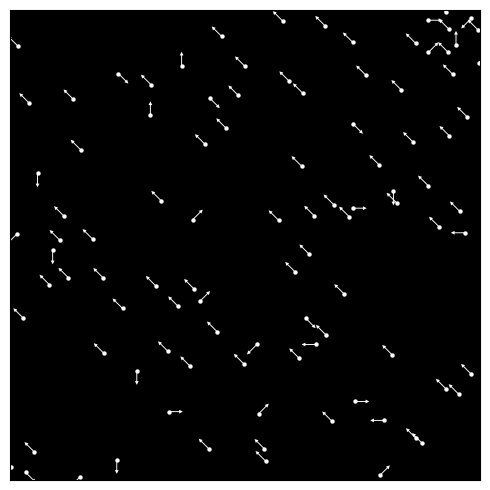

In [11]:
def plot_coherent_dots(
    n_dots=100,
    coherence=0.5,          # c in [0, 1]
    direction_idx=0,        # which of 8 dirs is the coherent one (0..7)
    square_size=1.0,        # coordinates in [0, square_size]
    arrow_len=0.03,
    dot_size=10,
    seed=None,
):
    rng = np.random.default_rng(seed)

    # Random dot positions
    x = rng.uniform(0, square_size, size=n_dots)
    y = rng.uniform(0, square_size, size=n_dots)

    # 8 evenly spaced directions
    angles = np.arange(8) * (2 * np.pi / 8)

    # Choose which dots are coherent
    n_coh = int(round(coherence * n_dots))
    idx = rng.permutation(n_dots)
    coh_idx = idx[:n_coh]
    rand_idx = idx[n_coh:]

    # Assign direction indices
    dir_ids = np.empty(n_dots, dtype=int)
    dir_ids[coh_idx] = direction_idx
    dir_ids[rand_idx] = rng.integers(0, 8, size=rand_idx.size)

    # Convert to arrow vectors
    dx = arrow_len * np.cos(angles[dir_ids])
    dy = arrow_len * np.sin(angles[dir_ids])

    # Plot
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_facecolor("black")
    ax.scatter(x, y, s=dot_size, c="white", linewidths=0)

    ax.quiver(
        x, y, dx, dy,
        angles="xy", scale_units="xy", scale=1,
        color="white",
        width=0.002,
        headwidth=4, headlength=4, headaxislength=4.0
    )

    ax.set_xlim(0, square_size)
    ax.set_ylim(0, square_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    return fig, ax

# example
plot_coherent_dots(n_dots=100, coherence=0.65, direction_idx=3, seed=0)
plt.show()

# Weilbull Fit

In [127]:
resolution = (128, 128)
samples_per_epoch = 2048

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.01, 0.02, 0.035, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3, 0.5, 0.7, 0.9],
    'n_frames': [8, 16, 24, 40, 80],
    'max_speed': [1],
    'n_dots': [100],
}

weibull_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

  0%|          | 0/65 [00:00<?, ?it/s]

100%|██████████| 65/65 [22:37<00:00, 20.88s/it]


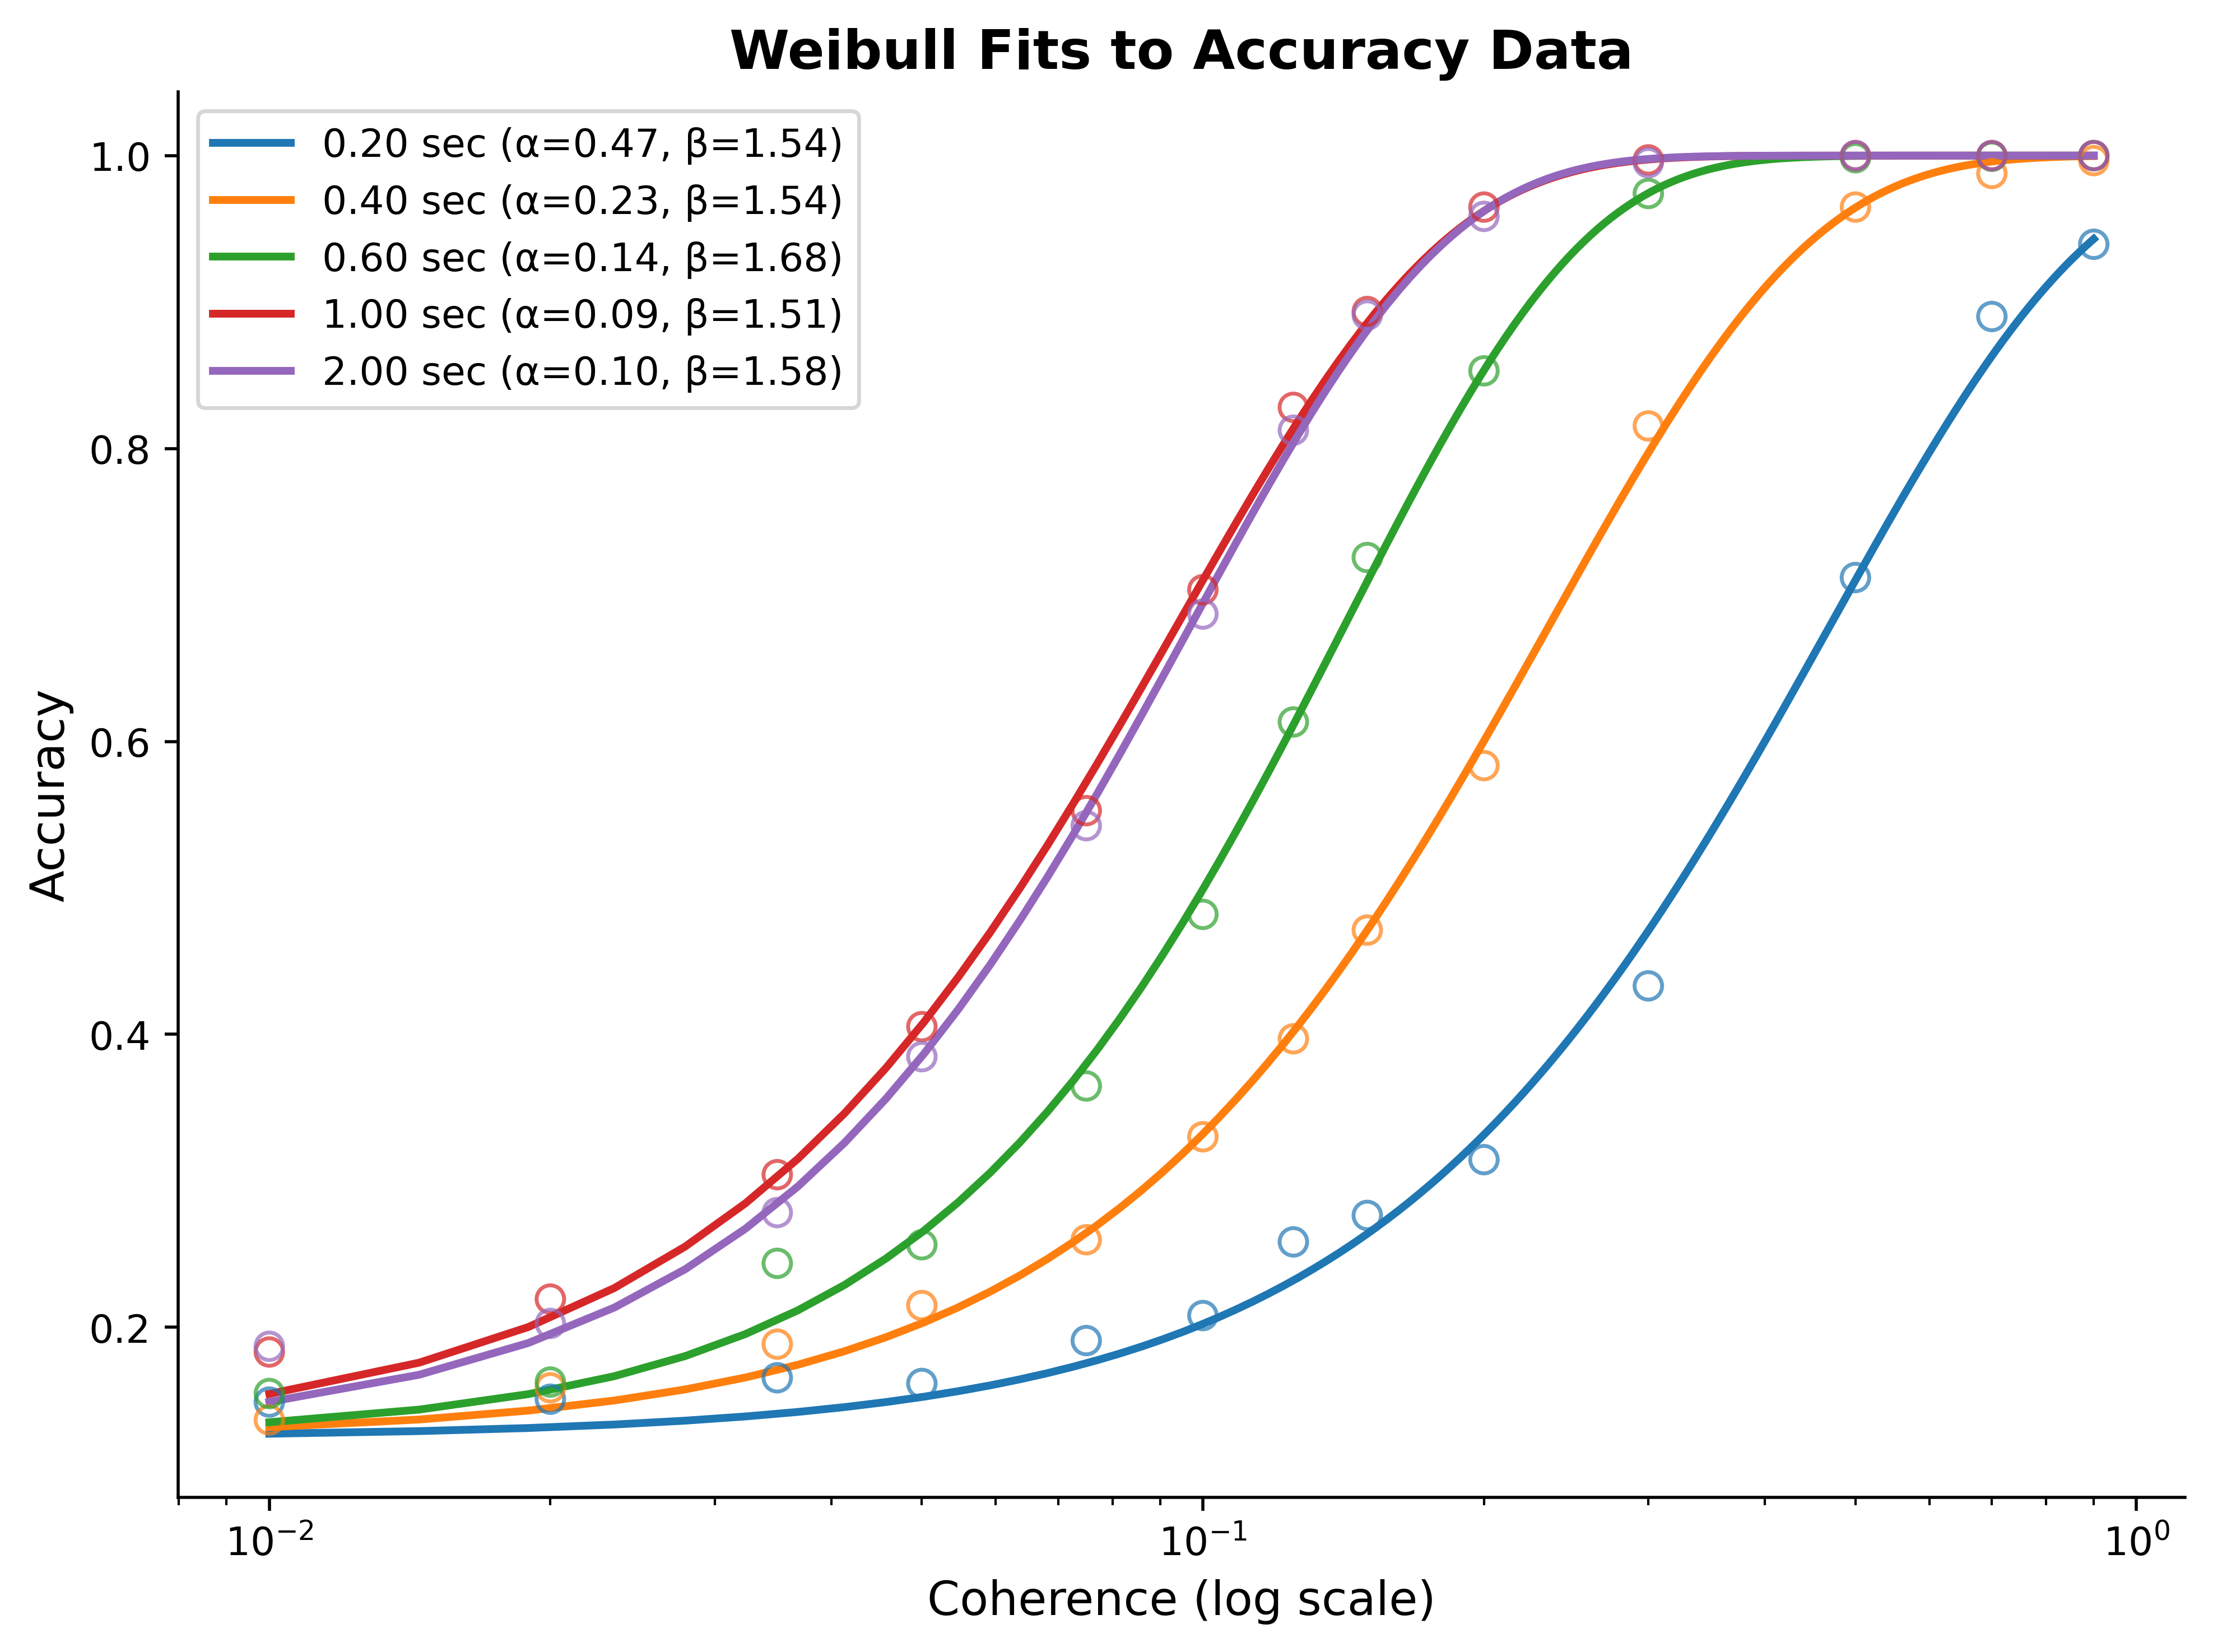

In [128]:
# Use a professional color palette
color_map = plt.get_cmap("tab10")  # or try "Set2", "tab20", "Dark2", etc.

# Example Weibull function
def weibull_func(x, alpha, beta):
    return 1 - (7/8) * np.exp(-((x / alpha) ** beta))

# Given arrays
n_frames_list = param_grid["n_frames"]
coherences = param_grid["coherence"]
n_dots_idx = 0

# 1 frame is 0.025 seconds

timestamps = np.array(param_grid["n_frames"]) * 0.025

fit_params = {}

plt.figure(figsize=(8, 6))
mpl.rcParams.update({'axes.prop_cycle': mpl.cycler(color=[color_map(i) for i in range(len(param_grid["n_frames"]))])})

for n_frames_idx, n_frames in enumerate(n_frames_list):
    accuracies = weibull_accuracies[:, n_frames_idx, 0, n_dots_idx]
    # Fit Weibull curve
    try:
        popt, _ = curve_fit(weibull_func, coherences, accuracies, p0=[0.2, 2.0], bounds=(0, np.inf))
        alpha, beta = popt
    except RuntimeError:
        alpha, beta = np.nan, np.nan
    
    fit_params[n_frames_idx] = (alpha, beta)

    # Plot fitted curve
    x_fit = np.linspace(min(coherences), max(coherences), 200)
    y_fit = weibull_func(x_fit, alpha, beta)

    # Assign color from the palette
    color = color_map(n_frames_idx % color_map.N)

    # Plot fitted curve first (line)
    line, = plt.plot(x_fit, y_fit, "-", label=f"{timestamps[n_frames_idx]:.2f} sec (α={alpha:.2f}, β={beta:.2f})", color=color, linewidth=2)

    # Use the same color for the scatter points, with a professional marker
    plt.scatter(coherences, accuracies, facecolors='none', edgecolors=color, marker='o', s=50, alpha=0.7, zorder=3)

plt.xscale("log")
plt.xlabel("Coherence (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(frameon=True, fontsize=10, loc="best")
plt.title("Weibull Fits to Accuracy Data", fontsize=14, fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "weibull_fits.svg"), format='svg', bbox_inches='tight')
plt.show()

# OOD Inputs

## Low Coherence

In [129]:
resolution = (128, 128)
samples_per_epoch = 2048

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': np.logspace(np.log10(0.005), np.log10(1), 20).tolist(),
    'n_frames': [40],
    'max_speed': [1],
    'n_dots': [100],
    'num_bars': [0],
    'bar_width': [0],
    'dot_shape': ['point'],
    'dot_radius': [1],
    'jitter_speed': [0.0],
    'evidence_pulses': [None],
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)
all_cnn_accuracies = generate_accuracies(cnn_classifier, cnn_cfg, samples_per_epoch, resolution, param_grid)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [06:44<00:00, 20.20s/it]


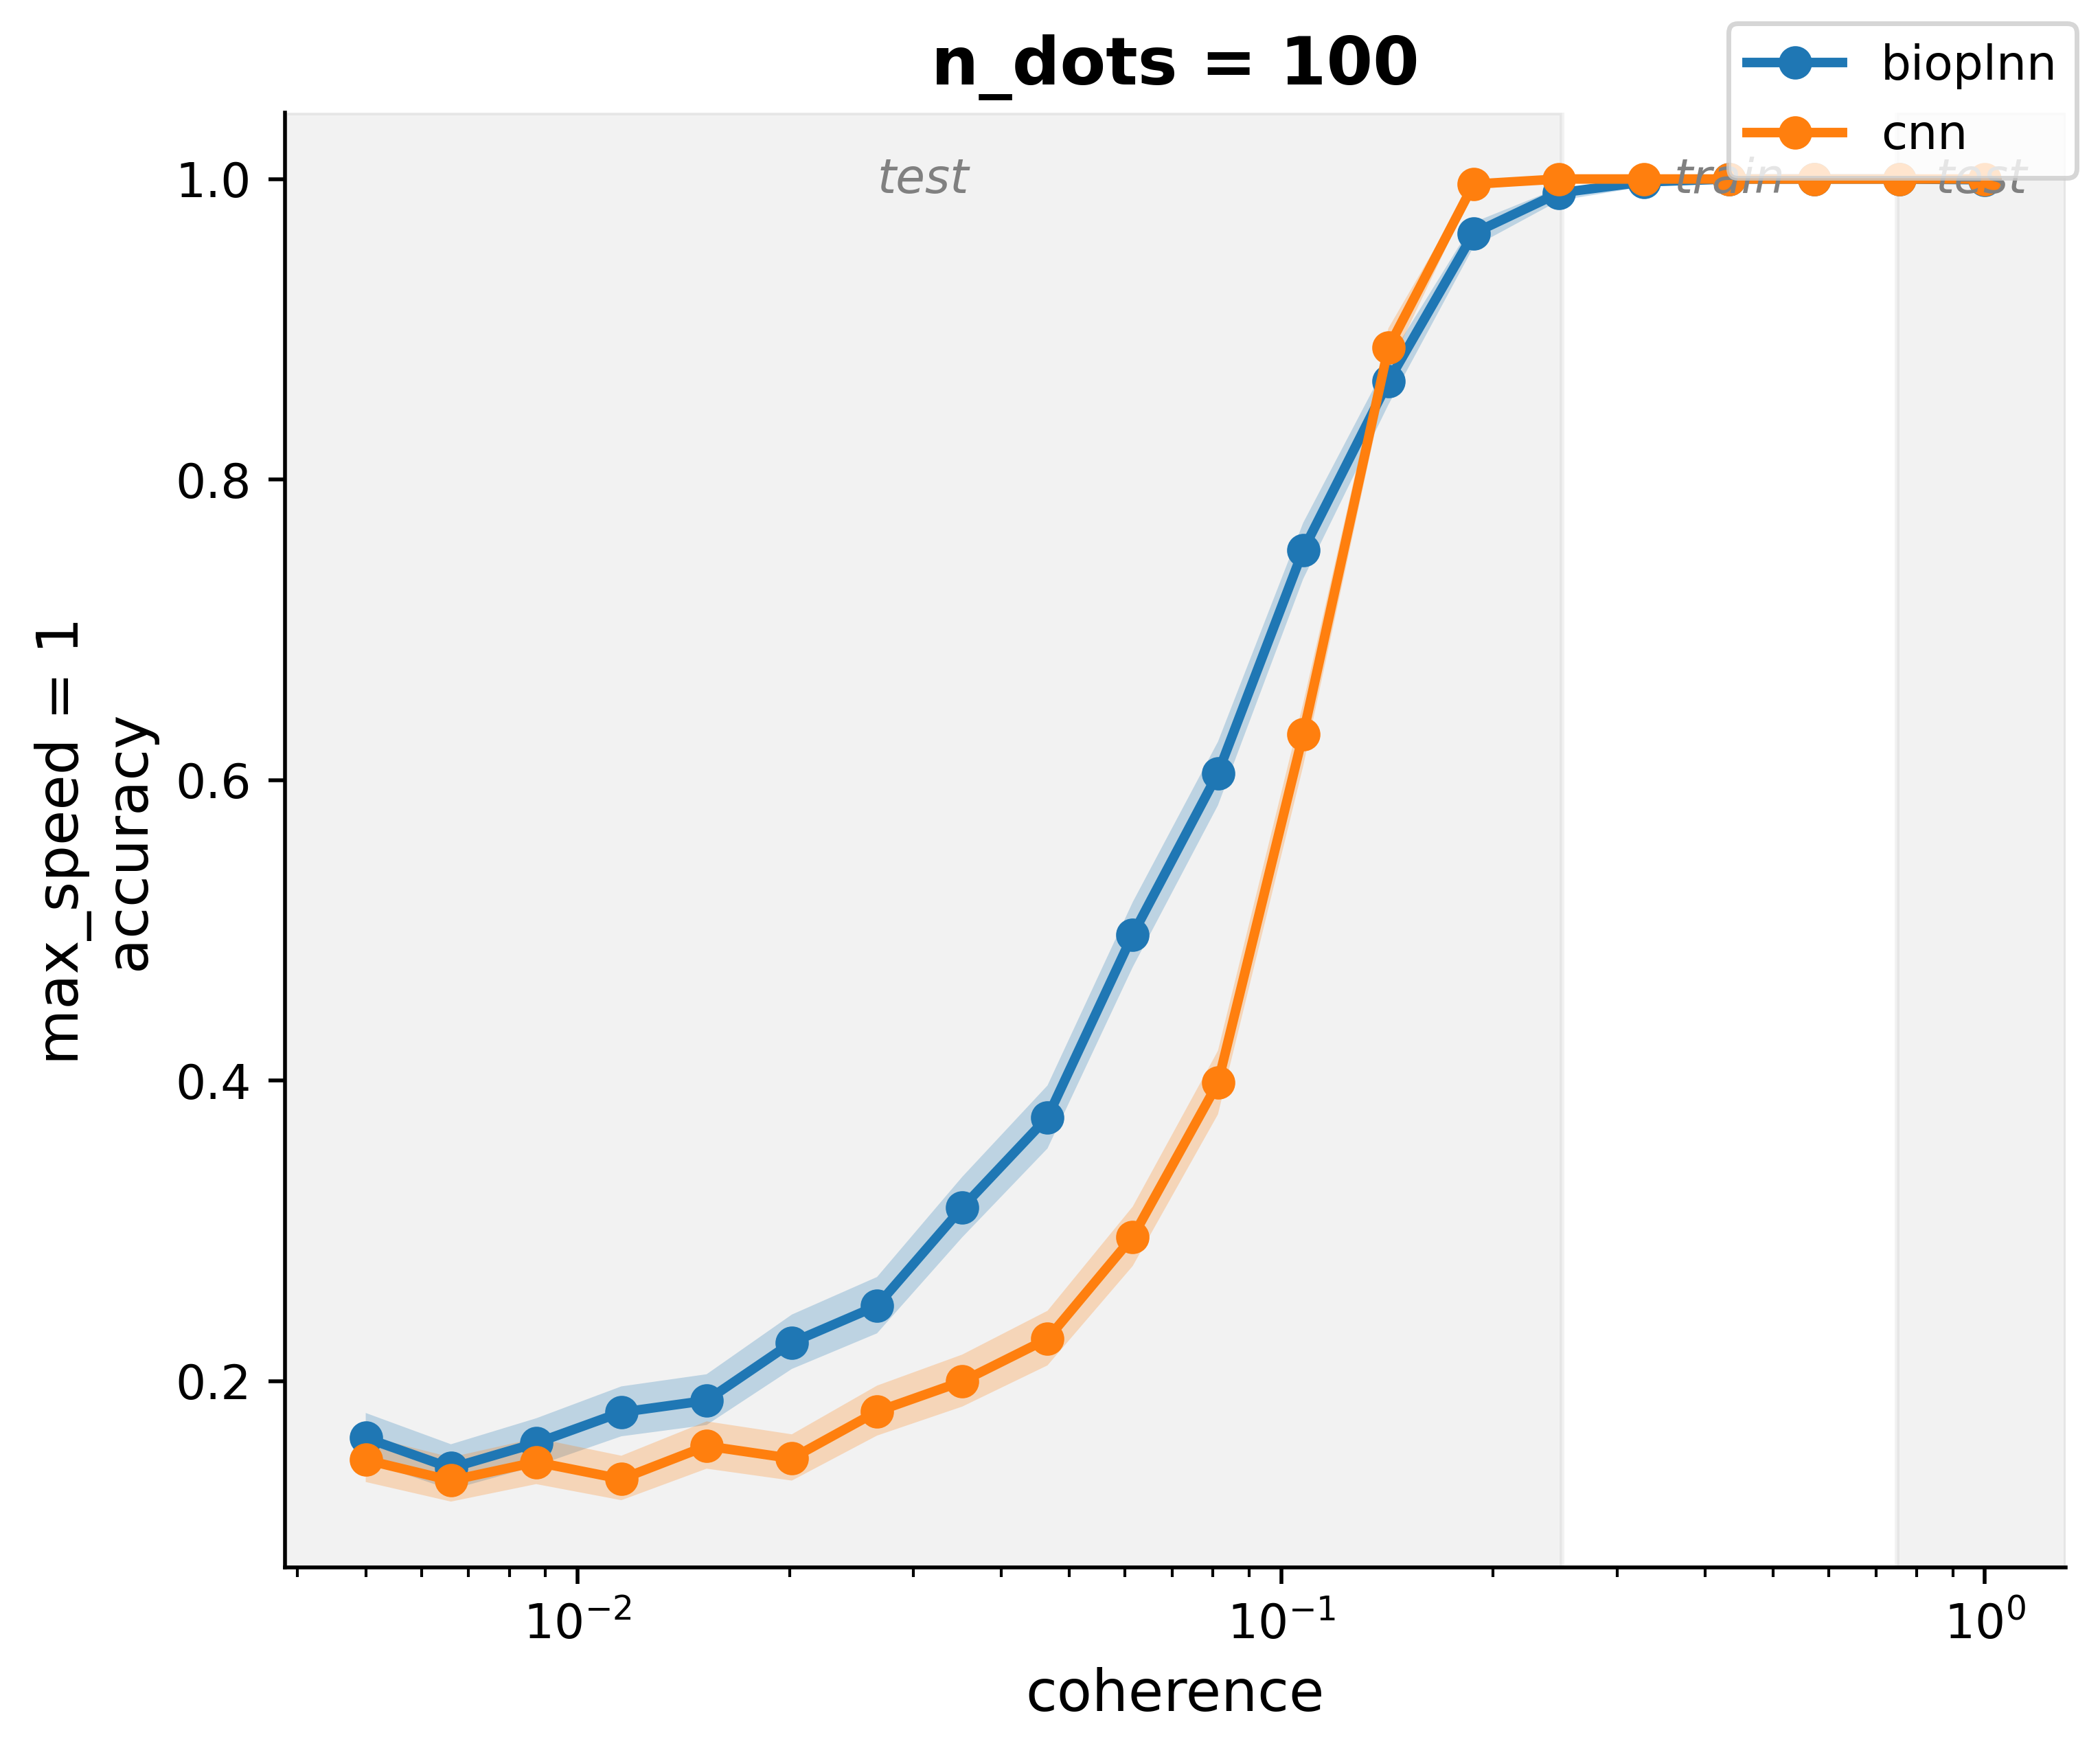

In [130]:
def wilson_ci(p, n, z=1.96):
    """
    p: array of accuracies in [0,1]
    n: number of Bernoulli trials
    Returns: lo, hi arrays
    """
    p = np.asarray(p)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

n_frames_idx = -1
num_trials = samples_per_epoch

coh = np.asarray(param_grid["coherence"])
max_speeds = param_grid["max_speed"]
n_dots_list = param_grid["n_dots"]

fig, axes = plt.subplots(
    len(max_speeds),
    len(n_dots_list),
    figsize=(6 * len(n_dots_list), 5 * len(max_speeds)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for i_speed, speed in enumerate(max_speeds):
    for j_dots, nd in enumerate(n_dots_list):
        ax = axes[i_speed, j_dots]

        bio = all_accuracies[:, n_frames_idx, i_speed, j_dots].squeeze()
        cnn = all_cnn_accuracies[:, n_frames_idx, i_speed, j_dots].squeeze()

        bio_lo, bio_hi = wilson_ci(bio, num_trials)
        cnn_lo, cnn_hi = wilson_ci(cnn, num_trials)

        ax.plot(coh, bio, label="bioplnn", marker="o", linewidth=2)
        ax.plot(coh, cnn, label="cnn", marker="o", linewidth=2)
        ax.fill_between(coh, bio_lo, bio_hi, alpha=0.25)
        ax.fill_between(coh, cnn_lo, cnn_hi, alpha=0.25)

        if i_speed == 0:
            ax.set_title(f"n_dots = {nd}", fontsize=14, fontweight='bold')
        if j_dots == 0:
            ax.set_ylabel(f"max_speed = {speed}\naccuracy", fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=10)

for ax in axes[-1]:
    ax.set_xlabel("coherence", fontsize=12)

for ax in axes.flat:
    ax.set_xscale("log")

# Shade test regions (outside [0.25, 0.75]) and label train/test
train_lo, train_hi = 0.25, 0.75
shade_color = "gray"
shade_alpha = 0.10

# Force layout so axes limits are finalised on the log scale
fig.canvas.draw()

for idx, ax in enumerate(axes.flat):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    has_left  = xlim[0] < train_lo
    has_train = xlim[0] < train_hi and xlim[1] > train_lo
    has_right = xlim[1] > train_hi

    # Left test region
    if has_left:
        ax.axvspan(xlim[0], min(train_lo, xlim[1]),
                   color=shade_color, alpha=shade_alpha, zorder=0)
    # Right test region
    if has_right:
        ax.axvspan(max(train_hi, xlim[0]), xlim[1],
                   color=shade_color, alpha=shade_alpha, zorder=0)

    # --- text labels (first row only) via axes-fraction coordinates ---
    if idx < len(n_dots_list):
        from matplotlib.transforms import blended_transform_factory
        # x in axes-fraction, y in axes-fraction
        trans = ax.transAxes

        # Compute axes-fraction positions of boundaries
        # On a log axis the mapping is: frac = (log(x) - log(xlo)) / (log(xhi) - log(xlo))
        log_lo, log_hi = np.log10(xlim[0]), np.log10(xlim[1])
        log_span = log_hi - log_lo

        def data_to_frac(v):
            return (np.log10(v) - log_lo) / log_span

        frac_train_lo = np.clip(data_to_frac(train_lo), 0, 1)
        frac_train_hi = np.clip(data_to_frac(train_hi), 0, 1)

        y_frac = 0.97  # near the top

        # "test" in left shaded region
        if has_left:
            cx = frac_train_lo / 2
            ax.text(cx, y_frac, "test", ha="center", va="top",
                    fontsize=10, fontstyle="italic", color="gray",
                    transform=trans)

        # "train" in unshaded region
        if has_train:
            cx = (frac_train_lo + frac_train_hi) / 2
            ax.text(cx, y_frac, "train", ha="center", va="top",
                    fontsize=10, fontstyle="italic", color="gray",
                    transform=trans)

        # "test" in right shaded region
        if has_right:
            cx = (frac_train_hi + 1) / 2
            ax.text(cx, y_frac, "test", ha="center", va="top",
                    fontsize=10, fontstyle="italic", color="gray",
                    transform=trans)

    # Restore limits so shading doesn't expand the view
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.savefig(os.path.join(save_dir, "ood_inputs.svg"), format='svg', bbox_inches='tight')

plt.show()

## Irregular Shapes, Movements, and Occlusion

In [134]:
resolution = (128, 128)
samples_per_epoch = 512

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5],
    'n_frames': [40],
    'max_speed': [1],
    'n_dots': [100],
    'num_bars': [4, 8, 12],
    'bar_width': [4, 8],
    'dot_shape': ['point'],
    'dot_radius': [3],
    'jitter_speed': [0.0],
    'evidence_pulses': [None],
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)
all_cnn_accuracies = generate_accuracies(cnn_classifier, cnn_cfg, samples_per_epoch, resolution, param_grid)

100%|██████████| 42/42 [05:11<00:00,  7.42s/it]


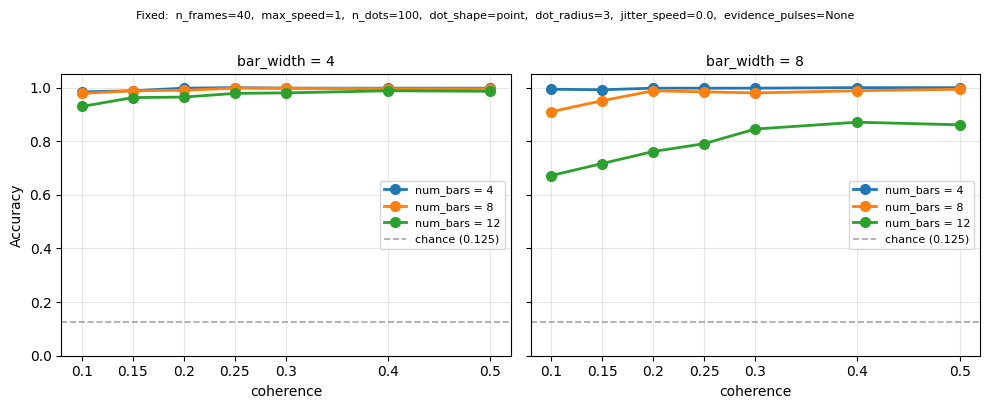

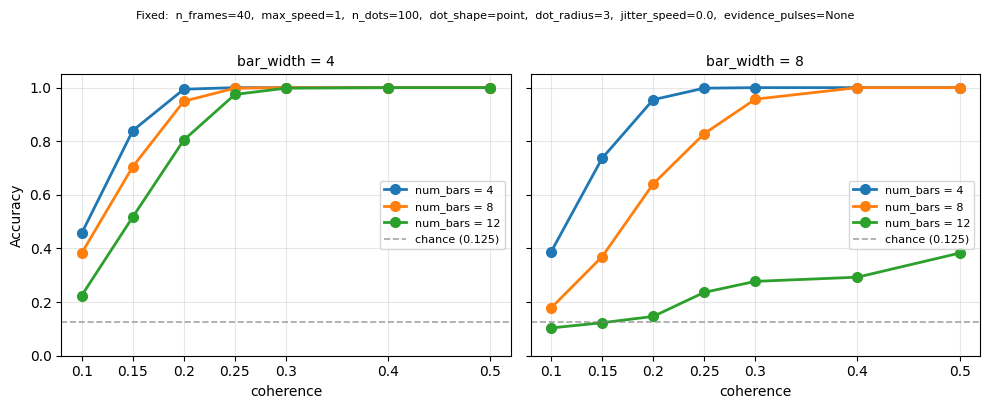

In [135]:
n_classes = cfg["model_config"].get("num_classes", 8)
plot_accuracies(all_accuracies, param_grid, chance_level=1/n_classes)
plot_accuracies(all_cnn_accuracies, param_grid, chance_level=1/n_classes)

# Evidence Pulse Timing

Sweep a brief evidence pulse across the sequence and measure how pulse timing affects the model's final decision. Two pulse types are tested at each start frame:

- **Positive** `(direction=+1)`: coherence is temporarily doubled — extra signal
- **Negative** `(direction=-1)`: the coherent direction is reversed — misleading signal

The two-panel figure shows raw accuracy and the accuracy delta relative to a no-pulse baseline. Horizontal error bars span the full pulse window `[start_t, start_t + duration]`.


In [131]:
n_frames      = 40
pulse_duration = 4
pulse_start_offset = 2
pulse_starts   = list(range(0, n_frames, pulse_start_offset))

# Build the evidence_pulses sweep:
#   index 0          → no pulse (baseline)
#   indices 1..N     → positive pulse starting at each frame in pulse_starts
#   indices N+1..2N  → negative pulse starting at each frame in pulse_starts
pulse_options = (
    [None]
    + [[(t, pulse_duration, +1)] for t in pulse_starts]
    + [[(t, pulse_duration, -1)] for t in pulse_starts]
)

param_grid_pulse = {
    'coherence':       [0.25],
    'n_frames':        [n_frames],
    'max_speed':       [1],
    'n_dots':          [100],
    'num_bars':        [0],
    'bar_width':       [0],
    'dot_shape':       ['point'],
    'dot_radius':      [1],
    'jitter_speed':    [0.0],
    'evidence_pulses': pulse_options,
}

accs_pulse = generate_accuracies(classifier, cfg, 1024, resolution, param_grid_pulse)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [08:35<00:00, 12.57s/it]


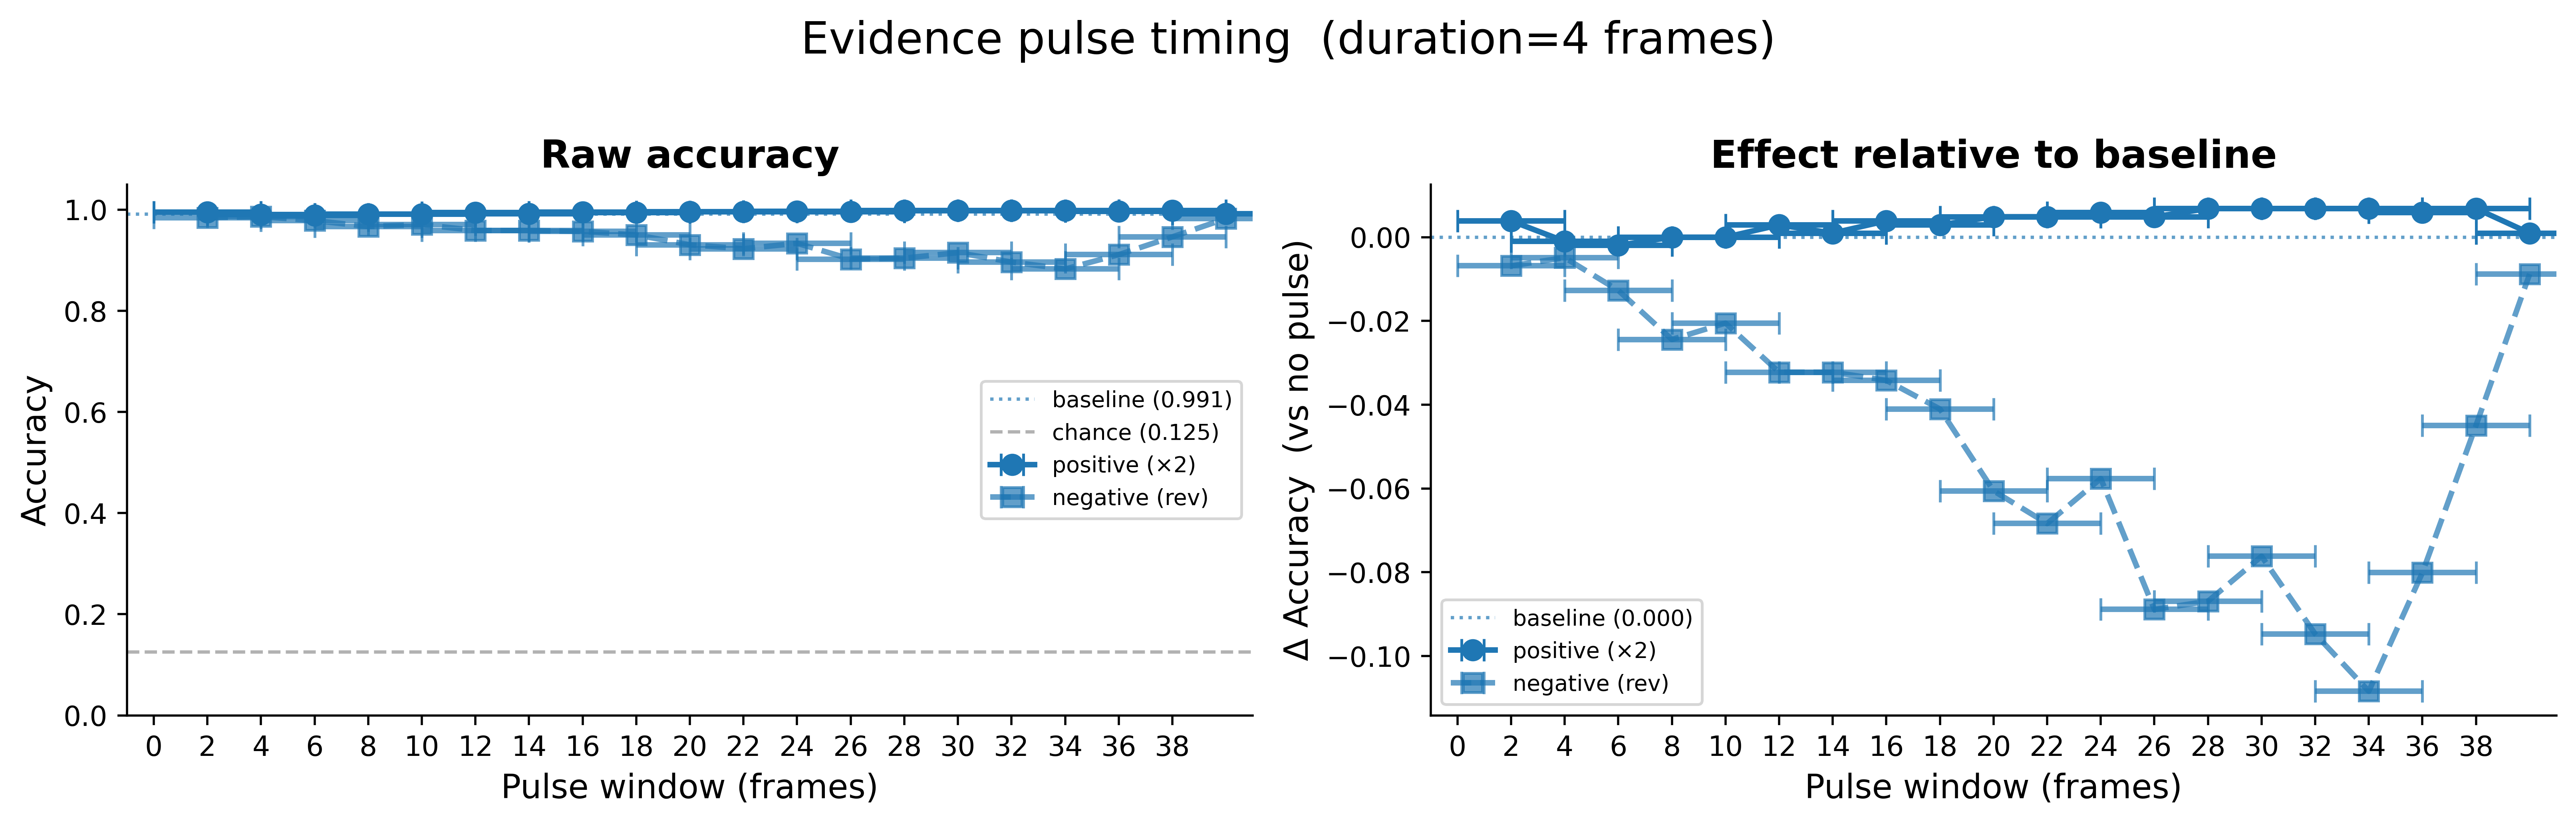

In [132]:
def plot_pulse_timing(accs, param_grid, pulse_starts, pulse_duration,
                      chance_level=None, title=None):
    """
    Two-panel figure: raw accuracy (left) and delta vs. baseline (right).

    Expects param_grid['evidence_pulses'] to be structured as:
        [None, pos_pulse_t0, ..., neg_pulse_t0, ...]
    where None = no-pulse baseline, direction +1 = positive, direction -1 = negative.

    Any other parameters with multiple values in param_grid become separate
    colored curves. Within each color, solid circles = positive pulse,
    dashed squares = negative pulse, dotted line = baseline.
    """
    param_names      = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]
    ev_list          = param_grid['evidence_pulses']
    pulse_dim        = param_names.index('evidence_pulses')
    n_frames         = param_grid['n_frames'][0]

    # Other dimensions that have more than one value (e.g. coherence)
    other_varying = [
        (name, vals, dim)
        for dim, (name, vals) in enumerate(zip(param_names, param_value_lists))
        if name != 'evidence_pulses' and len(vals) > 1
    ]
    other_names = [n for n, v, d in other_varying]
    other_vals  = [v for n, v, d in other_varying]
    other_dims  = [d for n, v, d in other_varying]
    combos = list(itertools.product(*other_vals)) if other_varying else [()]

    def extract_pulse_slice(combo):
        """Return 1-D array of length len(ev_list) for this combo of other params."""
        idx = [0] * accs.ndim
        for (name, vals, dim), val in zip(other_varying, combo):
            idx[dim] = vals.index(val)
        idx[pulse_dim] = slice(None)
        return accs[tuple(idx)]   # shape (len(ev_list),)

    def parse_slice(arr1d):
        baseline, pos, neg = None, {}, {}
        for i, ep in enumerate(ev_list):
            a = float(arr1d[i])
            if ep is None:
                baseline = a
            else:
                start_t, _, direction = ep[0]
                (pos if direction > 0 else neg)[start_t] = a
        return baseline, pos, neg

    centers = [t + pulse_duration / 2 for t in pulse_starts]
    xerr    = pulse_duration / 2
    colors  = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ci, combo in enumerate(combos):
        color     = colors[ci % len(colors)]
        arr       = extract_pulse_slice(combo)
        base, pos_accs, neg_accs = parse_slice(arr)

        combo_label = ", ".join(f"{n}={v}" for n, v in zip(other_names, combo))
        suffix      = f"  [{combo_label}]" if combo_label else ""

        pos_raw   = [pos_accs.get(t, np.nan) for t in pulse_starts]
        neg_raw   = [neg_accs.get(t, np.nan) for t in pulse_starts]
        pos_delta = [v - base for v in pos_raw]
        neg_delta = [v - base for v in neg_raw]

        for ax, ypos, yneg, ybase in [
            (axes[0], pos_raw,   neg_raw,   base),
            (axes[1], pos_delta, neg_delta, 0.0),
        ]:
            ax.axhline(ybase, color=color, linestyle=':', linewidth=1.2,
                       label=f'baseline ({ybase:.3f}){suffix}', zorder=1, alpha=0.7)
            ax.errorbar(centers, ypos, xerr=xerr, color=color,
                        fmt='o-', capsize=4, linewidth=2, markersize=7, zorder=3,
                        label=f'positive (×2){suffix}')
            ax.errorbar(centers, yneg, xerr=xerr, color=color,
                        fmt='s--', capsize=4, linewidth=2, markersize=7, zorder=3,
                        label=f'negative (rev){suffix}', alpha=0.7)

    # Shared decoration
    for ax in axes:
        ax.set_xlabel('Pulse window (frames)', fontsize=12)
        ax.set_xlim(-1, n_frames + 1)
        ax.set_xticks(pulse_starts)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=10)
        ax.legend(fontsize=8)

    if chance_level is not None:
        axes[0].axhline(chance_level, color='gray', linestyle='--', linewidth=1.2,
                        alpha=0.6, label=f'chance ({chance_level:.3g})', zorder=0)
        axes[0].legend(fontsize=8)

    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title('Raw accuracy', fontsize=14, fontweight='bold')

    axes[1].set_ylabel('Δ Accuracy  (vs no pulse)', fontsize=12)
    axes[1].set_title('Effect relative to baseline', fontsize=14, fontweight='bold')

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "evidence_pulse_timing.svg"), format='svg', bbox_inches='tight')
    plt.show()


n_classes = cfg["model_config"].get("num_classes", 8)
plot_pulse_timing(
    accs_pulse, param_grid_pulse, pulse_starts, pulse_duration,
    chance_level=1 / n_classes,
    title=f"Evidence pulse timing  (duration={pulse_duration} frames)",
)


# Saddle Point Check with Ambiguous Input

In [81]:
def get_decision_points(classifier, data_loader, device):
    num_timestamps = 40
    timestamp_idxs = np.arange(1, num_timestamps + 1)

    all_predictions = []
    classifier.eval()
    with torch.no_grad():
        for batch_inputs, batch_labels in tqdm(data_loader):
            bsz = batch_inputs.shape[0]
            batch_preds = np.zeros((bsz, num_timestamps))
            for timestamp_idx in timestamp_idxs:
                inputs_at_timestamp = batch_inputs[:, :timestamp_idx, :, :, :].to(device)
                logits = classifier(inputs_at_timestamp, num_steps=timestamp_idx).detach().cpu()
                _, predicted = torch.max(logits, 1)
                batch_preds[:, timestamp_idx - 1] = predicted.numpy()
            all_predictions.append(batch_preds)

    predictions = np.concatenate(all_predictions, axis=0)
    num_samples = predictions.shape[0]

    decision_points = np.zeros(num_samples)
    for sample_idx in range(num_samples):
        for i in range(num_timestamps - 1, 0, -1):
            if predictions[sample_idx, i] != predictions[sample_idx, -1]:
                decision_points[sample_idx] = i + 1
                break

    return decision_points

In [133]:
def get_decision_points(classifier, data_loader, device, num_steps=40, bound=1.5):                                                                                                                                                       
    """                                                                                                                                                                                                                                  
    Decision point via log-odds threshold (SPRT-like bound).                                                                                                                                                                             
                
    bound: log-odds threshold. bound=3.0 corresponds to ~95% confidence
            (since softmax p = sigmoid(log_odds) for 2-class case).
    """
    all_decision_points = []
    classifier.eval()
    with torch.no_grad():
        for batch_inputs, batch_labels in tqdm(data_loader):
            logits = classifier(
                batch_inputs.to(device),
                num_steps=num_steps,
                loss_all_timesteps=True,
            ).detach().cpu()  # (batch, num_steps, num_classes)

            # Log-odds between top two classes at each timestep
            top2 = logits.topk(2, dim=-1).values  # (batch, num_steps, 2)
            log_odds = top2[:, :, 0] - top2[:, :, 1]  # (batch, num_steps)

            # Decision point = first timestep where log-odds exceeds bound
            crossed = log_odds >= bound  # (batch, num_steps)
            # argmax on a bool tensor returns first True; returns 0 if none True
            first_cross = crossed.float().argmax(dim=1).numpy()
            ever_crossed = crossed.any(dim=1).numpy()
            decision_points = np.where(ever_crossed, first_cross, num_steps)

            all_decision_points.append(decision_points)

    return np.concatenate(all_decision_points)

In [67]:
def find_optimal_bound(
      classifier, device, num_steps=40,
      coherences=np.logspace(np.log10(0.01), np.log10(0.15), 5),
      bounds=np.linspace(0.5, 6.0, 50),
      loader_kwargs=None,
  ):
      """
      Find the bound that maximizes |correlation| between coherence and
      mean decision time. Higher coherence should → faster decisions.
   
      loader_kwargs: dict of shared kwargs for initialize_dataloader
                     (everything except 'correlation').
      """
      if loader_kwargs is None:
          loader_kwargs = dict(
              seed=10, dataset="correlated_dots", n_dots=100,
              resolution=(128, 128), n_frames=40, max_speed=1,
              samples_per_epoch=512, batch_size=32,
          )

      # Collect log-odds traces per coherence level
      all_log_odds = {}  # coherence -> (N, num_steps)
      classifier.eval()
      with torch.no_grad():
          for coh in tqdm(coherences, desc="Coherences"):
              kw = {**loader_kwargs, "correlation": coh}
              data_loader, _ = initialize_dataloader(**kw)
              batch_lo = []
              for batch_inputs, _ in data_loader:
                  logits = classifier(
                      batch_inputs.to(device),
                      num_steps=num_steps,
                      loss_all_timesteps=True,
                  ).detach().cpu()
                  top2 = logits.topk(2, dim=-1).values
                  batch_lo.append(top2[:, :, 0] - top2[:, :, 1])
              all_log_odds[coh] = torch.cat(batch_lo).numpy()

      # Sweep bounds
      results = []
      for bound in bounds:
          mean_dts = []
          for coh in coherences:
              lo = all_log_odds[coh]
              crossed = lo >= bound
              first_cross = crossed.argmax(axis=1)
              ever_crossed = crossed.any(axis=1)
              dt = np.where(ever_crossed, first_cross, num_steps)
              mean_dts.append(dt.mean())

          r = np.corrcoef(np.log(coherences), mean_dts)[0, 1]
          results.append((bound, r))

      # Strongest negative correlation
      best_bound = min(results, key=lambda x: x[1])[0]
      return best_bound, results

In [68]:
best_bound, results = find_optimal_bound(classifier, device)

Coherences: 100%|██████████| 5/5 [00:33<00:00,  6.65s/it]


In [134]:
coherence = 0.15
samples_per_epoch = 2048
regular_decision_points = []
ambiguous_decision_points = []
n_dots_values = [15, 100, 500, 1000]

for n_dots in n_dots_values:
        loader_kwargs = {
                'seed': 10,
                'dataset': "correlated_dots",
                'n_dots': n_dots,
                'resolution': (128, 128),
                'n_frames': 40,
                'correlation': coherence,
                'max_speed': 1,
                'samples_per_epoch': samples_per_epoch,
                'batch_size': 128,
        }

        data_loader, test_loader = initialize_dataloader(**loader_kwargs)
        regular_decision_points.append(get_decision_points(classifier, data_loader, device))

        directions = [8, 9, 10, 11]

        loader_kwargs = {
                'seed': 10,
                'dataset': "correlated_dots",
                'n_dots': n_dots,
                'resolution': (128, 128),
                'n_frames': 40,
                'correlation': coherence,
                'max_speed': 1,
                'samples_per_epoch': samples_per_epoch,
                'batch_size': 128,
                'directions': directions,
        }

        data_loader, test_loader = initialize_dataloader(**loader_kwargs)
        ambiguous_decision_points.append(get_decision_points(classifier, data_loader, device))

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:31<00:00,  1.95s/it]


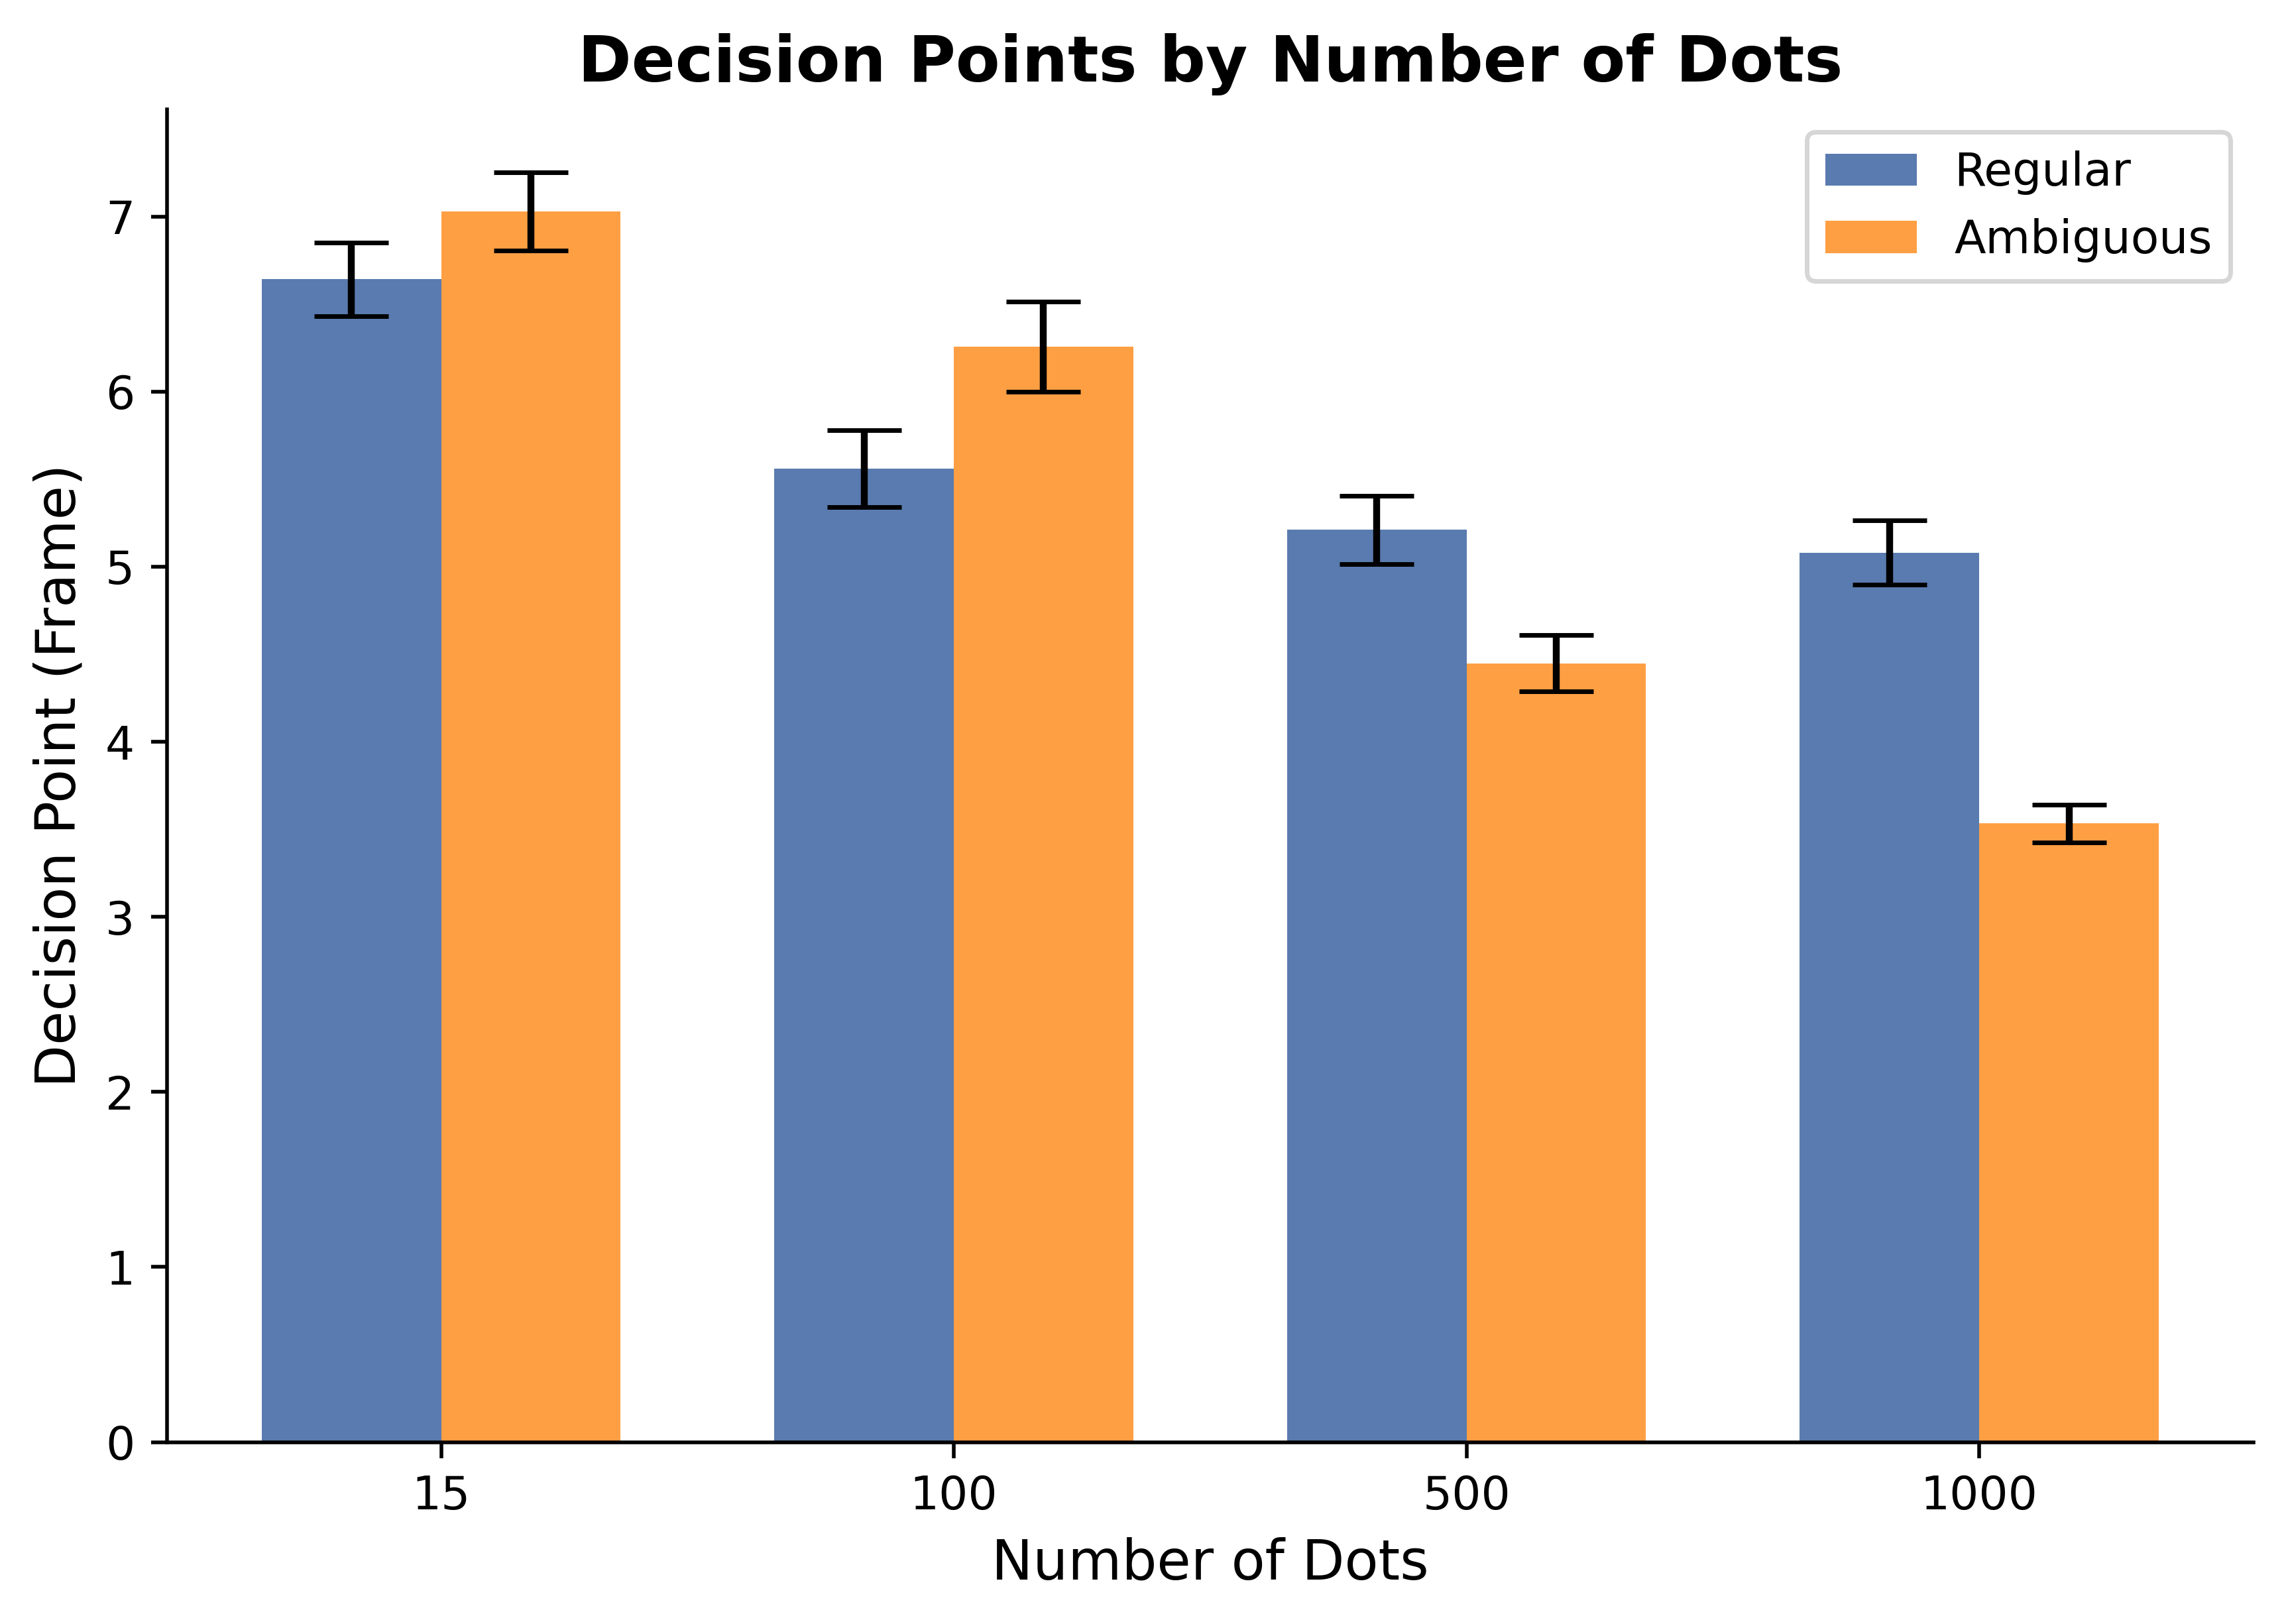

In [135]:
regular_means = [np.mean(dp) for dp in regular_decision_points]                                                                                                                                                                          
regular_cis = [1.96 * np.std(dp) / np.sqrt(len(dp)) for dp in regular_decision_points]                                                                                                                                                   
ambiguous_means = [np.mean(dp) for dp in ambiguous_decision_points]
ambiguous_cis = [1.96 * np.std(dp) / np.sqrt(len(dp)) for dp in ambiguous_decision_points]

x = np.arange(len(n_dots_values))
bar_width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - bar_width/2, regular_means, yerr=regular_cis, width=bar_width, capsize=8, label="Regular", color='#5A7BAF')
plt.bar(x + bar_width/2, ambiguous_means, yerr=ambiguous_cis, width=bar_width, capsize=8, label="Ambiguous", color='#FF9F43')

plt.xticks(x, [f"{n}" for n in n_dots_values])
plt.xlabel("Number of Dots", fontsize=12)
plt.ylabel("Decision Point (Frame)", fontsize=12)
plt.title("Decision Points by Number of Dots", fontsize=14, fontweight='bold')
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)
plt.savefig(os.path.join(save_dir, "decision_points_by_n_dots.svg"), format='svg', bbox_inches='tight')
plt.tight_layout()

# Dynamical Analysis Code

In [103]:
def keep_only_label_from_loader(loader, target_labels, batch_size=None, shuffle=False):
    xs, ys = [], []
    for x, y in loader:
        # make labels 1-D over batch
        if y.ndim > 1:
            # if one-hot/probabilities, reduce to class id
            if y.size(-1) > 1:
                y_flat = y.argmax(dim=-1)
            else:
                y_flat = y.squeeze(-1)
        else:
            y_flat = y

        mask = False
        for label in target_labels:
            mask = mask | (y_flat == label)
        if mask.any():
            xs.append(x[mask, ...])                # index batch dim only
            ys.append(y_flat[mask])

    X = torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)
    ds = TensorDataset(X, Y)
    return DataLoader(
        ds,
        batch_size or loader.batch_size,
        shuffle=shuffle,
        num_workers=loader.num_workers,
        pin_memory=loader.pin_memory,
        drop_last=loader.drop_last,
    )

# ----- MEM UTILS -----
def _bytes(n):
    for unit in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

def _cpu_rss_bytes():
    try:
        import psutil
        return psutil.Process(os.getpid()).memory_info().rss
    except Exception:
        # Fallback: resource gets maxrss; not perfect, but better than nothing
        try:
            import resource
            r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            # macOS reports bytes, Linux reports KB
            return r if r > 10**9 else r * 1024
        except Exception:
            return 0

def _cuda_bytes():
    if torch.cuda.is_available():
        dev = torch.cuda.current_device()
        alloc = torch.cuda.memory_allocated(dev)
        reserv = torch.cuda.memory_reserved(dev)
        max_alloc = torch.cuda.max_memory_allocated(dev)
        return alloc, reserv, max_alloc
    return 0, 0, 0

def log_mem(tag):
    rss = _cpu_rss_bytes()
    alloc, reserv, max_alloc = _cuda_bytes()
    msg = (
        f"[{time.strftime('%H:%M:%S')}] {tag} | "
        f"CPU RSS: {_bytes(rss)} "
        f"| CUDA alloc: {_bytes(alloc)} "
        f"reserved: {_bytes(reserv)} "
        f"peak: {_bytes(max_alloc)}"
    )
    print(msg, flush=True)

def estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4):
    """
    Rough lower bound of arrays you preallocate (not counting transient copies).
    e_a: (N, T, 8, dim, dim) float32
    final_inputs: (N, T, 1, 128, 128) float32 if store_inputs
    """
    e_bytes = num_samples * num_steps * 8 * dim * dim * dtype_bytes
    fi_bytes = num_samples * num_steps * 1 * 128 * 128 * dtype_bytes if store_inputs else 0
    return e_bytes + fi_bytes

def get_activations(model, classifier, cfg, num_samples, loader, decision_step, num_steps=20, dim=48, neuron_type="excitatory", device=None, memory_monitor=False, precision="float32"):
    if device is None:
        device = next(model.parameters()).device

    # quick estimate up-front
    approx = estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4)
    print(f"[estimate] Lower-bound host memory footprint (preallocs only): {_bytes(approx)}", flush=True)

    if memory_monitor:
        log_mem("start")

    # choose a sorted subset of indices
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)
    subset_indices = np.sort(subset_indices)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # mirror original loader settings where possible
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,  # keep consistent ordering for preallocation fill
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False
    )

    # preallocate
    if precision == "float16":
        dtype = np.float16
    elif precision == "float32":    
        dtype = np.float32
    else:
        raise ValueError(f"Unknown precision: {precision}")
    
    if neuron_type == "excitatory":
        num_channels = cfg["model_config"]["rnn_kwargs"]["area_kwargs"][0]["num_neuron_subtypes"][0]
        a = np.zeros((num_samples, num_steps, num_channels, dim, dim), dtype=dtype)
    elif neuron_type == "inhibitory":
        num_channels = cfg["model_config"]["rnn_kwargs"]["area_kwargs"][0]["num_neuron_subtypes"][1]
        a = np.zeros((num_samples, num_steps, num_channels, dim, dim), dtype=np.float32)
    elif neuron_type == "output":
        num_channels = cfg["model_config"]["rnn_kwargs"]["area_kwargs"][0]["out_channels"]
        a = np.zeros((num_samples, num_steps, num_channels, dim, dim), dtype=np.float32)

    decisions = np.zeros((num_samples,), dtype=np.int64)

    if memory_monitor:
        log_mem("after preallocs")

    model.eval()
    classifier.eval()
    classifier.to(device)

    final_labels = []

    # CUDA peak stats baseline
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    sample_idx = 0
    with torch.no_grad():
        for batch_idx, (batch_inputs, labels) in enumerate(tqdm(dataloader)):
            if memory_monitor:
                log_mem(f"batch {batch_idx} - fetched from loader")

            bsz = batch_inputs.shape[0]

            # move to device
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after to(device)")

            # forward core model
            batch_output_states, batch_neuron_states, batch_feedback_states = model(
                batch_inputs, num_steps=num_steps
            )
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after model()")

            # collect outputs on CPU
            # NOTE: .cpu().numpy() creates a *new* CPU array (extra RAM). Track this explicitly.
            o = batch_output_states[0].detach().cpu()  # (B, T, 8, dim, dim)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.cpu() (before numpy)")

            # if you don't need numpy immediately, stay in torch and convert when writing:
            o_np = o.numpy()  # temp CPU copy
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.numpy()")

            e_t = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.cpu() (before numpy)")
            e = e_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.numpy()")

            i_t = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.cpu() (before numpy)")
            i = i_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.numpy()")

            # decisions (GPU -> small CPU copy)
            pred = classifier(batch_inputs, num_steps=decision_step)
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after classifier + argmax")

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            if neuron_type == "excitatory":
                a[sl, :, :, :, :] = e
            elif neuron_type == "inhibitory":
                a[sl, :, :, :, :] = i
            elif neuron_type == "output":
                a[sl, :, :, :, :] = o_np
            decisions[sl] = dec
            final_labels.extend(labels.flatten().tolist())
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after writes to preallocs")

            # ---- CLEAN UP TRANSIENTS to release host RAM ----
            del o, o_np, e_t, e, i_t, i, pred, dec
            del batch_output_states, batch_neuron_states, batch_feedback_states
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after gc/empty_cache")

            sample_idx += bsz

    if memory_monitor:
        log_mem("end")
    return {
        "activations": a,
        "decisions": decisions,
        "labels": np.array(final_labels, dtype=np.int64),
    }

def get_decisions(classifier, dataloader, decision_step, device=None):
    if device is None:
        device = next(classifier.parameters()).device

    num_samples = len(dataloader.dataset)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            # --- decisions in the same pass ---
            # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
            pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            decisions[sl] = dec
            sample_idx += bsz

    return decisions

class PCTrajectoryPlotter:
    """
    Fit PCA on (N, T, D) activations and plot trajectories using the fitted PCA.

    Usage:
        p = PCTrajectoryPlotter(max_components=10, random_state=0)
        p.fit(activations_train, decisions_train, balance_for_fit=False)
        p.plot(activations_val, decisions_val, n_components=2, ...)
        p.plot(activations_val, decisions_val, n_components=3, ...)
        p.plot(activations_val, decisions_val, n_components=5, ...)
    Key behaviors:
      - PCA is fit ONCE via `.fit(...)` with max_components. Later `.plot(...)` calls reuse it and can select n_components <= max_components.
      - You can pass different activations/decisions to `.plot(...)`.
      - Class color mapping is fixed based on classes seen at fit-time.
      - Overlay exemplars can be restricted to a subset of classes via `overlay_classes`.
      - plot_all_endpoints scatters the ENDPOINT of *all* trials, regardless of other settings.
    """

    def __init__(self, max_components=None, n_components=None, random_state=0):
        # Backward compatibility: n_components is an alias for max_components if max_components is not given
        if max_components is None and n_components is not None:
            max_components = n_components
        self.max_components = max_components
        self.random_state = random_state

        # For backward compatibility, keep n_components as a property
        self.n_components = max_components

        # PCA will be fit with max_components (or all if None)
        self.pca = None
        self.fitted_ = False

        # Fitted metadata
        self.classes_ = None            # sorted unique class values (as seen in decisions at fit time)
        self.class_to_index_ = None     # mapping from class value -> integer index
        self.color_map_ = None          # mapping from class index -> rgba
        self.cmap_name = 'viridis'
        self.fit_collapsed_ = False
        self._fit_D = None              # Number of features at fit time

    # ----------------------- Core utilities -----------------------

    @staticmethod
    def _check_inputs(A, y):
        A = np.asarray(A)
        y = np.asarray(y)
        assert A.ndim == 3, f"activations must be (N,T,D); got {A.shape}"
        N, T, D = A.shape
        assert y.shape[0] == N, f"decisions length {y.shape[0]} must match N {N}"
        return A, y, N, T, D

    @staticmethod
    def _balance_indices(y_num, rng):
        counts = np.bincount(y_num)
        k_bal = counts[counts > 0].min()
        uniq = np.unique(y_num)
        keep = np.concatenate([
            rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in uniq
        ])
        keep.sort()
        return keep

    def _build_color_map(self, uniq_indices):
        cmap = plt.get_cmap(self.cmap_name)
        if len(uniq_indices) <= 1:
            return {uniq_indices[0]: cmap(0.5)}
        return {c: cmap(i / max(1, len(uniq_indices) - 1)) for i, c in enumerate(uniq_indices)}

    def _resolve_overlay_class_indices(self, overlay_classes):
        """Convert overlay_classes (values) to internal indices used at *plot time*.
           Any classes not seen at fit time are ignored silently."""
        if overlay_classes is None:
            # All fit-time classes
            return set(range(len(self.classes_)))
        out = set()
        for c in overlay_classes:
            if c in self.class_to_index_:
                out.add(self.class_to_index_[c])
        return out

    # ----------------------- Fit / Transform -----------------------

    def fit(self, activations, decisions, *, balance_for_fit=False, collapse_to_class_means=False):
        """
        Fit PCA on (N,T,D) activations.
          - balance_for_fit=True balances class counts before PCA.
          - collapse_to_class_means=True fits PCA on per-class mean trajectories only.
        """
        from sklearn.decomposition import PCA

        rng = np.random.default_rng(self.random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)
        self._fit_D = D

        # establish classes at fit time
        classes, y_num = np.unique(y, return_inverse=True)
        self.classes_ = classes
        self.class_to_index_ = {c: i for i, c in enumerate(classes)}

        if collapse_to_class_means:
            # one mean trajectory per class
            A_means = []
            for c in np.unique(y_num):
                idx = np.where(y_num == c)[0]
                A_means.append(A[idx].mean(axis=0))  # (T,D)
            A_fit = np.stack(A_means, axis=0)  # (C,T,D)
            X_fit = A_fit.reshape(-1, D)
            self.fit_collapsed_ = True
        else:
            if balance_for_fit:
                counts = np.bincount(y_num)
                k_bal = counts[counts > 0].min()
                keep = np.concatenate([
                    rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in np.unique(y_num)
                ])
                keep.sort()
                A = A[keep]
            X_fit = A.reshape(-1, D)
            self.fit_collapsed_ = False

        # If max_components is None, use all possible components (D)
        n_components = self.max_components if self.max_components is not None else min(X_fit.shape[0], D)
        self.pca = PCA(n_components=n_components, random_state=self.random_state)
        self.pca.fit(X_fit)
        uniq_indices = np.arange(len(classes))
        self.color_map_ = self._build_color_map(uniq_indices)
        self.fitted_ = True
        return self

    def transform(self, activations, n_components=None):
        """
        Project (N,T,D) activations into PC space using fitted PCA.
        n_components: number of PCs to return (<= max_components fit at .fit time).
        """
        assert self.fitted_, "Call .fit(...) first."
        A = np.asarray(activations)
        assert A.ndim == 3
        N, T, D = A.shape
        if D != self._fit_D:
            raise ValueError(f"Input feature dimension {D} does not match fit-time dimension {self._fit_D}")
        pcs_all = self.pca.transform(A.reshape(-1, D)).reshape(N, T, -1)
        # Determine how many components to return
        if n_components is None:
            n_components = self.max_components if self.max_components is not None else pcs_all.shape[-1]
        if n_components > pcs_all.shape[-1]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({pcs_all.shape[-1]})")
        return pcs_all[..., :n_components]

    # ----------------------- Plot helpers -----------------------

    def _pick_indices_per_class(self, y_num, pcs_trials, k, mode, overlay_class_indices, rng):
        """Pick exemplar indices per class using ENDPOINT distance (closest/farthest/random)."""
        uniq = np.unique(y_num)
        chosen = []
        for c in uniq:
            if c not in overlay_class_indices:
                continue
            idx = np.where(y_num == c)[0]
            if k <= 0 or k >= len(idx):
                chosen.extend(idx); continue
            pcs_c = pcs_trials[idx]  # [Nc, T, C]
            mean_end = pcs_c[:, -1, :].mean(axis=0)
            d_end = ((pcs_c[:, -1, :] - mean_end) ** 2).sum(axis=1)
            if mode == "closest":
                sel_local = np.argsort(d_end)[:k]
            elif mode == "farthest":
                sel_local = np.argsort(d_end)[-k:]
            elif mode == "random":
                sel_local = rng.choice(len(idx), size=k, replace=False)
            else:
                raise ValueError("overlay_mode must be 'closest', 'farthest', or 'random'")
            chosen.extend(np.array(idx)[sel_local])
        return sorted(chosen)

    def _scatter_all_endpoints(self, ax, pcs_trials, y_num, s=16, a=0.35, n_components=None, name_by_label=None):
        """Scatter ENDPOINT (t=T-1) for all trials (2D or 3D)."""
        uniq = np.unique(y_num)
        for c in uniq:
            ends = pcs_trials[y_num == c, -1, :]  # [Nc, C]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))  # neutral if unseen at fit
            if n_components == 2:
                ax.scatter(ends[:, 0], ends[:, 1], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")
            else:
                ax.scatter(ends[:, 0], ends[:, 1], ends[:, 2], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")

    def _plot_exemplars(self, ax, pcs_trials, y_num, idxs, alpha=0.35, extra_point_timestep=None, n_components=None, name_by_label=None):
        """Plot exemplar trajectories for provided indices (2D or 3D)."""
        for i in idxs:
            c = y_num[i]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))
            if n_components == 2:
                xy = pcs_trials[i, :, :2]
                ax.plot(xy[:, 0], xy[:, 1], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xy[0, 0], xy[0, 1], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xy[-1, 0], xy[-1, 1], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xy[extra_point_timestep, 0], xy[extra_point_timestep, 1], s=80, marker='o', color=col, alpha=alpha)
            else:
                xyz = pcs_trials[i, :, :3]
                ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xyz[extra_point_timestep, 0], xyz[extra_point_timestep, 1], xyz[extra_point_timestep, 2], s=80, marker='o', color=col, alpha=alpha)

    # ----------------------- Plot -----------------------

    def plot_variance_explained(self, activations=None, decisions=None, show=True):
        """Plot the variance explained by each principal component."""
        if not self.fitted_:
            raise RuntimeError("Call .fit(...) before .plot_variance_explained(...)")
        pca = self.pca
        explained_variance = pca.explained_variance_ratio_
        plt.plot(explained_variance)
        plt.xlabel("Principal Component")
        plt.ylabel("Variance Explained")
        if show:
            plt.show()
        return explained_variance

    def plot(
        self,
        activations,
        decisions,
        *,
        n_components=None,
        title=None,
        balance=False,                # balance for the *plotting subset* (does not change PCA)
        per_class_mean=True,
        plot_trajectory=True,
        collapse_to_class_means=False,
        overlay_examples_k=0,
        overlay_mode="closest",       # 'closest'|'farthest'|'random'
        overlay_classes=None,         # list of class values from decisions; None => all fitted classes
        plot_all_endpoints=False,
        alpha=0.5,
        lw=1.5,
        random_state=None,            # optional override for picking exemplars
        show=True,                    # set False if you want to compose multiple plots
        return_data=False,            # return (pcs_used, pcs_means or None),
        extra_point_timestep=None,
        ax=None,                       # NEW: axes to plot into, if not None
        label_segments_with_timesteps=False,  # NEW: If True, label each segment with its timestep (start-end)
        selected_trials=None,
    ):
        """
        Plot trajectories for a (possibly different) dataset using the already-fitted PCA.
        n_components: number of PCs to use for plotting (2, 3, or more, up to max_components fit at .fit time).
        ax: matplotlib Axes (2D or 3D) to plot into. If None, a new figure/axes is created.
        label_segments_with_timesteps: If True, label each segment (between two points) with its timestep index.
        """
        assert self.fitted_, "Call .fit(...) before .plot(...)."

        # Default n_components: 2 if not specified
        if n_components is None:
            n_components = 2
        if n_components > self.pca.components_.shape[0]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({self.pca.components_.shape[0]})")

        rng = np.random.default_rng(self.random_state if random_state is None else random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)

        # Map y (values) to fit-time class indices; unseen classes get index -1
        y_idx = np.array([self.class_to_index_.get(v, -1) for v in y], dtype=int)
        if np.any(y_idx < 0):
            # Warn once in a non-intrusive way (comment-friendly)
            # print("[PCTrajectoryPlotter] Warning: some classes were unseen at fit; using neutral color.")
            pass

        # Optional balancing for plotting set only
        if balance and not collapse_to_class_means:
            keep = self._balance_indices(np.clip(y_idx, 0, None), rng)  # clip to avoid negatives in bincount
            A = A[keep]
            y_idx = y_idx[keep]
            N = A.shape[0]

        # Transform with fitted PCA
        pcs_trials = self.transform(A, n_components=n_components)  # (N, T, n_components)

        # Legend labels based on fit-time classes only
        uniq_fit = np.arange(len(self.classes_))
        name_by_label = {i: str(self.classes_[i]) for i in uniq_fit}

        # Resolve overlay class set (in fit-time index space)
        overlay_class_indices = self._resolve_overlay_class_indices(overlay_classes)

        # -- Collapsed to class means --
        if collapse_to_class_means:
            # Build means over *current* data by fit-time class index
            uniq_current = np.unique(y_idx[y_idx >= 0])  # only known classes
            if len(uniq_current) == 0:
                raise ValueError("No samples with classes seen at fit-time; cannot compute class means.")
            T_ = pcs_trials.shape[1]
            pcs_means = np.zeros((len(uniq_fit), T_, n_components), dtype=pcs_trials.dtype)

            for c in uniq_fit:
                idx = np.where(y_idx == c)[0]
                if len(idx) > 0:
                    pcs_means[c] = pcs_trials[idx].mean(axis=0)
                else:
                    pcs_means[c] = np.nan  # no samples for this class in current data

            if n_components == 2:
                if ax is None:
                    fig, ax_ = plt.subplots(figsize=(6, 4))
                    ax = ax_
                # Exemplars first (subset of classes), if requested
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                if selected_trials is not None:
                    print(selected_trials)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                # All endpoints cloud
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=0.75, n_components=n_components)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0 = m[t, 0], m[t, 1]
                    #         x1, y1 = m[t + 1, 0], m[t + 1, 1]
                    #         xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                    #         ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                ax.legend(frameon=False)
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            elif n_components == 3:
                from mpl_toolkits.mplot3d import Axes3D  # noqa
                if ax is None:
                    fig = plt.figure(figsize=(10, 8))
                    ax_ = fig.add_subplot(111, projection='3d')
                    ax = ax_
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], m[0, 2], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], m[-1, 2], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            else:
                raise ValueError("Only 2D or 3D plotting is supported for collapsed class means.")
            return (pcs_trials, pcs_means) if return_data else None

        # -- Non-collapsed trajectories --
        # Choose exemplar indices (subset of classes)
        idxs = []
        if overlay_examples_k > 0:
            idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                overlay_examples_k, overlay_mode,
                                                overlay_class_indices, rng)

        if n_components == 2:
            if ax is None:
                fig, ax_ = plt.subplots(figsize=(8, 6))
                ax = ax_
            # Plot the exemplar trajectories
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
            if selected_trials is not None:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)

            # Plot the selected (same exemplar set) or all? — follow original: draw only chosen exemplars
            # But add class means if requested (computed over all trials in current data)
            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    # # Label segments with timesteps if requested
                    if label_segments_with_timesteps and not hasattr(ax, "_timesteps_labeled"):
                        print("labeling timesteps")
                        for t in range(0, m.shape[0] - 1, 2):
                            x0, y0 = m[t, 0], m[t, 1]
                            x1, y1 = m[t + 1, 0], m[t + 1, 1]
                            xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                            ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                        ax._timesteps_labeled = True

            # Optional: cloud of all endpoints
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)

            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
            
        elif n_components == 3:
            from mpl_toolkits.mplot3d import Axes3D  # noqa
            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax_ = fig.add_subplot(111, projection='3d')
                ax = ax_
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)
            
            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
            
        # Only plot one legend entry per class, using name_by_label
        handles = []
        labels = []
        for c in np.unique(np.clip(y_idx, 0, None)):
            if c < 0:
                continue
            col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
            # Create a proxy artist for the legend
            # For 2D and 3D, handle legend proxy accordingly
            if n_components == 2:
                h = ax.plot([], [], '-', lw=3, color=col)[0]
            elif n_components == 3:
                h = ax.plot([], [], [], '-', lw=3, color=col)[0]
            else:
                continue
            handles.append(h)
            labels.append(f"class {name_by_label[c]}")
        if handles:
            ax.legend(handles, labels, frameon=False)
        
        ax.set_title(title or "Trajectories in PC space")
        plt.tight_layout()
        if show and ax is not None and getattr(ax, 'figure', None) is not None:
            plt.show()
        elif not (n_components == 2 or n_components == 3):
            raise ValueError("Only 2D or 3D plotting is supported for non-collapsed trajectories.")

        return pcs_trials if return_data else None

## Decoder Functions

In [100]:
class MLPDecoder(nn.Module):
    def __init__(self, D, hidden=128, out_dim=8, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(D, hidden)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc2 = nn.Linear(hidden, out_dim)
    def forward(self, x):                # x: [N, D]
        h = F.relu(self.fc1(x))
        h = self.drop(h)
        return self.fc2(h)               # logits or scalar(s)
    def project_hidden(self, x):         # get hidden features [N, hidden]
        return F.relu(self.fc1(x))


def train_mlp_decoder(
    X, y, X_test, y_t_test, *, hidden=128, task="multiclass", out_dim=None,
    epochs=20, bs=128, lr=1e-3, weight_decay=0.0, device=None, dropout=0.0
):
    """
    Trains an MLP (input -> hidden -> output) and returns the model with the LOWEST val loss.
    X: float [N,D], y: [N]
    X_test, y_t_test: validation set
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    N, D = X.shape
    if out_dim is None:
        if task == "multiclass":
            C_train = int(y.max().item()) + 1
            C_val   = int(y_t_test.max().item()) + 1
            out_dim = max(C_train, C_val)
        else:
            out_dim = 1

    model = MLPDecoder(D, hidden=hidden, out_dim=out_dim, dropout=dropout).to(device)

    # loss + label shaping
    def prep_y(lbl):
        if task == "multiclass":
            return lbl.long()
        elif task == "binary":
            return lbl.float().unsqueeze(1)
        elif task == "regression":
            return lbl.float().unsqueeze(1) if out_dim == 1 else lbl.float()
        else:
            raise ValueError("task must be 'multiclass'|'binary'|'regression'")

    y_tr  = prep_y(y)
    y_val = prep_y(y_t_test)

    if task == "multiclass":
        crit = nn.CrossEntropyLoss()
    elif task == "binary":
        crit = nn.BCEWithLogitsLoss()
    else:
        crit = nn.MSELoss()

    tr_dl = DataLoader(TensorDataset(X, y_tr), batch_size=bs, shuffle=True)
    va_dl = DataLoader(TensorDataset(X_test, y_val), batch_size=bs, shuffle=False)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    best_epoch = -1

    for ep in tqdm(range(1, epochs + 1)):
        # ---- train
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        # ---- validate
        model.eval()
        val_sum, n_batches = 0.0, 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_sum += crit(logits, yb).item()
                n_batches += 1
        val_loss = val_sum / max(1, n_batches)

        # track best
        if val_loss < best_val - 1e-9:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = ep

        # optional: print progress
        # print(f"epoch {ep}: val_loss={val_loss:.4f} (best={best_val:.4f} @ {best_epoch})")

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_val_loss": best_val, "best_epoch": best_epoch}
    
import torch, torch.nn as nn

@torch.no_grad()
def hidden_from_mlp(model, X, *, apply_relu=True, batch_size=0, device=None):
    """
    X: [N, D]  ->  returns H: [N, hidden]
    Looks for model.fc1 (nn.Linear); falls back to the first Linear found.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    # pick the linear layer that defines the hidden space
    lin = getattr(model, "fc1", None)
    if not isinstance(lin, nn.Linear):
        lin = next(m for m in model.modules() if isinstance(m, nn.Linear))

    def run_chunk(xb):
        h = lin(xb.to(device))
        return (torch.relu(h) if apply_relu else h).cpu()

    if not batch_size:
        return run_chunk(X)

    outs = []
    for s in range(0, X.size(0), batch_size):
        outs.append(run_chunk(X[s:s+batch_size]))
    return torch.cat(outs, dim=0)

# USE MODEL's READOUT WEIGHTS TO ON ACTIVATIONS OVER AT ANY STEP

def batched_readout_from_extracted(
    x,                 # (N, T, 8, H, W)
    conv_w, conv_b,    # [8, 8, 5, 5], [8]
    lin_w, lin_b,      # [512, 8], [512]
    use_relu=True,
    pool="max",        # "max" or "avg"
    padding=None       # None -> same-ish (k//2)
):
    """
    Returns (N, T, 512) from extracted weights:
      x -> conv2d(8->8,k=5) -> ReLU? -> Adaptive{pool}(1,1) -> Flatten -> Linear(8->512)
    """
    assert x.ndim == 5 and x.shape[2] == conv_w.shape[1] == 8, "Expect x:(N,T,8,H,W)"
    N, T, C, H, W = x.shape
    dev, dt = conv_w.device, conv_w.dtype

    # Flatten batch+time, move/dtype-match to weights
    x2 = x.reshape(N*T, C, H, W).to(device=dev, dtype=dt)

    # default "same" padding for odd kernel
    if padding is None:
        kH, kW = conv_w.shape[-2:]
        padding = (kH // 2, kW // 2)

    y = F.conv2d(x2, conv_w, conv_b, stride=1, padding=padding)
    if use_relu:
        y = F.relu(y)

    if pool == "max":
        y = F.adaptive_max_pool2d(y, (1, 1))
    elif pool == "avg":
        y = F.adaptive_avg_pool2d(y, (1, 1))
    else:
        raise ValueError("pool must be 'max' or 'avg'")

    y = y.view(N*T, -1)                 # (N*T, 8)
    out = F.linear(y, lin_w, lin_b)     # (N*T, 512)
    return out.view(N, T, -1)           # (N, T, 512)

## Load Data

In [101]:
batch_size = 128
num_train_samples = batch_size * 10
num_test_samples = batch_size * 1

# DOTS

n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
directions = [0,4]
max_speed = 1
n_dots = 100
correlation = 0.15

n_extra_frames = 0

train_loader, test_loader = initialize_dataloader(
        seed=12, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=num_train_samples,
        batch_size=batch_size, directions=directions, n_dots=n_dots)
decision_step = n_frames
num_steps = n_frames
dim = resolution[0]
precision = "float32"


# # ADD A WORKING MEMORY PERIOD
if n_extra_frames > 0:
    # Add a blank period to every sample in train_loader and test_loader
    def add_blank_to_loader(loader, n_extra_frames, dim):
        # This function returns a new loader with blank frames appended to each sample
        from torch.utils.data import DataLoader, TensorDataset

        all_inputs = []
        all_labels = []
        for batch in loader:
            # batch[0]: (batch_size, n_frames, dim, dim)
            # batch[1]: labels
            inputs, labels = batch
            # Add blank period to each sample in the batch
            # blank_period: (n_extra_frames, dim, dim)
            blank = torch.zeros((inputs.shape[0], n_extra_frames, inputs.shape[2], dim, dim), dtype=inputs.dtype, device=inputs.device)
            inputs_with_blank = torch.cat([inputs, blank], dim=1)
            all_inputs.append(inputs_with_blank)
            all_labels.append(labels)
        all_inputs = torch.cat(all_inputs, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        new_dataset = TensorDataset(all_inputs, all_labels)
        new_loader = DataLoader(new_dataset, batch_size=loader.batch_size, shuffle=False)
        return new_loader

    train_loader = add_blank_to_loader(train_loader, n_extra_frames, dim)
    test_loader = add_blank_to_loader(test_loader, n_extra_frames, dim)
    num_steps = n_frames + n_extra_frames
    decision_step = num_steps

## Load Activations

In [104]:
neuron_type = "excitatory"
only_correct = False
only_in_directions = False

print(num_train_samples)

# Collect activations and relevant data for train and test sets
train_activations = get_activations(
    model, classifier, cfg, 
    neuron_type=neuron_type,
    num_samples=num_train_samples,
    loader=train_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
activations, train_decisions, train_labels = train_activations["activations"], train_activations["decisions"], train_activations["labels"]

test_activations = get_activations(
    model, classifier, cfg,
    neuron_type=neuron_type,
    num_samples=200,
    loader=test_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
test_activations, test_decisions, test_labels = test_activations["activations"], test_activations["decisions"], test_activations["labels"]

# parameter for excitatory activations vs output
print(len(activations))

# CHOOSE CORRECT EXAMPLES ONLY
if only_correct:
    save_idx_train = np.flatnonzero(np.squeeze(train_decisions) == np.squeeze(train_labels))
    activations, train_decisions, train_labels = [np.asarray(a)[save_idx_train] for a in (activations, train_decisions, train_labels)]
    save_idx_test = np.flatnonzero(np.squeeze(test_decisions) == np.squeeze(test_labels))
    test_activations, test_decisions, test_labels = [np.asarray(a)[save_idx_test] for a in (test_activations, test_decisions, test_labels)]

print(len(activations))

if only_in_directions:
    # # CHOOSE ONLY EXAMPLES THAT ARE CLASSIFIED AS ONE OF THE LABELS IN directions
    idx = np.flatnonzero(np.isin(train_decisions, directions))
    activations, train_decisions, train_labels = [np.asarray(a)[idx] for a in (activations, train_decisions, train_labels)]
    idx = np.flatnonzero(np.isin(test_decisions, directions))
    test_activations, test_decisions, test_labels = [np.asarray(a)[idx] for a in (test_activations, test_decisions, test_labels)]

print(len(activations))

error_trials = np.where(train_decisions != train_labels)[0]

[estimate] Lower-bound host memory footprint (preallocs only): 28.12 GB


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:47<00:00,  4.78s/it]

[estimate] Lower-bound host memory footprint (preallocs only): 4.39 GB



100%|██████████| 2/2 [00:07<00:00,  3.62s/it]


1280
1280
1219


## Decoding into $S_1$ and $S_2$

In [105]:
train_steps = np.arange(30, 40) #this is what I've been using for most of the experiments
# train_steps = np.array([39])

act = activations[:, train_steps]
act = act.reshape(*act.shape[:-3], -1)
act = act.reshape(-1, act.shape[-1])

test_act = test_activations[:, train_steps]
test_act = test_act.reshape(*test_act.shape[:-3], -1)
test_act = test_act.reshape(-1, test_act.shape[-1])

#labels - decisions

train_dec_repeated = torch.tensor(train_decisions).repeat_interleave(len(train_steps))
test_dec_repeated = torch.tensor(test_decisions).repeat_interleave(len(train_steps))
decoder_train_labels = train_dec_repeated
decoder_test_labels = test_dec_repeated

In [106]:
decoder_args = {
    "hidden": 32,
    "task": "multiclass",
    "epochs": 25,
    "dropout": 0.2,
    "lr": 4e-5,
    "bs": 256
}

precision = "float32"

decoder_model, results = train_mlp_decoder(
    torch.tensor(act, dtype=torch.float32),
    decoder_train_labels,
    torch.tensor(test_act, dtype=torch.float32),
    decoder_test_labels,
    **decoder_args
)

print(results)

100%|██████████| 25/25 [01:22<00:00,  3.28s/it]


{'best_val_loss': 0.231455996632576, 'best_epoch': 19}


In [107]:
# test multiclass or binary tasks
with torch.no_grad():
    logits = decoder_model(torch.tensor(act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
    
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_train_labels[i]:
            wrong += 1
    print(f"Train acc: {1-(wrong/len(pred))}")
        
    logits = decoder_model(torch.tensor(test_act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
        
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_test_labels[i]:
            wrong += 1
    print(f"Val acc: {1-(wrong/len(pred))}")

Train acc: 0.9967186218211649
Val acc: 0.9207446808510639


## Fit PCA

In [108]:
# X: [N, D]
start_idx = 0
end_idx = 40

#TRAIN
pca_acts = activations[:, start_idx:end_idx]
decisions = train_decisions

#TEST
# pca_acts = test_activations[:, start_idx:end_idx]
# decisions = test_decisions

num_samples = len(pca_acts)

pca_acts = pca_acts.reshape(*pca_acts.shape[:-3], -1)

### Project into Decoding Space

In [109]:
pca_acts = pca_acts.reshape(-1, pca_acts.shape[-1])

# Process in batches to avoid OOM
batch_size = 1024
hidden_list = []
with torch.no_grad():
    for i in range(0, pca_acts.shape[0], batch_size):
        batch = pca_acts[i:i+batch_size]
        batch_hidden = hidden_from_mlp(decoder_model, torch.tensor(batch, dtype=torch.float32).to(device), apply_relu=True)
        hidden_list.append(batch_hidden.cpu())
pca_acts_hidden = torch.cat(hidden_list, dim=0).numpy()
pca_acts = pca_acts_hidden.reshape(num_samples, end_idx-start_idx, decoder_args["hidden"])

### Fit

In [111]:
p = PCTrajectoryPlotter(max_components=2)

# Train set (what you used to pass to plot_PC_trajectories)
p.fit(pca_acts, decisions, balance_for_fit=False, collapse_to_class_means=False)

# Trajectory Plot

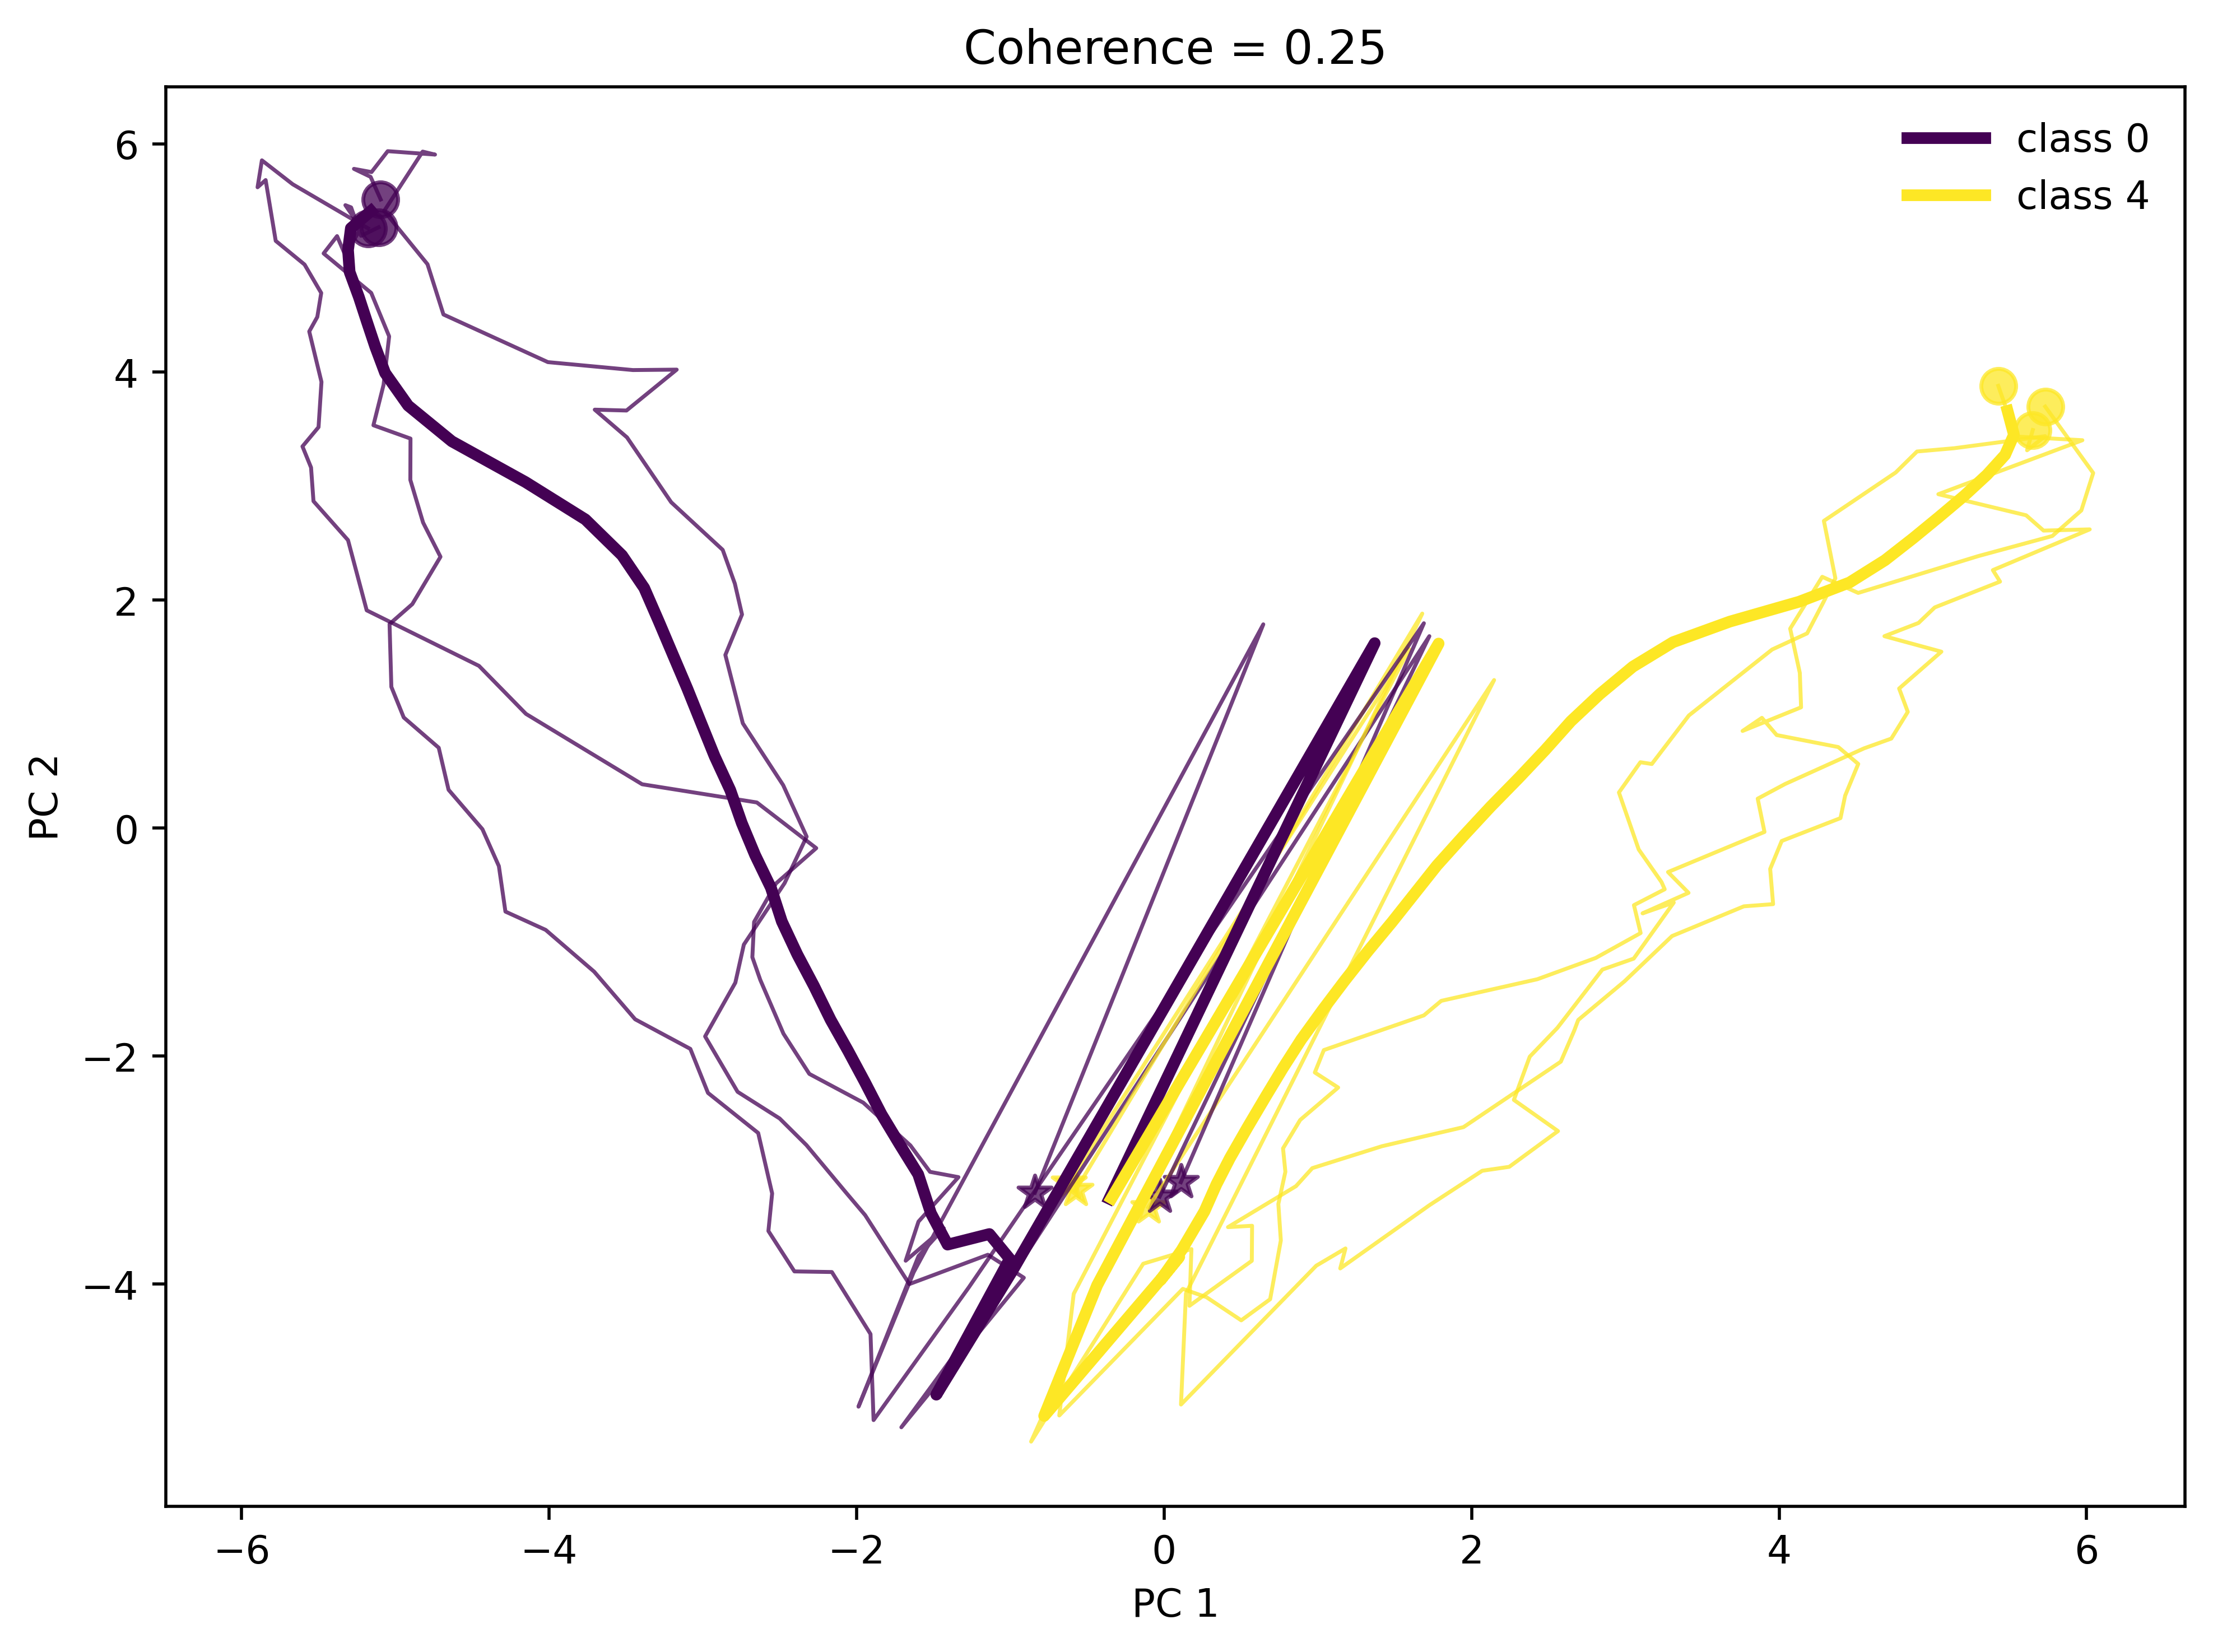

In [112]:
Z = p.plot(
    pca_acts[:, :], decisions,
    overlay_examples_k=3,
    overlay_mode="closest",     # 'closest' | 'farthest' | 'random'
    overlay_classes=None,       # None => all classes
    plot_all_endpoints=False,    # scatter ENDPOINTS for all trials
    per_class_mean=True,
    plot_trajectory=False,
    title="Coherence = 0.25",
    alpha=0.75,
    collapse_to_class_means=False,
    extra_point_timestep=39,
    n_components=2,
    return_data=True
)

# Phase Plot + Stability Analysis

In [136]:
def rotate_45(trajs, normalize_axes=False, eps=1e-12, clockwise=False):
    """
    Rotate (d,z) trajectories by ±45° to obtain (S1,S2) evidence coordinates.

    With clockwise=True (the typical usage), this produces:
        S1 = (d + z) / sqrt(2)   — "sum" axis
        S2 = (-d + z) / sqrt(2)  — "difference" axis
    so that S1≈S2 corresponds to the decision boundary.

    Args:
        trajs:          (N, T, 2) array. [...,0]=d (PC1), [...,1]=z (PC2).
        normalize_axes: If True, z-score d and z across all (N*T) points before
                        rotating. Useful when PC axes have very different scales.
        eps:            Small constant to avoid division by zero during z-scoring.
        clockwise:      If False, rotate +45° (counterclockwise).
                        If True, rotate -45° (clockwise) — the standard choice
                        that aligns S1,S2 with competing evidence streams.
    Returns:
        (N, T, 2) rotated coordinates with [...,0]=S1, [...,1]=S2.
    """
    X = np.asarray(trajs)
    assert X.ndim == 3 and X.shape[2] == 2, "trajs must be (N,T,2)"

    d = X[..., 0]
    z = X[..., 1]

    if normalize_axes:
        d = (d - d.mean()) / (d.std() + eps)
        z = (z - z.mean()) / (z.std() + eps)

    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    c = inv_sqrt2
    s = inv_sqrt2

    # Rotation matrix R(theta) applied to [d, z]^T:
    # [S1]   [ c  -s] [d]
    # [S2] = [ s   c] [z]
    #
    # For theta = -45° (clockwise), flip the sign of s.
    if clockwise:
        s = -s

    S1 = c * d - s * z
    S2 = s * d + c * z

    return np.stack([S1, S2], axis=-1)


# --------------------------------------------------------
# Linearize in (S1,S2) around the decision boundary
# (where |S1 - S2| is small; i.e., near the separatrix)
# --------------------------------------------------------
def linearize_in_S_space(trajs_S, dt=1.0, diff_band=0.05,
                         slow_quantile=0.1, neighborhood_radius=0.1,
                         min_samples=200, difference_method="central_difference"):
    """
    Linearize 2D dynamics in (S1,S2) near the decision boundary S1≈S2.

    Estimates velocities via finite differences, finds the slowest-flow region
    near the boundary, and fits a local linear model dS/dt ≈ A (S - s*).

    Args:
        trajs_S:             (N, T, 2) trajectories with [...,0]=S1, [...,1]=S2.
        dt:                  Time step between consecutive frames. Must be 1.0
                             for discrete-frame data (1 frame = 1 unit of time).
        diff_band:           Boundary selection threshold: keeps points where
                             |S1 - S2| <= diff_band.
        slow_quantile:       Fraction (0,1] of boundary points to keep when
                             estimating s* (keeps the slowest q-fraction).
        neighborhood_radius: Radius around s* for the local Jacobian fit.
                             If too few points fall inside, automatically relaxes
                             to the closest min_samples points.
        min_samples:         Minimum number of samples required for the lstsq fit.
        difference_method:   "central_difference" or "forward_difference".
    Returns:
        s_star:    (2,) estimated slow point on the boundary (proxy for saddle).
        A:         (2,2) local Jacobian: dS/dt ≈ A @ (S - s*).
        evals:     (2,) eigenvalues of A. Expect one >0 (unstable) and one <0
                   (stable) if s* is a saddle.
        evecs:     (2,2) eigenvectors of A (columns).
        idx_neigh: (M,) indices into the flattened midpoint array of samples
                   used in the fit.
    """
    S = np.asarray(trajs_S)
    assert S.ndim == 3 and S.shape[2] == 2, "trajs_S must be (N,T,2)"
    N, T, _ = S.shape

    # Midstep states & velocities via finite differences
    if difference_method == "central_difference":
        dS = (S[:, 2:, :] - S[:, :-2, :]) / (2.0 * dt)  # (N, T-2, 2)
        Smid = S[:, 1:-1, :]                               # (N, T-2, 2)
    else:
        dS = (S[:, 1:, :] - S[:, :-1, :]) / dt      # (N, T-1, 2)
        Smid = 0.5 * (S[:, 1:, :] + S[:, :-1, :])     # (N, T-1, 2)

    # Flatten across trials and time
    Sm = Smid.reshape(-1, 2)
    dSm = dS.reshape(-1, 2)

    # Select points near the decision boundary: |S1 - S2| small
    diff = Sm[:, 0] - Sm[:, 1]
    band_mask = np.abs(diff) <= diff_band
    if not np.any(band_mask):
        raise ValueError("No samples found near boundary; increase diff_band.")

    # Locate s* as the mean of the slowest points in the boundary band
    speeds = np.linalg.norm(dSm[band_mask], axis=1)
    q = max(1, int(np.ceil(slow_quantile * speeds.size)))
    slow_idx_band = np.argsort(speeds)[:q]
    slow_points = Sm[band_mask][slow_idx_band]
    s_star = slow_points.mean(axis=0)

    # Build local neighborhood around s* for the Jacobian fit
    deltas = Sm - s_star[None, :]
    radii = np.linalg.norm(deltas, axis=1)
    neigh_mask = radii <= neighborhood_radius
    if neigh_mask.sum() < min_samples:
        # Relax: take closest min_samples (or 2% of data) points
        order = np.argsort(radii)
        take = max(min_samples, int(0.02 * Sm.shape[0]))
        neigh_mask = np.zeros_like(radii, dtype=bool)
        neigh_mask[order[:take]] = True

    ΔS = deltas[neigh_mask]    # (M,2) displacements from s*
    dS_loc = dSm[neigh_mask]   # (M,2) velocities
    if ΔS.shape[0] < 2:
        raise ValueError("Insufficient neighborhood samples to fit A.")

    # Fit dS/dt ≈ A @ (S - s*) via least-squares (no intercept, since s* is
    # chosen as the slow point so velocity ≈ 0 there).
    # lstsq solves: ΔS @ B ≈ dS_loc, so B = A^T.
    A_T, *_ = np.linalg.lstsq(ΔS, dS_loc, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    idx_neigh = np.where(neigh_mask)[0]
    return s_star, A, evals, evecs, idx_neigh

In [138]:
def midpts_and_vel(trajs_S, dt=1.0, difference_method="central_difference"):
    """
    Compute midpoint positions and velocities from trajectories.

    Args:
        trajs_S:           (N, T, 2) trajectories.
        dt:                Time step between frames. Use 1.0 for discrete frames.
        difference_method: "central_difference" — velocity at time t estimated as
                             (S[t+1] - S[t-1]) / (2*dt), position = S[t].
                           "forward_difference" — velocity estimated as
                             (S[t+1] - S[t]) / dt, position = midpoint of S[t] and S[t+1].
    Returns:
        Sm:  (M, 2) flattened midpoint positions.
        dSm: (M, 2) flattened velocity estimates at each midpoint.
    """
    if difference_method == "central_difference":
        Sm  = trajs_S[:, 1:-1, :].reshape(-1, 2)
        dSm = (trajs_S[:,2:,:] - trajs_S[:,:-2,:]).reshape(-1, 2) / (2.0*dt)
    else:
        Sm  = 0.5*(trajs_S[:,1:,:] + trajs_S[:,:-1,:]).reshape(-1, 2)
        dSm = (trajs_S[:,1:,:] - trajs_S[:,:-1,:]).reshape(-1, 2) / dt
    return Sm, dSm

def local_fixed_point(
    S_trajs,
    dt=1.0,
    diff_band=0.05,
    min_samples=200,
    difference_method="central_difference",
    init_mode="band",
    center=None,
    radius=None,
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,
    around_dilate=1.0
):
    """
    Find a local fixed point of the 2D dynamics and fit the Jacobian around it.

    Two-stage procedure:
      1. Fit an affine model dS/dt = A_aff @ S + b_aff on a neighborhood of slow
         points, then solve for the fixed point s* where dS/dt = 0.
      2. Refit a zero-intercept linear model dS/dt = A @ (S - s*) in a neighborhood
         around s* to get the final Jacobian and eigenvalues.

    Args:
        S_trajs:           (N, T, 2) trajectories in (S1, S2) space.
        dt:                Time step between frames. Use 1.0 for discrete frames.
                           This scales all velocities and eigenvalues — must be
                           consistent across fitting, diagnostics, and plotting.
        diff_band:         Used differently depending on init_mode:
                           - "band": selects points where |S1 - S2| <= diff_band.
                           - "global": unused.
                           - "around": defaults radius to diff_band if radius=None.
        min_samples:       Minimum number of points for the least-squares fits.
                           If the neighborhood is too sparse, the code falls back
                           to the closest min_samples points.
        difference_method: "central_difference" or "forward_difference".
        init_mode:         How to build the initial pool of candidate points:
                           - "band": points near the decision boundary |S1-S2| <= diff_band.
                           - "global": all midpoints (no spatial restriction).
                             NOTE: center, radius, lambda_center, around_dilate are
                             all IGNORED in this mode.
                           - "around": points within `radius` of `center`.
        center:            (2,) coordinates for "around" mode. The center of the
                           search ball for candidate slow points.
        radius:            Float, radius of the search ball for "around" mode.
                           Falls back to diff_band if None.
        nbhd_frac:         Fraction of total midpoints to use for the neighborhood
                           fit (takes max(min_samples, nbhd_frac * total)).
        damp:              Ridge damping for fallback fixed-point solve when A_aff
                           is singular.
        lambda_center:     Regularization strength pulling s* toward `center`.
                           Only active when init_mode="around" AND lambda_center > 0.
                           Solves: argmin_s ||A_aff @ s + b_aff||^2 + lambda * ||s - center||^2.
                           Higher values = s* stays closer to center but may not be
                           the true dynamical fixed point. The final Jacobian refit
                           partially compensates, but large values can bias eigenvalues.
        around_dilate:     Multiplier (>= 1.0) on radius for the FINAL Jacobian
                           refit neighborhood (stage 2). Only used in "around" mode.
                           Values > 1 widen the refit neighborhood beyond the initial
                           search ball, giving more data for the Jacobian fit.
    Returns:
        s_star: (2,) estimated fixed point location.
        A:      (2,2) local Jacobian: dS/dt ≈ A @ (S - s*).
        evals:  (2,) eigenvalues of A.
        evecs:  (2,2) eigenvectors of A (columns).
        take2:  (M,) indices into the flattened midpoint array of samples used
                in the final Jacobian fit.
    """
    S = np.asarray(S_trajs); assert S.ndim==3 and S.shape[2]==2
    Sm, dSm = midpts_and_vel(S, dt=dt, difference_method=difference_method)
    speeds_all = np.linalg.norm(dSm, axis=1)

    # ===== Stage 0: Build pool of candidate points =====
    if init_mode == "band":
        band = np.abs(Sm[:,0] - Sm[:,1]) <= diff_band
        if not np.any(band):
            raise ValueError("No samples satisfy |S1-S2| <= diff_band.")
        pool_idx = np.where(band)[0]

    elif init_mode == "global":
        pool_idx = np.arange(Sm.shape[0])

    elif init_mode == "around":
        if center is None:
            raise ValueError("Provide center=(x,y) for init_mode='around'.")
        r = diff_band if radius is None else float(radius)
        center = np.asarray(center, float).reshape(1,2)
        in_ball = np.linalg.norm(Sm - center, axis=1) <= r
        if not np.any(in_ball):
            raise ValueError("No samples within 'around' radius; increase radius or move center.")
        pool_idx = np.where(in_ball)[0]
    else:
        raise ValueError("init_mode must be 'band','global','around'.")

    # ===== Stage 1a: Provisional center from slowest points in pool =====
    k = max(50, min_samples)
    slow_ord = np.argsort(speeds_all[pool_idx])[:min(k, len(pool_idx))]
    center_est = Sm[pool_idx[slow_ord]].mean(0)

    # ===== Stage 1b: Collect neighborhood for affine fit =====
    # For "around" mode, restrict to pool_idx to stay local.
    # For "band"/"global", use all midpoints.
    if init_mode == "around":
        base_idx = pool_idx
    else:
        base_idx = np.arange(Sm.shape[0])

    radii = np.linalg.norm(Sm[base_idx] - center_est, axis=1)
    M1 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
    take_local = base_idx[np.argsort(radii)[:M1]]
    S_loc, dS_loc = Sm[take_local], dSm[take_local]

    # ===== Stage 1c: Affine fit dS/dt = A_aff @ S + b_aff =====
    # lstsq solves: [S, 1] @ AB ≈ dS_loc, where AB is (3, 2).
    # Row 0-1 of AB give A_aff^T, row 2 gives b_aff.
    S_aug = np.column_stack([S_loc, np.ones(len(S_loc))])
    AB, *_ = np.linalg.lstsq(S_aug, dS_loc, rcond=None)
    A_aff = AB[:2, :].T
    b_aff = AB[2, :]

    # ===== Stage 1d: Solve for fixed point s* where A_aff @ s* + b_aff = 0 =====
    try:
        if not (init_mode == "around" and lambda_center > 0):
            # Unconstrained: s* = -A_aff^{-1} @ b_aff
            s_star = -np.linalg.solve(A_aff, b_aff)
        else:
            # Trust-region: minimize ||A_aff s + b||^2 + lambda ||s - center||^2
            c = center.ravel() if center is not None else center_est
            AtA = A_aff.T @ A_aff
            rhs = -A_aff.T @ b_aff + lambda_center * c
            s_star = np.linalg.solve(AtA + lambda_center * np.eye(2), rhs)
    except np.linalg.LinAlgError:
        # Ridge-stabilized fallback for singular A_aff
        s_star = np.linalg.lstsq(A_aff + damp*np.eye(2), -b_aff, rcond=None)[0]

    # ===== Stage 2: Refit Jacobian in neighborhood of s* =====
    if init_mode == "around":
        r2 = (diff_band if radius is None else float(radius)) * float(max(1.0, around_dilate))
        in_ring = np.linalg.norm(Sm - s_star, axis=1) <= r2
        take2 = np.where(in_ring)[0]
        if take2.size < min_samples:
            # Fallback: use closest min_samples points from pool, but do NOT
            # overwrite s_star — keep the dynamically-computed fixed point.
            print(f"Warning: only {take2.size} points in refit neighborhood "
                  f"(need {min_samples}). Falling back to nearest {min_samples} "
                  f"points from pool. Consider increasing radius or around_dilate.")
            d2 = np.linalg.norm(Sm[base_idx] - s_star, axis=1)
            take2 = base_idx[np.argsort(d2)[:min_samples]]
    else:
        d2 = np.linalg.norm(Sm - s_star, axis=1)
        M2 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
        take2 = np.argsort(d2)[:M2]

    # Fit dS/dt = A @ (S - s*) with no intercept.
    # lstsq solves: ΔS @ B ≈ dS2, so B = A^T.
    ΔS = Sm[take2] - s_star
    dS2 = dSm[take2]
    A_T, *_ = np.linalg.lstsq(ΔS, dS2, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    return s_star, A, evals, evecs, take2

# ---------- empirical field on a grid ----------
def compute_empirical_field_S(
    trajs_S, dt=1.0, nbins=30, min_count=5, extent=None, difference_method="central_difference"
):
    """
    Build an averaged empirical vector field on a uniform grid.

    Bins all midpoint/velocity pairs into a 2D grid and averages velocities
    per bin. Used for quiver-plot visualization of the flow field.

    Args:
        trajs_S:           (N, T, 2) trajectories.
        dt:                Time step (must match the dt used everywhere else).
        nbins:             Number of bins along each axis.
        min_count:         Minimum samples per bin to include in the field.
        extent:            Optional ((s1min, s1max), (s2min, s2max)). If None,
                           auto-computed from the 2nd–98th percentile of data.
        difference_method: "central_difference" or "forward_difference".
    Returns:
        dict with keys: S1g, S2g (meshgrid), U, V (velocity components),
        mask (valid bins), s1_edges, s2_edges, extent, difference_method.
    """
    S1 = trajs_S[..., 0]; S2 = trajs_S[..., 1]
    if difference_method == "central_difference":
        dS1 = (S1[:, 2:] - S1[:, :-2]) / (2.0 * dt)
        dS2 = (S2[:, 2:] - S2[:, :-2]) / (2.0 * dt)
        S1m = S1[:, 1:-1]
        S2m = S2[:, 1:-1]
    else:
        dS1 = (S1[:, 1:] - S1[:, :-1]) / dt
        dS2 = (S2[:, 1:] - S2[:, :-1]) / dt
        S1m = 0.5 * (S1[:, 1:] + S1[:, :-1])
        S2m = 0.5 * (S2[:, 1:] + S2[:, :-1])

    s1_all, s2_all = S1m.ravel(), S2m.ravel()
    u_all,  v_all  = dS1.ravel(), dS2.ravel()

    if extent is None:
        s1min, s1max = np.percentile(s1_all, [2, 98])
        s2min, s2max = np.percentile(s2_all, [2, 98])
        pad1 = 0.06 * (s1max - s1min + 1e-12)
        pad2 = 0.06 * (s2max - s2min + 1e-12)
        s1min, s1max = s1min - pad1, s1max + pad1
        s2min, s2max = s2min - pad2, s2max + pad2
    else:
        (s1min, s1max), (s2min, s2max) = extent

    s1_edges = np.linspace(s1min, s1max, nbins + 1)
    s2_edges = np.linspace(s2min, s2max, nbins + 1)

    xi = np.clip(((s1_all - s1min) / (s1max - s1min) * nbins).astype(int), 0, nbins - 1)
    yi = np.clip(((s2_all - s2min) / (s2max - s2min) * nbins).astype(int), 0, nbins - 1)

    U = np.zeros((nbins, nbins)); V = np.zeros((nbins, nbins)); C = np.zeros((nbins, nbins), int)
    for i in range(s1_all.size):
        U[yi[i], xi[i]] += u_all[i]
        V[yi[i], xi[i]] += v_all[i]
        C[yi[i], xi[i]] += 1

    mask = C >= min_count
    U[mask] /= C[mask]; V[mask] /= C[mask]

    s1_cent = 0.5 * (s1_edges[:-1] + s1_edges[1:])
    s2_cent = 0.5 * (s2_edges[:-1] + s2_edges[1:])
    S1g, S2g = np.meshgrid(s1_cent, s2_cent)

    return dict(
        S1g=S1g, S2g=S2g, U=U, V=V, mask=mask,
        s1_edges=s1_edges, s2_edges=s2_edges,
        extent=((s1min, s1max), (s2min, s2max)),
        difference_method=difference_method
    )


# ---------- combined field + local linearization plot ----------
def plot_combined_vector_and_linearization(
    trajs_S, dt=1.0, nbins=30, min_count=5, density_bg=True, cmap_bg="Greys",
    s_star=None, A=None, evals=None, evecs=None, idx_neigh=None,
    field=None, field_extent=0.15, field_res=17, eigen_scale=0.08,
    title="Empirical field + local linearization (S1,S2)",
    difference_method="central_difference",
    around_center=None, around_radius=None,
    show_neighborhood=False, num_trajs_to_plot=15
):
    """
    Plot the empirical vector field with optional overlays for the fixed point,
    eigenvectors, search region, fit neighborhood, and sample trajectories.

    IMPORTANT: The `dt` here must match the `dt` used when fitting s*/A/evals.
    A mismatch will make the quiver field inconsistent with the eigenvectors.

    Args:
        trajs_S:          (N, T, 2) trajectories.
        dt:               Time step — MUST match the dt used to compute s*, A, evals.
        nbins:            Grid resolution for the empirical field.
        min_count:        Min samples per grid bin to show an arrow.
        density_bg:       If True, show a density heatmap behind the quiver field.
        s_star, A, evals, evecs: Fixed point and Jacobian from local_fixed_point().
        idx_neigh:        Indices of points used in the Jacobian fit (for visualization).
        around_center:    (2,) center of the search region (draws dashed circle).
        around_radius:    Radius of the search region circle.
        show_neighborhood: If True, scatter the fit-neighborhood points.
        num_trajs_to_plot: Number of random sample trajectories to overlay.
    """
    # Compute or reuse the empirical field (must use same dt and difference_method)
    if field is None:
        field = compute_empirical_field_S(trajs_S, dt, nbins, min_count,
                                          extent=None, difference_method=difference_method)
    else:
        assert field.get("difference_method", difference_method) == difference_method, \
            f"Field computed with {field.get('difference_method')} but plot asked for {difference_method}"

    S1g, S2g, U, V, mask = field["S1g"], field["S2g"], field["U"], field["V"], field["mask"]
    (s1min, s1max), (s2min, s2max) = field["extent"]
    s1_edges, s2_edges = field["s1_edges"], field["s2_edges"]

    Sm, _ = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    s1_all, s2_all = Sm[:, 0], Sm[:, 1]

    fig, ax = plt.subplots(figsize=(6, 6))
    if density_bg:
        H, _, _ = np.histogram2d(s1_all, s2_all, bins=[s1_edges, s2_edges])
        ax.imshow(H.T, origin="lower", extent=[s1min, s1max, s2min, s2max],
                  cmap=cmap_bg, alpha=0.28, interpolation="bilinear")

    # Quiver: arrows normalized to 95th-percentile magnitude for uniform visibility.
    # NOTE: this shows flow DIRECTION but not speed. Slow regions near saddles
    # will have arrows of similar length to fast regions.
    Uplot, Vplot = np.where(mask, U, 0.0), np.where(mask, V, 0.0)
    mag = np.hypot(Uplot[mask], Vplot[mask]); scale = np.nanpercentile(mag, 95) or 1.0
    ax.quiver(S1g[mask], S2g[mask], Uplot[mask]/scale, Vplot[mask]/scale,
              angles="xy", scale_units="xy", scale=1.0,
              width=0.002, headwidth=2.5, headlength=3.5, alpha=0.9, color="tab:blue",
              label="empirical field")

    # Overlays: search region circle
    if around_center is not None and around_radius is not None:
        circ = Circle(tuple(around_center), float(around_radius),
                      fill=False, lw=1.6, ls="--", color="orange", alpha=0.95)
        ax.add_patch(circ)
        ax.scatter([around_center[0]], [around_center[1]], s=40, color="orange", zorder=5, label="around center")

    # Overlay: fixed point
    if s_star is not None:
        ax.scatter([s_star[0]], [s_star[1]], s=60, color="crimson", zorder=5, label="s*")

    # Overlay: fit neighborhood points
    if show_neighborhood and (idx_neigh is not None):
        neigh_mask = np.zeros(Sm.shape[0], dtype=bool); neigh_mask[idx_neigh] = True
        ax.scatter(Sm[neigh_mask, 0], Sm[neigh_mask, 1], s=8, color="tab:purple",
                   alpha=0.5, label="fit neighborhood", zorder=4)

    # Overlay: eigenvectors at s* (red=unstable λ>0, teal=stable λ<0)
    if (A is not None) and (evals is not None) and (evecs is not None) and (s_star is not None):
        span = max(s1max - s1min, s2max - s2min)
        for lam, vec in zip(np.real(evals), np.real(evecs.T)):
            v = vec / (np.linalg.norm(vec) + 1e-12)
            length = eigen_scale * span
            color = "tomato" if lam > 0 else "teal"
            ax.arrow(s_star[0], s_star[1], length*v[0], length*v[1],
                     head_width=0.02*span, head_length=0.03*span,
                     length_includes_head=True, color=color, alpha=0.95, lw=2.0, zorder=6)
        ax.plot([], [], color="tomato", lw=2, label="unstable eigvec (λ>0)")
        ax.plot([], [], color="teal",   lw=2, label="stable eigvec (λ<0)")

    # Overlay: random sample trajectories
    if num_trajs_to_plot > 0:
        N = trajs_S.shape[0]
        idx = np.random.choice(N, size=min(num_trajs_to_plot, N), replace=False)
        for k in idx:
            ax.plot(trajs_S[k,:,0], trajs_S[k,:,1], lw=1.0, alpha=0.5, color="tab:gray")

    ax.axhline(0, color='k', lw=0.6, alpha=0.25); ax.axvline(0, color='k', lw=0.6, alpha=0.25)
    buffer = 0.1 * max(s1max - s1min, s2max - s2min)
    ax.set_xlim(s1min - buffer, s1max + buffer)
    ax.set_ylim(s2min - buffer, s2max + buffer)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("S1"); ax.set_ylabel("S2"); ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc="best")
    plt.tight_layout(); plt.show()

def find_slowest_saddle_in_area(
    trajs_S,
    *,
    dt=1.0,
    difference_method="central_difference",
    circle_center=None,
    circle_radius=None,
    box_extent=None,
    candidate_frac=0.02,
    candidate_max=500,
    search_radius=0.25,
    min_samples=200,
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,
    around_dilate=1.25,
    imag_tol=1e-3
):
    """
    Search for a saddle point among the slowest-flow candidates in a spatial area.

    Iterates through slow candidates (sorted by speed), fits a local fixed point
    for each via local_fixed_point(init_mode="around"), and returns the first one
    whose eigenvalues indicate a saddle (one positive, one negative, both real).

    Args:
        trajs_S:           (N, T, 2) trajectories in (S1, S2) space.
        dt:                Time step between frames. Use 1.0 for discrete-frame data.
                           MUST be consistent with dt used in diagnostics and plotting.
        difference_method: "central_difference" or "forward_difference".

        --- Search area (specify exactly one) ---
        circle_center:     (2,) center of circular search area.
        circle_radius:     Radius of the circular search area. All midpoints within
                           this circle are considered as candidate slow points.
        box_extent:        Alternative to circle: ((s1min, s1max), (s2min, s2max)).

        --- Candidate selection ---
        candidate_frac:    Fraction of points inside the area to try as candidates,
                           ranked by slowest flow speed (default 2%).
        candidate_max:     Maximum number of candidates to try.

        --- Passed to local_fixed_point for each candidate ---
        search_radius:     Radius around each candidate for the local "around" pool
                           AND initial neighborhood. Controls how local the fit is.
        min_samples:       Minimum samples for each local fit.
        nbhd_frac:         Fraction of total data for neighborhood size.
        damp:              Ridge damping for singular matrices.
        lambda_center:     Regularization pulling s* toward the candidate center.
        around_dilate:     Multiplier on search_radius for the final Jacobian refit.

        --- Saddle test ---
        imag_tol:          Maximum allowed imaginary part of eigenvalues. Eigenvalues
                           with |imag| > imag_tol are rejected (not a real saddle).
    Returns:
        Same as local_fixed_point: (s_star, A, evals, evecs, used_idx).
    Raises:
        RuntimeError if no saddle found among candidates.
    """
    Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    speeds = np.linalg.norm(dSm, axis=1)

    # --- Area mask ---
    use_circle = (circle_center is not None and circle_radius is not None)
    use_box = (box_extent is not None)
    if use_circle == use_box:
        raise ValueError("Specify exactly one area: (circle_center & circle_radius) OR box_extent.")

    if use_circle:
        c = np.asarray(circle_center, float).reshape(1, 2)
        area_mask = np.linalg.norm(Sm - c, axis=1) <= float(circle_radius)
    else:
        (s1min, s1max), (s2min, s2max) = box_extent
        area_mask = (Sm[:,0] >= s1min) & (Sm[:,0] <= s1max) & (Sm[:,1] >= s2min) & (Sm[:,1] <= s2max)

    idx_area = np.where(area_mask)[0]
    if idx_area.size == 0:
        raise RuntimeError("No samples inside the specified area.")

    # --- Pick slowest candidates inside area ---
    n_cand = max(1, min(int(candidate_frac * idx_area.size), candidate_max))
    cand_idx = idx_area[np.argsort(speeds[idx_area])[:n_cand]]
    cand_centers = Sm[cand_idx]

    # --- Try candidates (slowest first); accept first true saddle ---
    for center in cand_centers:
        try:
            s_star, A, evals, evecs, used_idx = local_fixed_point(
                trajs_S,
                dt=dt,
                diff_band=search_radius,
                min_samples=min_samples,
                difference_method=difference_method,
                init_mode="around",
                center=center,
                radius=search_radius,
                nbhd_frac=nbhd_frac,
                damp=damp,
                lambda_center=lambda_center,
                around_dilate=around_dilate
            )
        except ValueError:
            continue

        # Saddle test: both eigenvalues must be real with mixed signs
        evals = np.asarray(evals)
        re = np.real(evals); im = np.abs(np.imag(evals))
        if np.all(im < imag_tol) and (np.any(re > 0) and np.any(re < 0)):
            return s_star, A, evals, evecs, used_idx

    raise RuntimeError("No saddle found among slow candidates inside the area.")

s*: [-2.99553611 -2.49013272]
A:
 [[ 0.18029361 -0.00059799]
 [ 0.02616675  0.20500191]]
evals: [0.18094402 0.2043515 ]
mean flow near s*: [0.37750694 0.14867632]


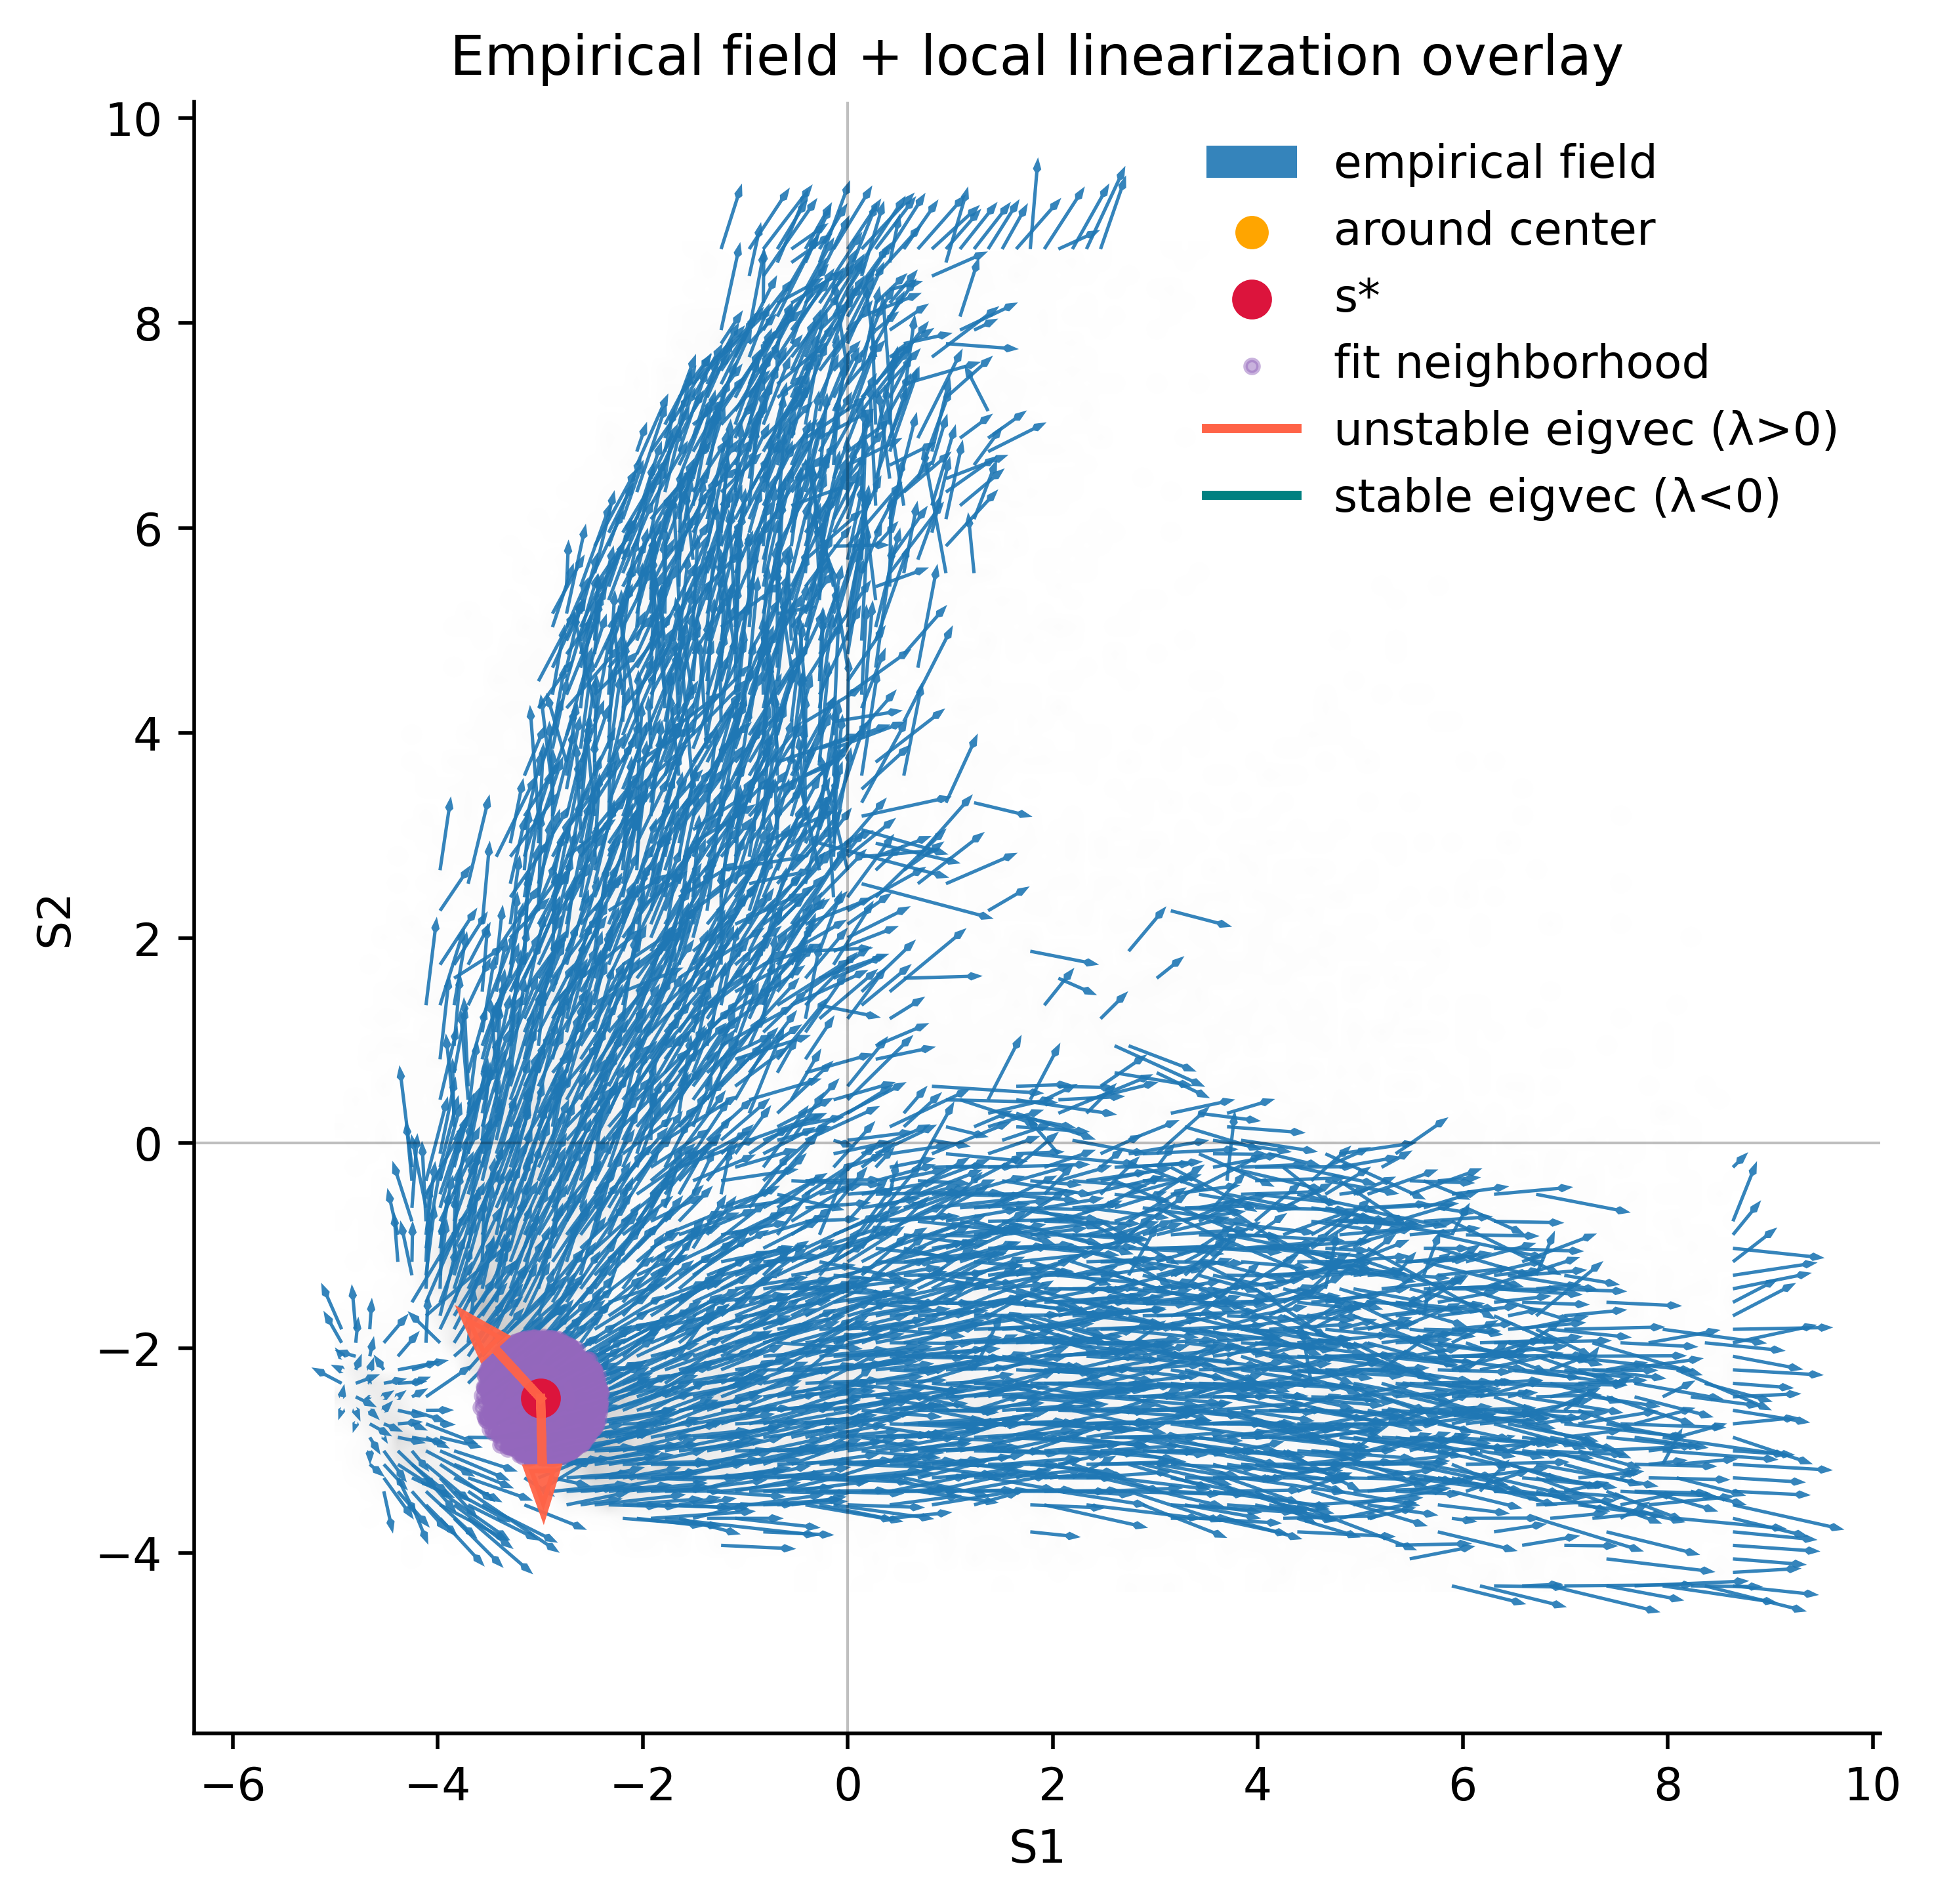

In [141]:
# ---------- example usage ----------
difference_method = "central_difference"  # or "forward_difference"
dt = 1.0  # 1 frame = 1 unit of time (natural for discrete-frame data)
trajs_S = rotate_45(Z, clockwise=True)
trajs_S = trajs_S[:, 2:]  # optionally trim early transient frames

around_center = (-3, -2.5)
around_radius = 0.3

# Find local fixed point using init_mode="around":
#   - Collects candidate slow points within `radius` of `center`
#   - Fits affine model to find s*, with lambda_center pulling s* toward center
#   - Refits Jacobian in neighborhood of s* (dilated by around_dilate)
s_star, A, evals, evecs, used_idx = local_fixed_point(
    trajs_S,
    dt=dt,
    diff_band=0.25,
    min_samples=200,
    difference_method=difference_method,
    init_mode="around",            # use "around" so center/radius/lambda_center take effect
    center=around_center,          # (S1, S2) center of search ball
    radius=around_radius,          # radius of search ball for candidate slow points
    nbhd_frac=0.02,               # fraction of total data for neighborhood size
    damp=1e-6,                     # ridge damping if A_aff is singular
    lambda_center=1,               # regularization pulling s* toward center
    around_dilate=2                # multiplier on radius for final Jacobian refit neighborhood
)
print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# Diagnostic: mean flow near s* (uses same dt and difference_method)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# Plot with overlays
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=around_radius,
    show_neighborhood=True, num_trajs_to_plot=0
)

In [ ]:
around_center = (-3, -2.5)
search_radius = 0.25   # radius around each candidate for the local affine fit
circle_radius = 0.5    # radius of the outer search area for collecting candidates

difference_method = "central_difference"

# Use dt=1.0 consistently (1 frame = 1 time unit).
# Previously this used dt=0.5, which doubled all velocities/eigenvalues
# and was inconsistent with the diagnostic and plot below.
s_star, A, evals, evecs, used_idx = find_slowest_saddle_in_area(
    trajs_S,
    dt=dt,                         # use the same dt as everywhere else
    difference_method=difference_method,
    circle_center=around_center,   # center of the circular candidate area
    circle_radius=circle_radius,   # radius of the circular candidate area
    search_radius=search_radius,   # radius for each local_fixed_point call
    min_samples=200,
    lambda_center=4,               # regularization pulling s* toward each candidate
    around_dilate=1,               # no dilation of the Jacobian refit neighborhood
)

print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# Diagnostic: mean flow near s* (same dt and difference_method as the fit)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# Plot with overlays (same dt as the fit)
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=search_radius,
    show_neighborhood=True
)

## Dynamical Analysis                                                                                                                                                                               
                
To study the geometry of the model's decision-making dynamics, we project network activations into a low-dimensional *decoding space* and characterize the resulting flow field.                    
                
**Pipeline:**
1. **Decoder training.** A small MLP decoder (32 hidden units) is trained to classify network activations at late timesteps (frames 30–40) into the 8 motion directions.
2. **Projection.** All activations (frames 0–40) are passed through the decoder's hidden layer (ReLU), yielding 32-dimensional representations that emphasize decision-relevant structure.
3. **PCA.** The top 2 principal components of these representations define a 2D trajectory space. Each trial becomes a curve $(d(t), z(t))$.
4. **Rotation.** The PC axes are rotated 45° to obtain coordinates $(S_1, S_2) = \frac{1}{\sqrt{2}}(d+z,\; {-d}+z)$, which approximately align with the two competing evidence streams.

**Analysis.** In $(S_1, S_2)$ space, we:
- Estimate the empirical velocity field $\dot{S}$ via finite differences across trials.
- Locate a candidate saddle point $s^*$ near the decision boundary ($S_1 \approx S_2$) by finding the region of slowest flow.
- Fit a local Jacobian $A$ (via linear regression of $\dot{S}$ on $S - s^*$), whose real eigenvalues characterize stability: one positive (unstable, separatrix direction) and one negative (stable,
attractor direction).

# Error Trials (Timing and Trajectory Viz)

## Timing

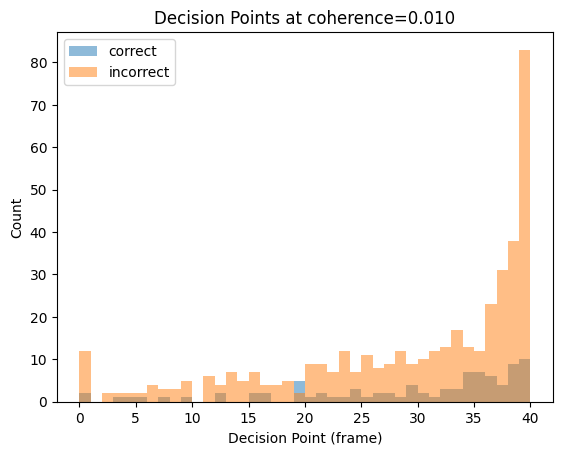

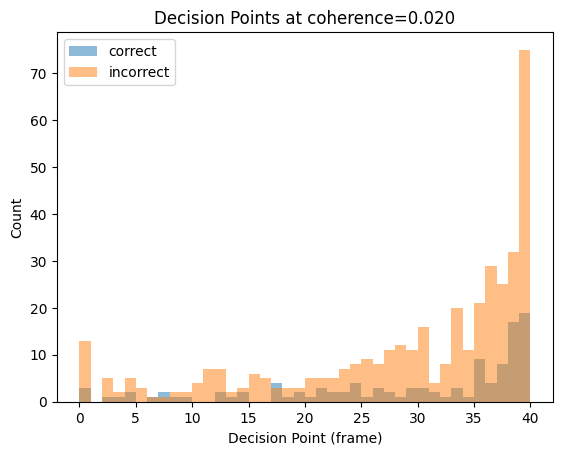

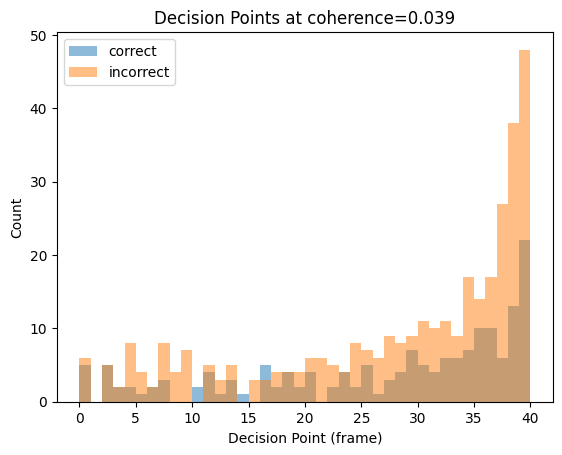

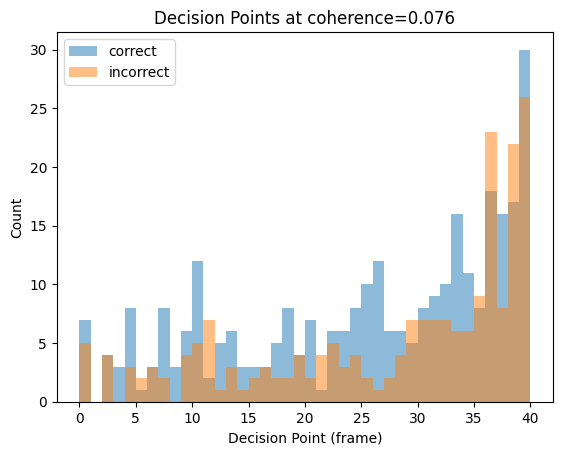

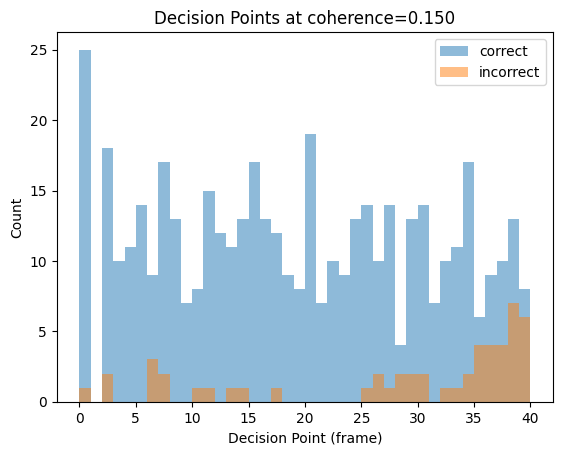

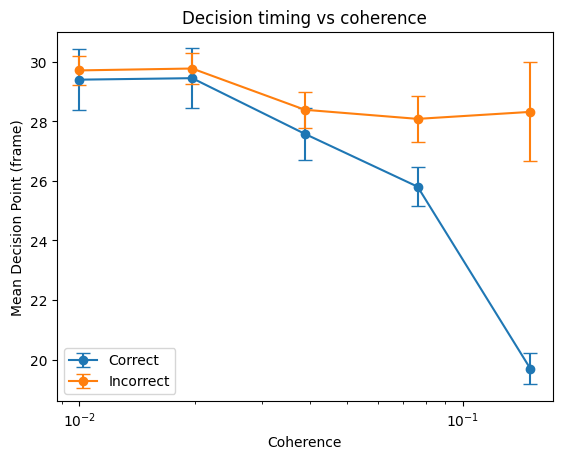

In [ ]:
coherences = np.logspace(np.log10(0.01), np.log10(0.15), 5).tolist()
samples_per_epoch = 512

summary_mean_correct = []
summary_err_correct = []
summary_mean_incorrect = []
summary_err_incorrect = []

for coherence in coherences:
    # Build loader kwargs from this parameterization
    loader_kwargs = {
        'seed': 10,
        'dataset': "correlated_dots",
        'n_dots': 100,
        'resolution': (128, 128),
        'n_frames': 40,
        'correlation': coherence,  # Update to use the looped coherence!
        'max_speed': 1,
        'samples_per_epoch': samples_per_epoch,
        'batch_size': 32,
    }

    data_loader, test_loader = initialize_dataloader(**loader_kwargs)

    inputs, labels = [], []
    for x, y in data_loader:
        inputs.append(x)
        labels.append(y)

    inputs = torch.cat(inputs)
    labels = torch.cat(labels)[:, 0]

    predictions = np.zeros((len(labels), 40))
    timestamp_idxs = np.arange(1, 41)
    for timestamp_idx in timestamp_idxs:
        inputs_at_timestamp = inputs[:, :timestamp_idx, :, :, :].to(device)
        logits = classifier(inputs_at_timestamp, num_steps=timestamp_idx).detach().cpu()
        _, predicted = torch.max(logits, 1)
        predictions[:, timestamp_idx - 1] = predicted.numpy()

    correct = predictions[:, -1] == labels

    decision_points = np.zeros(len(labels))
    for sample_idx in range(len(labels)):
        for i in range(39, 0, -1):
            if predictions[sample_idx, i] != predictions[sample_idx, -1]:
                decision_points[sample_idx] = i + 1
                break

    correct_decision_points = decision_points[correct]
    incorrect_decision_points = decision_points[~correct]

    # For summary plot:
    def mean_and_err(x):
        x = x[x > 0]  # Exclude undecided or always-consistent cases (dec pt = 0)
        if len(x) == 0:
            return np.nan, np.nan
        return np.mean(x), np.std(x) / np.sqrt(len(x))

    m_corr, err_corr = mean_and_err(correct_decision_points)
    m_incorr, err_incorr = mean_and_err(incorrect_decision_points)
    summary_mean_correct.append(m_corr)
    summary_err_correct.append(err_corr)
    summary_mean_incorrect.append(m_incorr)
    summary_err_incorrect.append(err_incorr)

    plt.hist(correct_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="correct")
    plt.hist(incorrect_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="incorrect")
    plt.xlabel("Decision Point (frame)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title(f"Decision Points at coherence={coherence:.3f}", fontsize=14, fontweight='bold')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().tick_params(labelsize=10)
    plt.legend()
    plt.show()

# Summary plot
plt.errorbar(
    coherences, summary_mean_correct, yerr=summary_err_correct, label="Correct", marker='o', capsize=5
)
plt.errorbar(
    coherences, summary_mean_incorrect, yerr=summary_err_incorrect, label="Incorrect", marker='o', capsize=5
)
plt.xlabel("Coherence", fontsize=12)
plt.ylabel("Mean Decision Point (frame)", fontsize=12)
plt.title("Decision timing vs coherence", fontsize=14, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.xscale('log')
plt.show()

## Trajectory

In [ ]:
# Project all trials into the decoder PC space
trajs_all = p.transform(pca_acts[:, 2:])   # (N, T', max_components)
xy_all = trajs_all[:, :, :2]               # use first 2 PCs for 2D plot

correct_idx = np.where(train_decisions == train_labels)[0]
n_correct_show = min(30, len(correct_idx))
correct_sample = np.random.default_rng(0).choice(correct_idx, n_correct_show, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left: correct trial exemplars + class means ----
p.plot(
    pca_acts[:, 2:], decisions,
    ax=axes[0],
    per_class_mean=True,
    collapse_to_class_means=False,
    selected_trials=correct_sample.tolist(),
    overlay_examples_k=0,
    n_components=2,
    title=f"Correct trials (n={len(correct_idx)})",
    show=False,
    alpha=0.4,
)

# ---- Right: class means + error trials colored by TRUE label ----
# Draw class means first
p.plot(
    pca_acts[:, 2:], decisions,
    ax=axes[1],
    per_class_mean=True,
    collapse_to_class_means=False,
    overlay_examples_k=0,
    n_components=2,
    title=f"Error trials colored by true label (n={len(error_trials)})",
    show=False,
    alpha=0.5,
)

# Overlay error trial trajectories, colored by TRUE label so we can see
# where the trial "should" have gone vs where it ended up
for i in error_trials:
    true_cls = p.class_to_index_.get(int(train_labels[i]), -1)
    if true_cls < 0:
        continue
    col = p.color_map_.get(true_cls, (0.5, 0.5, 0.5))
    xy = xy_all[i]
    axes[1].plot(xy[:, 0], xy[:, 1], '-', lw=1.0, alpha=0.55, color=col)
    axes[1].scatter(xy[0, 0], xy[0, 1], s=50, marker='*', color=col, alpha=0.7, zorder=4)
    # black X at endpoint to show it landed in the wrong attractor
    axes[1].scatter(xy[-1, 0], xy[-1, 1], s=60, marker='x', color='k', linewidths=1.5, alpha=0.85, zorder=5)

axes[1].scatter([], [], marker='x', color='k', s=60, linewidths=1.5, label='error endpoint')
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


NameError: name 'p' is not defined

# Ramping Activity by Channel and Direction

In [39]:
DIRECTION_NAMES = {
    0: "E", 1: "W", 2: "N", 3: "S",
    4: "NE", 5: "NW", 6: "SE", 7: "SW",
    8: "ENE", 9: "NNE", 10: "NNW", 11: "WNW",
    12: "WSW", 13: "SSW", 14: "SSE", 15: "ESE",
    16: "NbE", 17: "EbN", 18: "EbS", 19: "SbE",
    20: "SbW", 21: "WbS", 22: "WbN", 23: "NbW",
}

# Compass bearing in degrees for each direction index
DIRECTION_BEARING = {
    2: 0, 16: 15, 9: 22.5, 4: 45, 8: 67.5, 17: 75,
    0: 90, 18: 105, 15: 112.5, 6: 135, 14: 157.5, 19: 165,
    3: 180, 20: 195, 13: 202.5, 7: 225, 12: 247.5, 21: 255,
    1: 270, 22: 285, 11: 292.5, 5: 315, 10: 337.5, 23: 345,
}

ACTIVITY_TYPE_LABELS = {
    "excitatory": ("Excitatory", 8),
    "inhibitory": ("Inhibitory", 4),
    "output": ("Output", 8),
}

# Clockwise from North (all 24 directions)
DIRECTIONS_CLOCKWISE = [2, 16, 9, 4, 8, 17, 0, 18, 15, 6, 14, 19, 3, 20, 13, 7, 12, 21, 1, 22, 11, 5, 10, 23]


def plot_ramping_activity(
    model,
    classifier,
    loader,
    num_samples=256,
    num_steps=40,
    dim=128,
    center=(64, 64),
    rf_size=8,
    directions=None,
    activity_type="excitatory",
    normalize=False,
    mask_rf=False,
    savepath=None,
    device=None,
):
    """
    Plot mean channel activity over time within a receptive field,
    broken down by dot-movement direction. One subplot per channel.

    If normalize=True, each channel is min-max normalized across all
    directions and timesteps to [0, 1].
    If mask_rf=True, zero out all input pixels outside the RF before inference.
    """
    if directions is None:
        directions = [0, 1, 2, 3]
    if activity_type not in ACTIVITY_TYPE_LABELS:
        raise ValueError(f"activity_type must be one of {list(ACTIVITY_TYPE_LABELS)}, got {activity_type!r}")

    type_str, n_channels = ACTIVITY_TYPE_LABELS[activity_type]
    classifier.eval()

    dir_traces = collect_rf_traces(
        model, loader, num_samples, num_steps, dim,
        center, rf_size, directions, activity_type, mask_rf, device,
    )

    # Compute per-channel normalization constants across all directions
    if normalize:
        ch_min = np.full(n_channels, np.inf)
        ch_max = np.full(n_channels, -np.inf)
        for d in directions:
            if dir_traces[d].shape[0] == 0:
                continue
            mean_trace = dir_traces[d].mean(axis=0)  # (T, C)
            ch_min = np.minimum(ch_min, mean_trace.min(axis=0))
            ch_max = np.maximum(ch_max, mean_trace.max(axis=0))
        ch_range = ch_max - ch_min
        ch_range[ch_range < 1e-12] = 1.0  # avoid division by zero

    # --- Plotting ---
    n_dirs = len(directions)
    colors = plt.cm.Set2(np.linspace(0, 1, max(n_dirs, 3)))

    n_cols = 4
    n_rows = math.ceil(n_channels / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True)
    axes_flat = axes.flatten() if n_rows > 1 else (axes if n_channels > 1 else [axes])

    for ch in range(n_channels):
        ax = axes_flat[ch]
        for d_idx, d in enumerate(directions):
            traces = dir_traces[d]  # (N_d, T, C)
            if traces.shape[0] == 0:
                continue
            mean_trace = traces[:, :, ch].mean(axis=0)
            sem = traces[:, :, ch].std(axis=0) / np.sqrt(traces.shape[0])
            if normalize:
                mean_trace = (mean_trace - ch_min[ch]) / ch_range[ch]
                sem = sem / ch_range[ch]
            T = len(mean_trace)
            t = np.arange(T)
            label = DIRECTION_NAMES.get(d, f"Dir {d}")
            ax.plot(t, mean_trace, color=colors[d_idx], linewidth=2, label=label)
            ax.fill_between(t, mean_trace - sem, mean_trace + sem,
                            color=colors[d_idx], alpha=0.15)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=10)
        ax.set_title(f"Channel {ch}", fontsize=14, fontweight='bold')
        if ch >= (n_rows - 1) * n_cols:
            ax.set_xlabel("Time Step", fontsize=12)
        if ch % n_cols == 0:
            ylabel = f"{'Norm. ' if normalize else ''}{type_str} Activity"
            ax.set_ylabel(ylabel, fontsize=12)

    for idx in range(n_channels, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    handles, labels_leg = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_leg, loc="upper right", fontsize=10, frameon=False)

    mask_str = " (RF masked)" if mask_rf else ""
    fig.suptitle(
        f"{'Normalized ' if normalize else ''}{type_str} Ramping Activity{mask_str} — "
        f"RF {rf_size}x{rf_size} at ({center[0]},{center[1]})",
        fontsize=16, y=1.02,
    )
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format="svg", bbox_inches="tight")
    plt.show()
    return dir_traces

In [16]:
# --- Configure stimulus and loader ---
n_frames = 40
resolution = (128, 128)
directions = [0, 1, 2, 3]  # E, W, N, S
n_dots = 100
correlation = 0.25
max_speed = 1
samples_per_epoch = 512

ramping_loader, _ = initialize_dataloader(
    seed=42,
    dataset="correlated_dots",
    resolution=resolution,
    n_frames=n_frames,
    correlation=correlation,
    max_speed=max_speed,
    samples_per_epoch=samples_per_epoch,
    batch_size=128,
    directions=directions,
    n_dots=n_dots,
)

In [ ]:
# --- Plot ramping activity (excitatory) ---
exc_traces = plot_ramping_activity(
    model,
    classifier,
    ramping_loader,
    num_samples=512,
    num_steps=n_frames,
    dim=resolution[0],
    center=(64, 64),       # center of 128x128
    rf_size=64,
    directions=directions,
    activity_type="excitatory", 
    # savepath="figures/dots_ramping_excitatory.svg",
)

In [47]:
def _make_rf_mask(dim, center, rf_size, device=None):
    """Create a binary mask that is 1 inside the RF and 0 outside. Shape: (1,1,1,H,W)."""
    half = rf_size // 2
    r0 = max(center[0] - half, 0)
    r1 = min(center[0] + half, dim)
    c0 = max(center[1] - half, 0)
    c1 = min(center[1] + half, dim)
    mask = torch.zeros(1, 1, 1, dim, dim, device=device)
    mask[:, :, :, r0:r1, c0:c1] = 1.0
    return mask


def collect_rf_traces(
    model,
    loader,
    num_samples,
    num_steps,
    dim,
    center,
    rf_size,
    directions,
    activity_type="excitatory",
    mask_rf=False,
    device=None,
):
    """
    Run model on loader and collect per-direction RF-averaged traces.

    Args:
        mask_rf: If True, zero out all input pixels outside the receptive field
                 before feeding to the model.

    Returns:
        dir_traces: dict mapping direction index -> np.array of shape (N_d, T, C)
    """
    if device is None:
        device = next(model.parameters()).device

    n_channels = ACTIVITY_TYPE_LABELS[activity_type][1]

    half = rf_size // 2
    r0 = max(center[0] - half, 0)
    r1 = min(center[0] + half, dim)
    c0 = max(center[1] - half, 0)
    c1 = min(center[1] + half, dim)

    dir_traces = {d: [] for d in directions}

    # Build reverse mapping: contiguous label -> direction key.
    # The CorrelatedDots dataset maps direction keys to contiguous labels
    # (0..N-1), so we need to map back to the original direction keys.
    raw_dataset = loader.dataset
    while hasattr(raw_dataset, 'dataset'):  # unwrap Subset layers
        raw_dataset = raw_dataset.dataset
    if hasattr(raw_dataset, 'direction_key_to_label'):
        label_to_dir_key = {v: k for k, v in raw_dataset.direction_key_to_label.items()}
    else:
        label_to_dir_key = None

    # Build RF mask if needed
    rf_mask = _make_rf_mask(dim, center, rf_size, device=device) if mask_rf else None

    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=min(num_samples, len(all_indices)), replace=False)
    subset_dataset = Subset(loader.dataset, subset_indices)
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False,
    )

    model.eval()
    with torch.no_grad():
        for batch_inputs, labels in tqdm(dataloader, desc="Collecting activations"):
            labels_flat = labels.squeeze(-1) if labels.ndim > 1 else labels
            batch_inputs = batch_inputs.to(device, non_blocking=True)

            if rf_mask is not None:
                batch_inputs = batch_inputs * rf_mask

            output_states, neuron_states, _ = model(batch_inputs, num_steps=num_steps)

            if activity_type == "output":
                activity = output_states[0].detach().cpu()
            elif activity_type == "excitatory":
                activity = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()
            else:
                activity = model.query_neuron_states(neuron_states, 0, 1).detach().cpu()

            rf_mean = activity[:, :, :, r0:r1, c0:c1].mean(dim=(-2, -1)).numpy()  # (B, T, C)

            for i in range(rf_mean.shape[0]):
                d = int(labels_flat[i].item())
                # Map contiguous label back to direction key
                if label_to_dir_key is not None:
                    d = label_to_dir_key.get(d, d)
                if d in dir_traces:
                    dir_traces[d].append(rf_mean[i])

            del activity, output_states, neuron_states
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    # Stack lists into arrays
    for d in dir_traces:
        if dir_traces[d]:
            dir_traces[d] = np.stack(dir_traces[d])  # (N_d, T, C)
        else:
            dir_traces[d] = np.empty((0, num_steps, n_channels))

    return dir_traces


def plot_input_example(
    loader,
    direction=0,
    center=(64, 64),
    rf_size=8,
    dim=128,
    mask_rf=False,
    n_frames_show=8,
    savepath=None,
):
    """
    Visualize example input frames, optionally with RF masking applied.

    Shows n_frames_show evenly-spaced frames from the first matching sample.
    The RF boundary is drawn as a red rectangle.
    """
    # Get label mapping
    raw_dataset = loader.dataset
    while hasattr(raw_dataset, 'dataset'):
        raw_dataset = raw_dataset.dataset
    if hasattr(raw_dataset, 'direction_key_to_label'):
        target_label = raw_dataset.direction_key_to_label.get(direction, direction)
    else:
        target_label = direction

    # Find a sample with the desired direction
    sample = None
    for inputs, labels in loader:
        labels_flat = labels.squeeze(-1) if labels.ndim > 1 else labels
        for i in range(labels_flat.shape[0]):
            if int(labels_flat[i].item()) == target_label:
                sample = inputs[i]  # (T, C, H, W)
                break
        if sample is not None:
            break

    if sample is None:
        print(f"No sample found for direction {direction}")
        return

    if mask_rf:
        rf_mask = _make_rf_mask(dim, center, rf_size).squeeze(0)  # (1,1,H,W)
        sample = sample * rf_mask

    n_total = sample.shape[0]
    frame_indices = np.linspace(0, n_total - 1, n_frames_show, dtype=int)

    half = rf_size // 2
    r0 = max(center[0] - half, 0)
    r1 = min(center[0] + half, dim)
    c0 = max(center[1] - half, 0)
    c1 = min(center[1] + half, dim)

    dir_name = DIRECTION_NAMES.get(direction, f"Dir {direction}")
    fig, axes = plt.subplots(1, n_frames_show, figsize=(2.5 * n_frames_show, 2.5))
    for ax_idx, t in enumerate(frame_indices):
        frame = sample[t, 0].numpy()  # (H, W), first channel
        axes[ax_idx].imshow(frame, cmap="gray", vmin=0, vmax=1)
        rect = plt.Rectangle((c0, r0), c1 - c0, r1 - r0,
                              linewidth=1, edgecolor='red', facecolor='none')
        axes[ax_idx].add_patch(rect)
        axes[ax_idx].set_title(f"t={t}", fontsize=9)
        axes[ax_idx].axis("off")

    mask_str = " (RF masked)" if mask_rf else ""
    fig.suptitle(f"Input Example — {dir_name}{mask_str}, RF {rf_size}x{rf_size} at ({center[0]},{center[1]})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format="svg", bbox_inches="tight")
    plt.show()


def plot_ramping_by_coherence(
    model,
    classifier,
    coherences,
    n_frames=40,
    resolution=(128, 128),
    directions=None,
    n_dots=100,
    max_speed=1,
    num_samples=512,
    samples_per_epoch=1024,
    center=(64, 64),
    rf_size=8,
    activity_type="excitatory",
    channel_agg="mean",
    normalize=False,
    mask_rf=False,
    savepath=None,
    device=None,
):
    """
    Plot channel-aggregated ramping activity over time, with subplots by direction
    and lines by coherence level.

    If normalize=True, each direction subplot is independently min-max normalized
    across all coherences and timesteps to [0, 1].
    """
    if directions is None:
        directions = [0, 1, 2, 3]

    type_str = ACTIVITY_TYPE_LABELS[activity_type][0]
    dim = resolution[0]

    # Collect traces for each coherence
    coherence_traces = {}
    for coh in coherences:
        print(f"Coherence = {coh}")
        loader, _ = initialize_dataloader(
            seed=42,
            dataset="correlated_dots",
            resolution=resolution,
            n_frames=n_frames,
            correlation=coh,
            max_speed=max_speed,
            samples_per_epoch=samples_per_epoch,
            batch_size=128,
            directions=directions,
            n_dots=n_dots,
        )
        coherence_traces[coh] = collect_rf_traces(
            model, loader, num_samples, n_frames, dim,
            center, rf_size, directions, activity_type, mask_rf, device,
        )

    # --- Plotting: one subplot per direction ---
    n_dirs = len(directions)
    cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(coherences)))

    n_cols = min(n_dirs, 4)
    n_rows = math.ceil(n_dirs / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
    if n_dirs == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    agg_fn = np.mean if channel_agg == "mean" else np.max

    for d_idx, d in enumerate(directions):
        ax = axes_flat[d_idx]

        # Pre-compute all mean traces for this direction to find normalization range
        dir_mean_traces = []
        dir_sem_traces = []
        for coh in coherences:
            traces = coherence_traces[coh][d]  # (N_d, T, C)
            if traces.shape[0] == 0:
                dir_mean_traces.append(None)
                dir_sem_traces.append(None)
                continue
            agg = agg_fn(traces, axis=-1)  # (N_d, T)
            dir_mean_traces.append(agg.mean(axis=0))
            dir_sem_traces.append(agg.std(axis=0) / np.sqrt(agg.shape[0]))

        if normalize:
            all_means = [m for m in dir_mean_traces if m is not None]
            if all_means:
                d_min = min(m.min() for m in all_means)
                d_max = max(m.max() for m in all_means)
                d_range = d_max - d_min if (d_max - d_min) > 1e-12 else 1.0
            else:
                d_min, d_range = 0.0, 1.0

        for c_idx, coh in enumerate(coherences):
            mean_trace = dir_mean_traces[c_idx]
            sem = dir_sem_traces[c_idx]
            if mean_trace is None:
                continue
            if normalize:
                mean_trace = (mean_trace - d_min) / d_range
                sem = sem / d_range
            t = np.arange(len(mean_trace))
            ax.plot(t, mean_trace, color=cmap[c_idx], linewidth=1.5, label=f"c={coh}")
            ax.fill_between(t, mean_trace - sem, mean_trace + sem,
                            color=cmap[c_idx], alpha=0.12)

        dir_name = DIRECTION_NAMES.get(d, f"Dir {d}")
        ax.set_title(dir_name, fontsize=12)
        if d_idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel("Time Step")
        if d_idx % n_cols == 0:
            ylabel = f"{'Norm. ' if normalize else ''}{channel_agg.capitalize()} {type_str} Activity"
            ax.set_ylabel(ylabel)

    # Hide unused axes
    for idx in range(n_dirs, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # Single legend from first subplot
    handles, labels_leg = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_leg, loc="upper right", fontsize=9, frameon=False,
                   title="Coherence")

    mask_str = " (RF masked)" if mask_rf else ""
    fig.suptitle(
        f"{'Normalized ' if normalize else ''}{channel_agg.capitalize()} {type_str} Activity by Coherence{mask_str} — "
        f"RF {rf_size}x{rf_size} at ({center[0]},{center[1]})",
        fontsize=14, y=1.02,
    )
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format="svg", bbox_inches="tight")
    plt.show()
    return coherence_traces

Coherence = 0.25


Coherence = 0.5


Coherence = 0.7


Coherence = 0.9


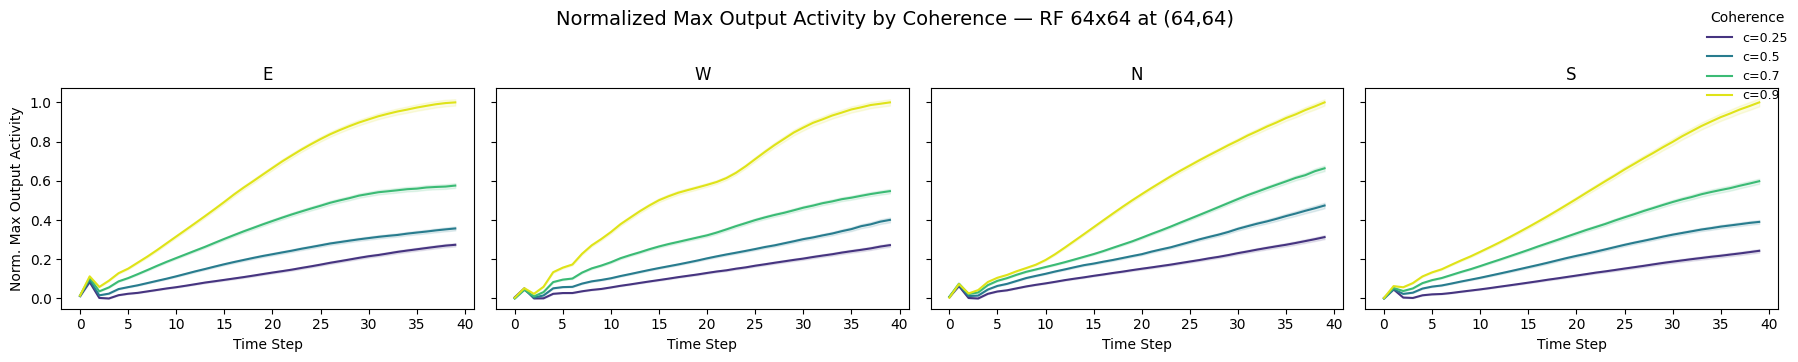

In [62]:
coherence_traces = plot_ramping_by_coherence(
    model,
    classifier,
    coherences=[0.25, 0.5, 0.7, 0.9],
    n_frames=40,
    resolution=(128, 128),
    directions=[0, 1, 2, 3],
    n_dots=100,
    max_speed=1,
    num_samples=512,
    center=(64, 64),
    rf_size=64,
    activity_type="output",
    channel_agg="max",           # or "max"
    normalize=True,
    # savepath="figures/dots_ramping_by_coherence.svg",
)

In [48]:
# Clockwise ordering from North for x-axis display
# (duplicated from constants cell for clarity; uses global DIRECTIONS_CLOCKWISE)

from scipy.special import i0 as _bessel_i0

def _von_mises(theta, mu, kappa, amplitude, baseline):
    """Von Mises (circular Gaussian) function."""
    return baseline + amplitude * np.exp(kappa * (np.cos(theta - mu) - 1))


def _fit_von_mises(bearings_rad, responses):
    """
    Fit a von Mises curve to directional tuning data.

    Returns (mu, kappa, amplitude, baseline) or None if fit fails.
    """
    from scipy.optimize import curve_fit

    # Initial guesses
    peak_idx = np.argmax(responses)
    mu0 = bearings_rad[peak_idx]
    baseline0 = responses.min()
    amplitude0 = responses.max() - baseline0
    kappa0 = 2.0

    try:
        popt, _ = curve_fit(
            _von_mises, bearings_rad, responses,
            p0=[mu0, kappa0, amplitude0, baseline0],
            bounds=([0, 0.01, 0, -np.inf],
                    [2 * np.pi, 100, np.inf, np.inf]),
            maxfev=5000,
        )
        return popt
    except RuntimeError:
        return None


def plot_direction_tuning_curves(
    model,
    classifier,
    n_frames=40,
    resolution=(128, 128),
    directions=None,
    n_dots=100,
    max_speed=1,
    correlation=0.5,
    num_samples=512,
    samples_per_epoch=1024,
    center=(64, 64),
    rf_size=8,
    activity_type="excitatory",
    time_agg="mean",
    time_range=None,
    normalize=False,
    fit_gaussian=False,
    mask_rf=False,
    savepath=None,
    device=None,
    plot_line=True,
):
    """
    Direction tuning curves: one subplot per channel, x-axis is direction
    in degrees (ordered clockwise from North), y-axis is time-aggregated
    mean activity within the RF.

    Args:
        mask_rf: If True, zero out all input pixels outside the RF before inference.
    """
    if directions is None:
        directions = list(range(24))

    # Reorder directions clockwise from North
    dir_set = set(directions)
    directions_ordered = [d for d in DIRECTIONS_CLOCKWISE if d in dir_set]

    type_str, n_channels = ACTIVITY_TYPE_LABELS[activity_type]
    dim = resolution[0]
    classifier.eval()

    dir_responses = {}
    dir_sems = {}

    for d in tqdm(directions_ordered, desc="Sweeping directions"):
        loader, _ = initialize_dataloader(
            seed=42,
            dataset="correlated_dots",
            resolution=resolution,
            n_frames=n_frames,
            correlation=correlation,
            max_speed=max_speed,
            samples_per_epoch=samples_per_epoch,
            batch_size=128,
            directions=[d],
            n_dots=n_dots,
        )
        traces = collect_rf_traces(
            model, loader, num_samples, n_frames, dim,
            center, rf_size, [d], activity_type, mask_rf, device,
        )
        arr = traces[d]  # (N_d, T, C)
        if arr.shape[0] == 0:
            dir_responses[d] = np.zeros(n_channels)
            dir_sems[d] = np.zeros(n_channels)
            continue

        # Time aggregation
        if time_range is not None:
            arr = arr[:, time_range[0]:time_range[1], :]
        if time_agg == "mean":
            per_sample = arr.mean(axis=1)  # (N_d, C)
        else:
            per_sample = arr.max(axis=1)   # (N_d, C)

        dir_responses[d] = per_sample.mean(axis=0)  # (C,)
        dir_sems[d] = per_sample.std(axis=0) / np.sqrt(per_sample.shape[0])

    # Build arrays in clockwise order: (n_dirs, C)
    resp_arr = np.stack([dir_responses[d] for d in directions_ordered])
    sem_arr = np.stack([dir_sems[d] for d in directions_ordered])

    if normalize:
        for ch in range(n_channels):
            mn, mx = resp_arr[:, ch].min(), resp_arr[:, ch].max()
            if mx - mn > 1e-12:
                resp_arr[:, ch] = (resp_arr[:, ch] - mn) / (mx - mn)
                sem_arr[:, ch] = sem_arr[:, ch] / (mx - mn)

    # Compass bearings in degrees and radians for each ordered direction
    bearings_deg = np.array([DIRECTION_BEARING[d] for d in directions_ordered])
    bearings_rad = np.deg2rad(bearings_deg)

    # Wrap data: append first point at 360° so lines and shading close the circle
    bearings_deg_wrap = np.append(bearings_deg, 360.0)
    bearings_rad_wrap = np.append(bearings_rad, bearings_rad[0] + 2 * np.pi)
    resp_wrap = np.vstack([resp_arr, resp_arr[0:1]])
    sem_wrap = np.vstack([sem_arr, sem_arr[0:1]])

    # --- Plotting ---
    n_cols = 4
    n_rows = math.ceil(n_channels / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharex=True)
    axes_flat = axes.flatten() if n_rows > 1 else (axes if n_channels > 1 else [axes])

    fit_params = {}
    for ch in range(n_channels):
        ax = axes_flat[ch]
        # Data points at actual bearings (no wrap point marker)
        ax.scatter(bearings_deg, resp_arr[:, ch], facecolors='none', edgecolors='tab:gray', marker='o', s=50, alpha=0.5, zorder=3)
        if plot_line:
            # Connecting line and SEM with wrap
            ax.plot(bearings_deg_wrap, resp_wrap[:, ch], '-', color='C0', linewidth=2)
            ax.fill_between(bearings_deg_wrap,
                            resp_wrap[:, ch] - sem_wrap[:, ch],
                            resp_wrap[:, ch] + sem_wrap[:, ch],
                            color='C0', alpha=0.15)

        if fit_gaussian:
            popt = _fit_von_mises(bearings_rad, resp_arr[:, ch])
            if popt is not None:
                fit_params[ch] = popt
                # Dense smooth curve covering full circle
                deg_fine = np.linspace(0, 360, 360)
                rad_fine = np.deg2rad(deg_fine)
                y_fit = _von_mises(rad_fine, *popt)
                ax.plot(deg_fine, y_fit, color='C3', linewidth=1.5, alpha=1,
                        label="von Mises fit")
                # Annotate preferred direction
                pref_deg = np.rad2deg(popt[0]) % 360
                ax.text(0.95, 0.95, f"pref={pref_deg:.0f}\u00b0",
                        transform=ax.transAxes, fontsize=8, va='top', ha='right',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

        ax.set_xlim(0, 360)
        ax.set_xticks(np.arange(0, 361, 45))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=12)
        ax.set_title(f"Channel {ch}", fontsize=14, fontweight='bold')
        if ch >= (n_rows - 1) * n_cols:
            ax.set_xlabel("Direction (\u00b0)", fontsize=12)
        if ch % n_cols == 0:
            ylabel = f"{'Norm. ' if normalize else ''}{time_agg.capitalize()} {type_str} Activity"
            ax.set_ylabel(ylabel, fontsize=12)

    for idx in range(n_channels, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    time_str = f" (t={time_range[0]}-{time_range[1]})" if time_range else ""
    mask_str = " (RF masked)" if mask_rf else ""
    fig.suptitle(
        f"{type_str} Direction Tuning{mask_str} \u2014 {time_agg.capitalize()}{time_str}, "
        f"c={correlation}, RF {rf_size}x{rf_size} at ({center[0]},{center[1]})",
        fontsize=16, y=1.02,
    )
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format="svg", bbox_inches="tight")
    plt.show()
    return resp_arr, sem_arr, directions_ordered, fit_params

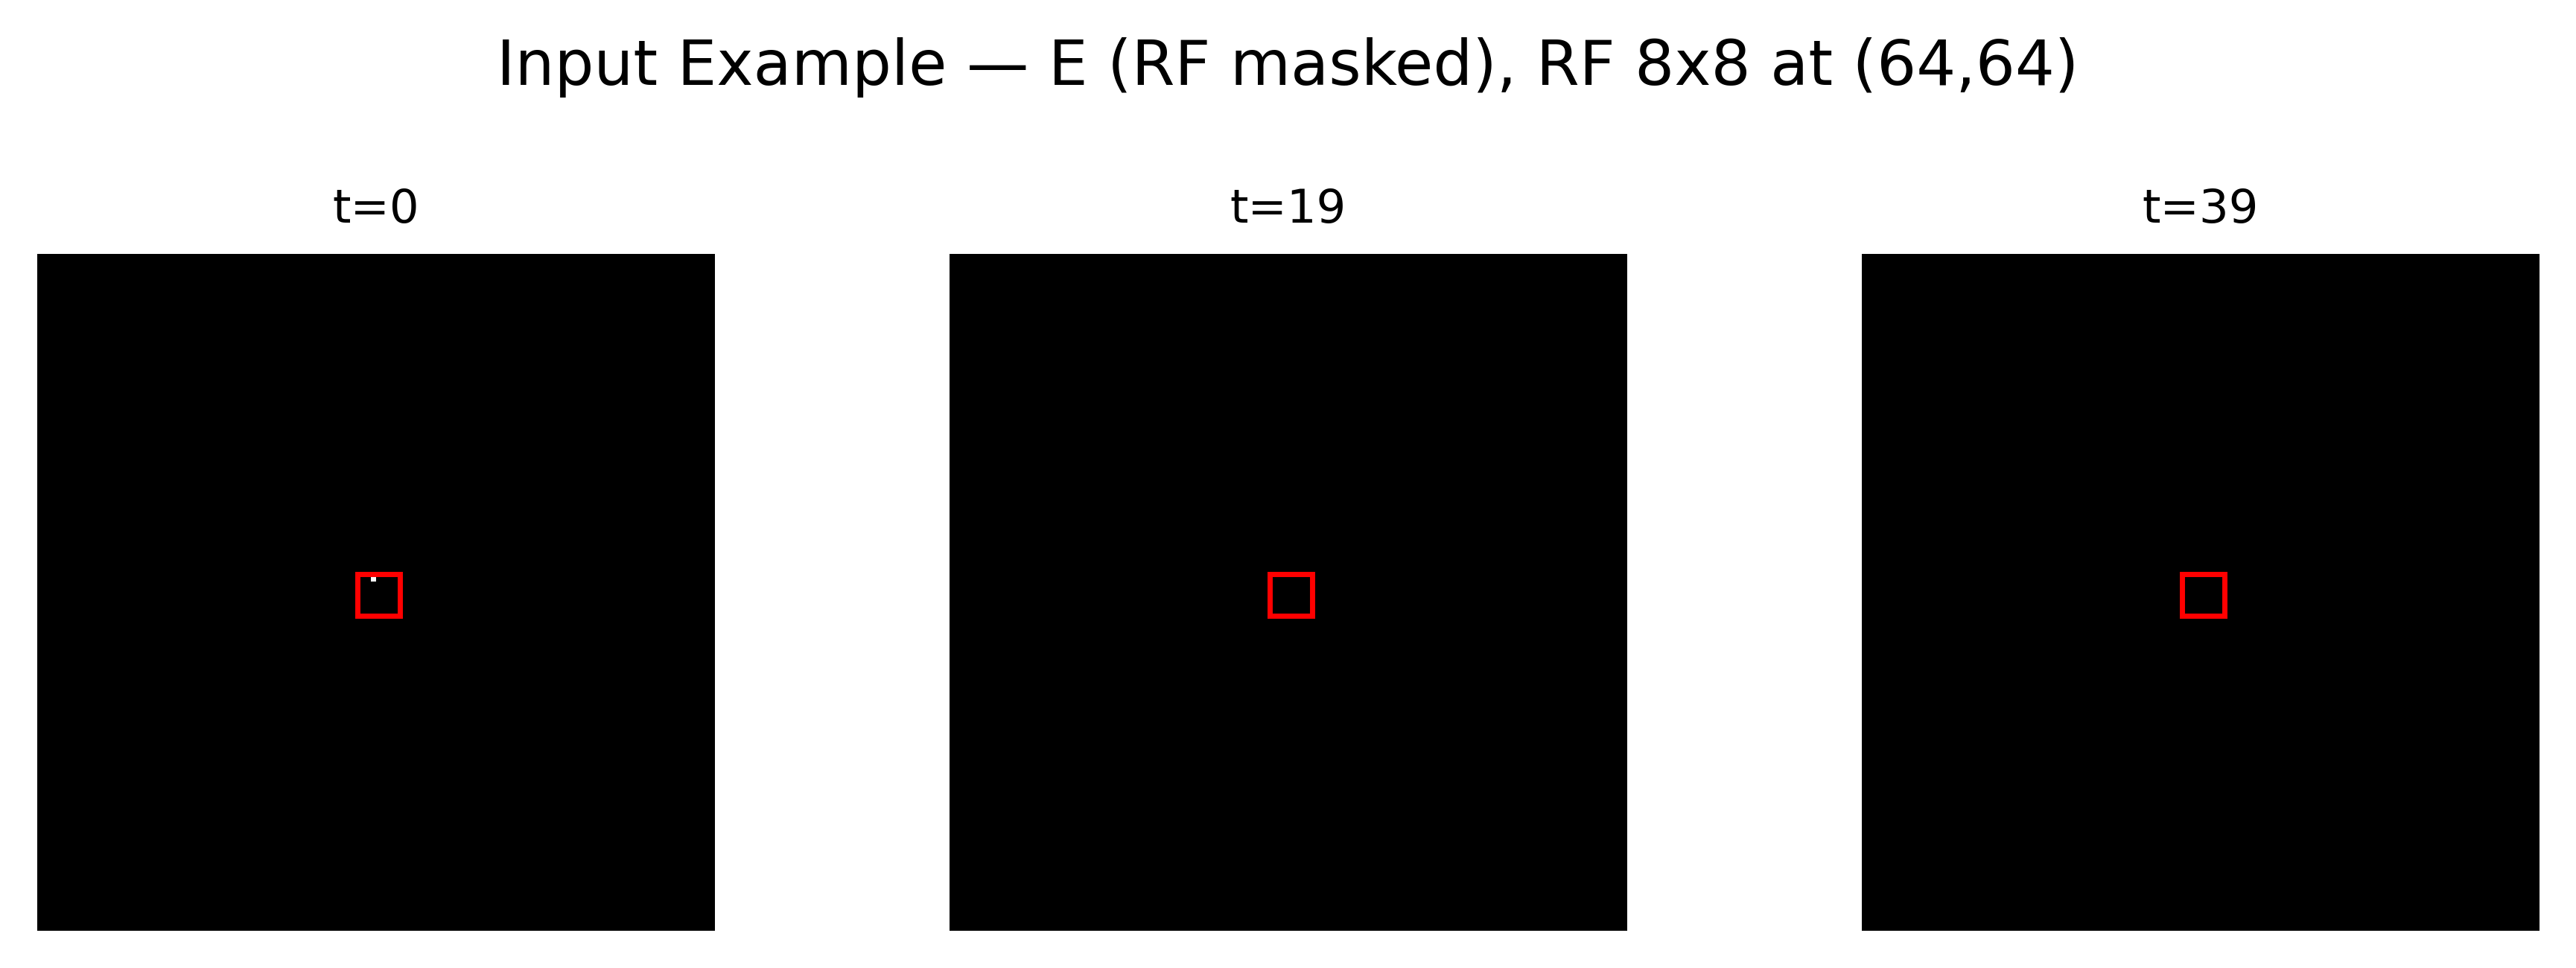

In [50]:
# --- Visualize an example input (with and without RF masking) ---
plot_input_example(
    ramping_loader,
    direction=0,        # E
    center=(64, 64),
    rf_size=8,
    dim=128,
    mask_rf=True,
    n_frames_show=3,
)

Sweeping directions:   0%|          | 0/24 [00:00<?, ?it/s]

Sweeping directions: 100%|██████████| 24/24 [04:04<00:00, 10.18s/it]


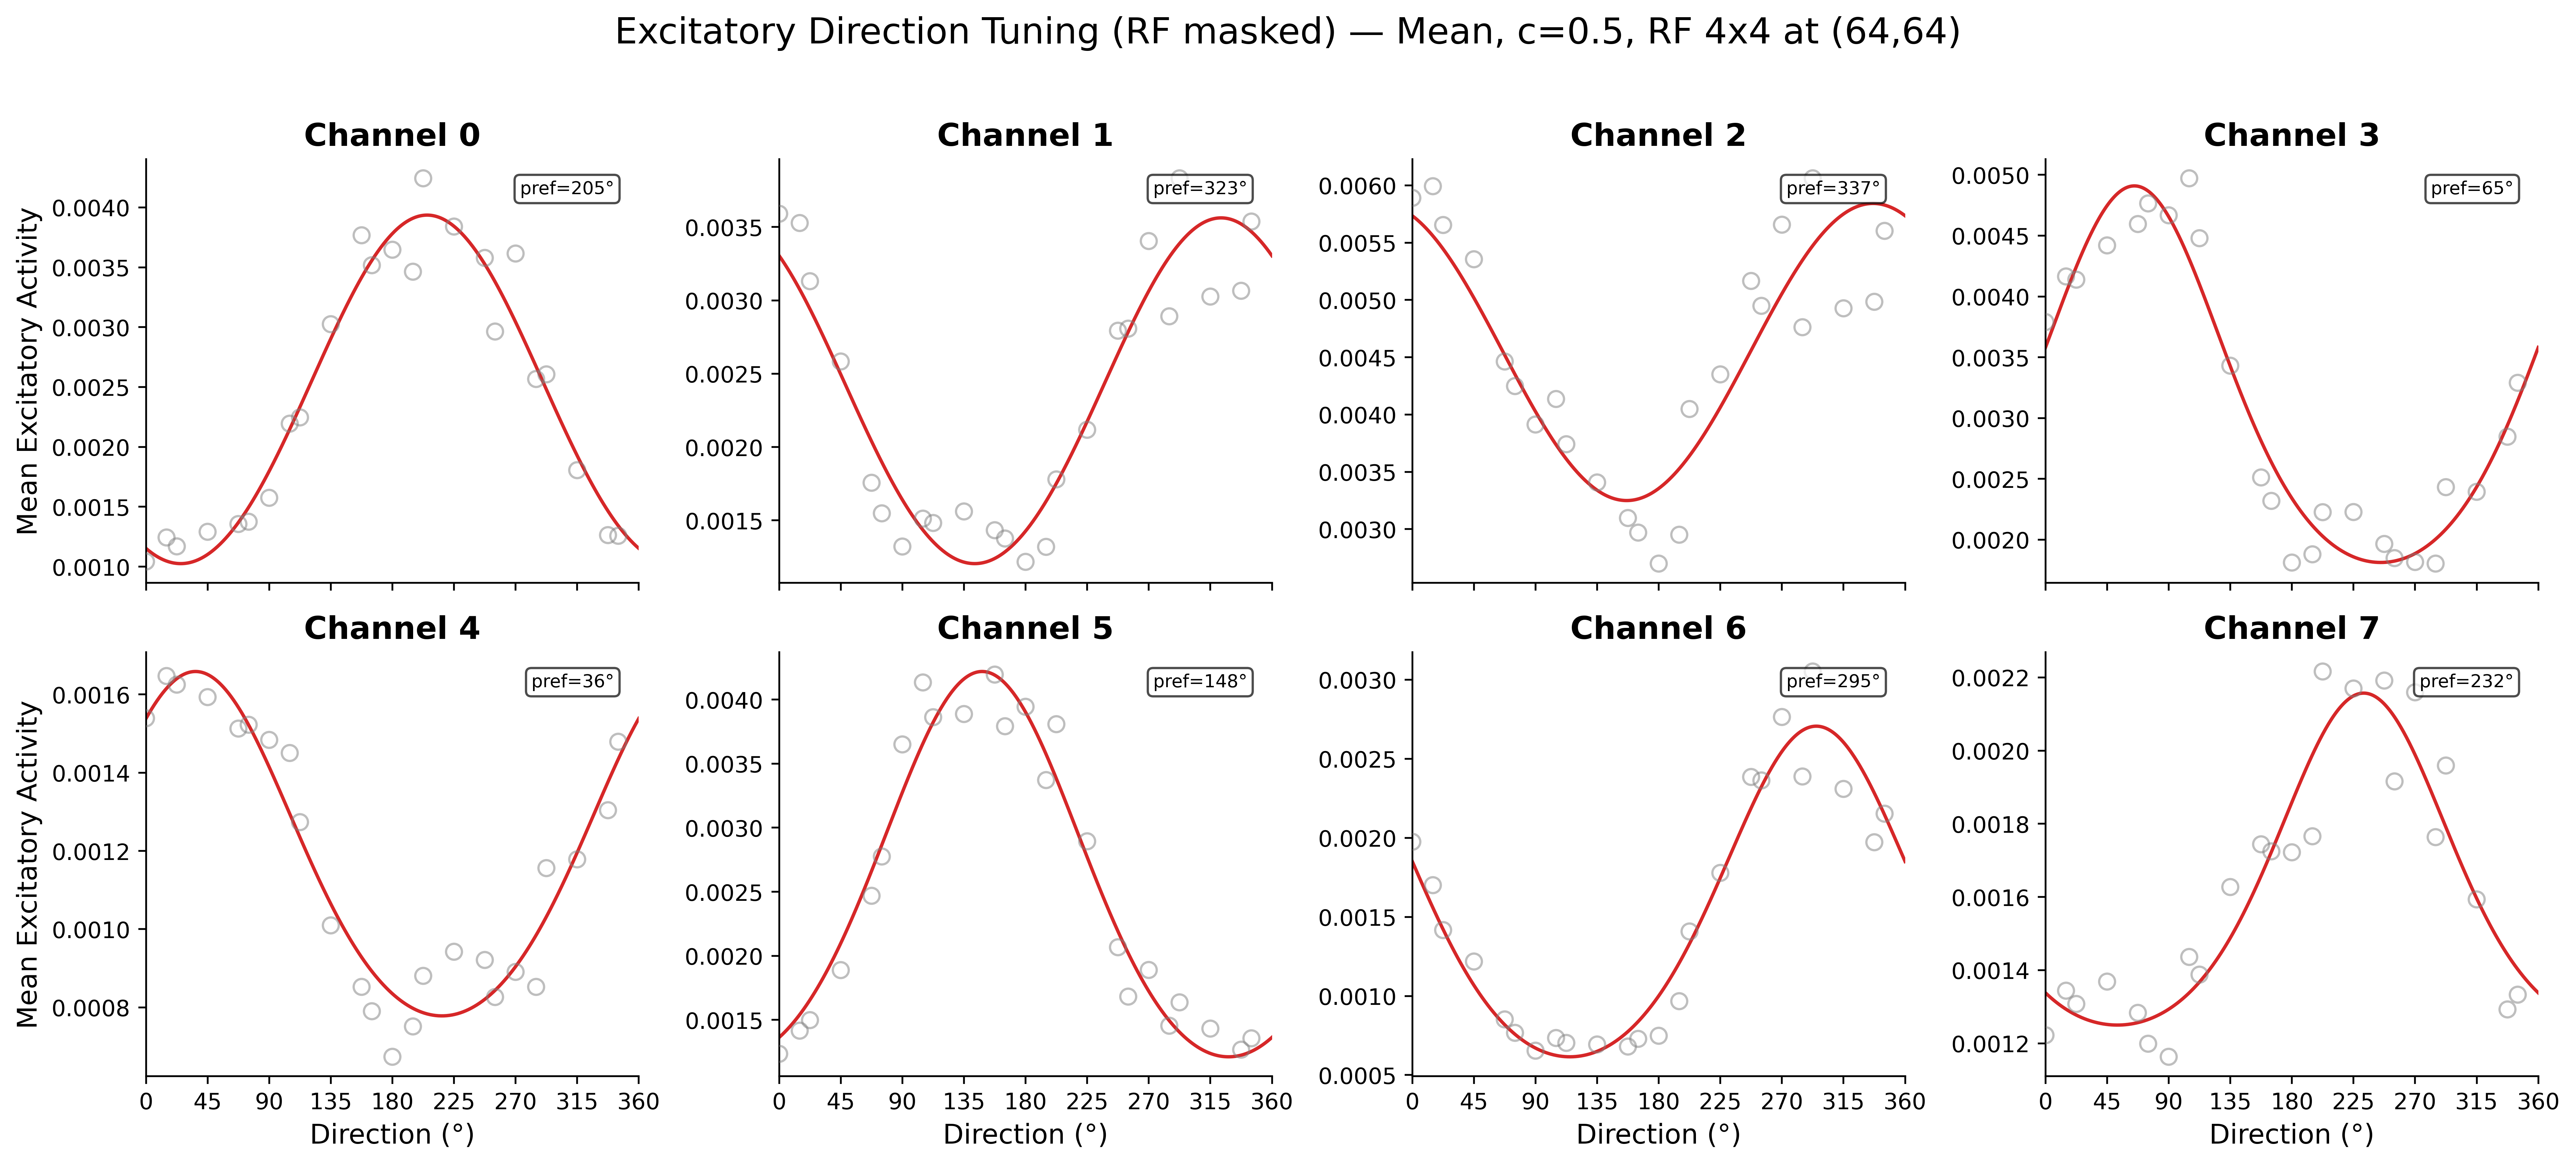

In [45]:
tuning_resp, tuning_sem, tuning_dirs, tuning_fits = plot_direction_tuning_curves(
    model,
    classifier,
    n_frames=40,
    resolution=(128, 128),
    directions=list(range(24)),   # all 24 directions
    n_dots=100,
    max_speed=1,
    correlation=0.5,
    num_samples=512,
    center=(64, 64),
    rf_size=4,
    activity_type="excitatory",
    time_agg="mean",              # or "max"
    time_range=None,              # e.g. (20, 40) for late activity only
    normalize=False,
    fit_gaussian=True,
    mask_rf=True,
    plot_line=False,
    # savepath="figures/dots_direction_tuning.svg",
)